# First Implementation 


There is the pipeline
**camera.py**: builds the intrinsics for each pyramid level
**frameData.py**: stores image, derivatives, inverse depth, and pose
**pose_estimator_gauss_newton.py**: optimizes the pose
**common.py**: bilinear interpolation
**dataset/desktop_dataset/images**: input images
**Depth-Anything**: computes depth maps on the fly from the images


In this notebook, the simplest setup is now:

- you directly provide the path to the reference image
- you directly provide the path to the current image

You no longer need to use indices such as `scene_000`, `scene_001`, and so on.


In [35]:
from pathlib import Path
import copy
import hashlib
import os
import sys

import cv2
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn.functional as F
from torchvision.transforms import Compose

ROOT = Path.cwd()
if not (ROOT / "scripts" / "python_visual_odometry").exists() and (ROOT.parent / "scripts" / "python_visual_odometry").exists():
    ROOT = ROOT.parent

PROJECT_ROOT = ROOT
SCRIPT_DIR = PROJECT_ROOT / "scripts" / "python_visual_odometry"
if str(SCRIPT_DIR) not in sys.path:
    sys.path.insert(0, str(SCRIPT_DIR))

import importlib.util
try:
    import camera
except ModuleNotFoundError:
    camera_path = SCRIPT_DIR / "camera.py"
    if camera_path.exists():
        spec = importlib.util.spec_from_file_location("camera", str(camera_path))
        camera = importlib.util.module_from_spec(spec)
        spec.loader.exec_module(camera)
        sys.modules["camera"] = camera
    else:
        raise
import common
import frameData
import pose_estimator_gauss_newton


In [36]:
plt.rcParams["figure.figsize"] = (8, 5)
np.set_printoptions(precision=6, suppress=True)

ROOT = Path.cwd()
if not (ROOT / "scripts" / "python_visual_odometry").exists() and (ROOT.parent / "scripts" / "python_visual_odometry").exists():
    ROOT = ROOT.parent
PROJECT_ROOT = ROOT
SCRIPT_DIR = PROJECT_ROOT / "scripts" / "python_visual_odometry"
DEPTH_ANYTHING_DIR = PROJECT_ROOT / "Depth-Anything"

if not DEPTH_ANYTHING_DIR.exists():
    raise FileNotFoundError(f"Depth-Anything not found: {DEPTH_ANYTHING_DIR}")

if str(DEPTH_ANYTHING_DIR) not in sys.path:
    sys.path.insert(0, str(DEPTH_ANYTHING_DIR))

from depth_anything.dpt import DepthAnything
from depth_anything.util.transform import NormalizeImage, PrepareForNet, Resize



In [37]:


DEPTH_ENCODER = "vitb"
DEPTH_MODEL_NAME = f"LiheYoung/depth_anything_{DEPTH_ENCODER}14"
DEPTH_CACHE_DIR = SCRIPT_DIR / "depth_anything_cache" / DEPTH_ENCODER
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

DEPTH_CACHE_DIR.mkdir(parents=True, exist_ok=True)


--------------

### Convert to frame, create a list of these frames

In [38]:
import convert_video_frame
convert_video_frame.video_to_frames_and_save(r"C:\Users\conqu\Videos\Detection_Deep_Fake\Répo_1st_test\Implémentaiton_1\dataset\real\TUM_real.mp4", r"C:\Users\conqu\Videos\Detection_Deep_Fake\Répo_1st_test\Implémentaiton_1\dataset\real\TUM_real_frames")


FPS : 30.0
Nombre total de trames : 798
798 frames sauvegardees dans : C:\Users\conqu\Videos\Detection_Deep_Fake\Répo_1st_test\Implémentaiton_1\dataset\real\TUM_real_frames


In [39]:
dossier_real = Path(r"C:\Users\conqu\Videos\Detection_Deep_Fake\Répo_1st_test\Implémentaiton_1\dataset\real\TUM_real_frames")

In [40]:

real_frame_paths = sorted(
    str(f.resolve())
    for f in dossier_real.rglob("*")
    if f.is_file()
)

print(f"{len(real_frame_paths)} fichiers trouvés dans {dossier_real}")


print()


798 fichiers trouvés dans C:\Users\conqu\Videos\Detection_Deep_Fake\Répo_1st_test\Implémentaiton_1\dataset\real\TUM_real_frames



In [41]:

KEYFRAME_PATH = real_frame_paths[0]
TARGET_PATH= [real_frame_paths[1]]

print(KEYFRAME_PATH)
print(TARGET_PATH)

C:\Users\conqu\Videos\Detection_Deep_Fake\Répo_1st_test\Implémentaiton_1\dataset\real\TUM_real_frames\frame_00000.png
['C:\\Users\\conqu\\Videos\\Detection_Deep_Fake\\Répo_1st_test\\Implémentaiton_1\\dataset\\real\\TUM_real_frames\\frame_00001.png']


## 2. Notebook utility functions

Here we rewrite a few small helper functions to make the pipeline explicit:

- load a grayscale image from its path
- compute a depth map with Depth Anything
- convert depth -> inverse depth
- quickly display a 4x4 matrix

The depth is inferred directly from the corresponding image with the `vitb` encoder, and can optionally be cached in `depth_anything_cache/vitb` to avoid recomputing it every time.

The important conversion is:

$$
\rho = \frac{1}{d}
$$

where **d** is the depth and **rho** is the inverse depth expected by the solver.


In [42]:


#PERMET DE NORMALISER LE CHEMIN DE L'IMAGE, EN S'ASSURANT QU'IL EST ABSOLU ET QU'IL EXISTE
def normalize_image_path(path_like) -> Path:
    path = Path(path_like)
    if not path.is_absolute():
        path = (ROOT / path).resolve()
    if not path.exists():
        raise FileNotFoundError(f"Image not found: {path}")
    return path



#PERMET DE CONSTRUIRE LE CHEMIN DE CACHE POUR LA CARTE DE PROFONDEUR CORRESPONDANTE À UNE IMAGE, EN UTILISANT UN HASH DU CHEMIN DE L'IMAGE POUR ÉVITER LES CONFLITS
def build_depth_cache_path(image_path: Path) -> Path:
    safe_name = image_path.stem.replace(" ", "_")
    cache_key = hashlib.md5(str(image_path.resolve()).encode("utf-8")).hexdigest()[:8]
    cache_name = f"{safe_name}_{cache_key}_depth.npy"
    return DEPTH_CACHE_DIR / cache_name


#PERMET DE CHARGER UNE IMAGE EN NIVEAUX DE GRIS À PARTIR D'UN CHEMIN, EN UTILISANT OPENCV POUR LIRE LE FICHIER ET LE CONVERTIR EN UN TABLEAU NUMPY
def load_gray_image(image_path) -> np.ndarray:
    path = normalize_image_path(image_path)
    buffer = np.fromfile(path, dtype=np.uint8)
    image = cv2.imdecode(buffer, cv2.IMREAD_GRAYSCALE)
    if image is None:
        raise FileNotFoundError(f"Image not found: {path}")
    return image


def load_rgb_image(image_path) -> np.ndarray:
    path = normalize_image_path(image_path)
    buffer = np.fromfile(path, dtype=np.uint8)
    image_bgr = cv2.imdecode(buffer, cv2.IMREAD_COLOR)
    if image_bgr is None:
        raise FileNotFoundError(f"Image not found: {path}")
    return cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)


def get_depth_anything_components():
    if not hasattr(get_depth_anything_components, "model"):
        previous_cwd = Path.cwd()
        try:
            os.chdir(DEPTH_ANYTHING_DIR)
            model = DepthAnything.from_pretrained(DEPTH_MODEL_NAME).to(DEVICE).eval()
        finally:
            os.chdir(previous_cwd)

        transform = Compose([
            Resize(
                width=518,
                height=518,
                resize_target=False,
                keep_aspect_ratio=True,
                ensure_multiple_of=14,
                resize_method="lower_bound",
                image_interpolation_method=cv2.INTER_CUBIC,
            ),
            NormalizeImage(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
            PrepareForNet(),
        ])
        get_depth_anything_components.model = model
        get_depth_anything_components.transform = transform

        total_params = sum(param.numel() for param in model.parameters())
        print(f"Depth Anything loaded on {DEVICE} ({total_params / 1e6:.2f}M parameters)")

    return get_depth_anything_components.model, get_depth_anything_components.transform


def load_depth_map(image_path, use_cache: bool = True, save_cache: bool = True) -> np.ndarray:
    path = normalize_image_path(image_path)
    cache_path = build_depth_cache_path(path)
    if use_cache and cache_path.exists():
        return np.load(cache_path).astype(np.float32)

    image = load_rgb_image(path).astype(np.float32) / 255.0
    h, w = image.shape[:2]

    model, transform = get_depth_anything_components()
    image = transform({"image": image})["image"]
    image = torch.from_numpy(image).unsqueeze(0).to(DEVICE)

    with torch.no_grad():
        depth = model(image)

    depth = F.interpolate(depth[None], (h, w), mode="bilinear", align_corners=False)[0, 0]
    depth = depth.cpu().numpy().astype(np.float32)

    if save_cache:
        np.save(cache_path, depth)

    return depth


def depth_to_invdepth(depth: np.ndarray):
    inv_depth = np.zeros_like(depth, dtype=np.float32)
    valid_mask = depth > 1e-6
    inv_depth[valid_mask] = 1.0 / depth[valid_mask]
    inv_depth_var = np.ones_like(depth, dtype=np.float32)
    inv_depth_var[~valid_mask] = 1e6
    return inv_depth, inv_depth_var, valid_mask


def show_pose_matrix(title: str, pose):
    matrix = pose.as_matrix()
    print(title)
    print(matrix)
    return matrix


(480, 640)


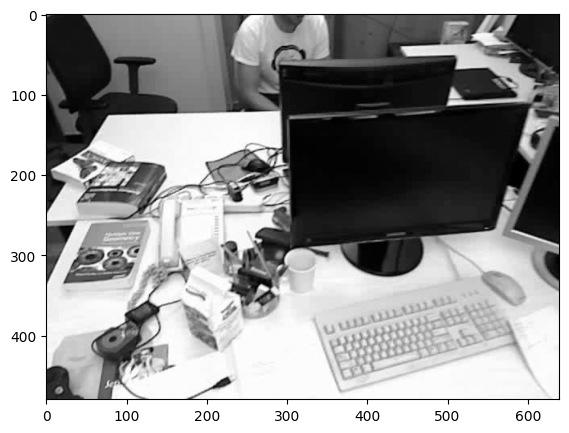

In [43]:
frame_0 = load_gray_image(KEYFRAME_PATH)
print(frame_0.shape)
plt.imshow(frame_0, cmap='gray')

## keyframe

Here we load:

- the reference image specified in `KEYFRAME_PATH`
- the depth map inferred by **Depth Anything** for this image

This image provides the base 3D geometry.


In [44]:
keyframe_image_path = normalize_image_path(KEYFRAME_PATH)
keyframe_image = load_gray_image(keyframe_image_path)
keyframe_depth = load_depth_map(keyframe_image_path)
keyframe_inv_depth, keyframe_inv_depth_var, valid_mask = depth_to_invdepth(keyframe_depth)


In [45]:

print("keyframe_image_path =", keyframe_image_path)
print("keyframe_image shape =", keyframe_image.shape, "dtype =", keyframe_image.dtype)
print("keyframe_depth shape =", keyframe_depth.shape, "dtype =", keyframe_depth.dtype)
print("depth min/max =", float(keyframe_depth.min()), float(keyframe_depth.max()))
print("valid depth ratio =", float(valid_mask.mean()))


keyframe_image_path = C:\Users\conqu\Videos\Detection_Deep_Fake\Répo_1st_test\Implémentaiton_1\dataset\real\TUM_real_frames\frame_00000.png
keyframe_image shape = (480, 640) dtype = uint8
keyframe_depth shape = (480, 640) dtype = float32
depth min/max = 0.18881633877754211 63.87637710571289
valid depth ratio = 1.0


Text(0.5, 1.0, 'Inverse depth')

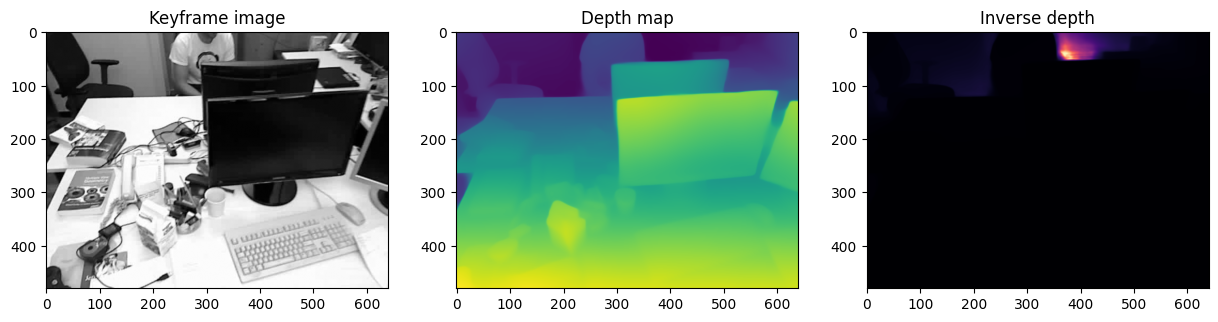

In [46]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))




axes[0].imshow(keyframe_image, cmap="gray")
axes[0].set_title("Keyframe image")

axes[1].imshow(keyframe_depth, cmap="viridis")
axes[1].set_title("Depth map")


axes[2].imshow(keyframe_inv_depth, cmap="magma")
axes[2].set_title("Inverse depth")




## 4. Intrinsics

Dans ce notebook, les intrinseques doivent etre definies **une seule fois** dans la cellule suivante.

Idee simple :
- tu choisis `USER_FX`, `USER_FY`, `USER_CX`, `USER_CY`
- ces valeurs sont la **source de verite**
- elles sont passees a `camera.camera(...)`
- ensuite on affiche clairement ce que le pipeline utilise vraiment

Important :
- `frameData.py` et `camera.py` redimensionnent tout vers la resolution interne definie dans `params.py`
- donc on affiche a la fois :
  - `K_user` = la matrice que tu choisis
  - `K_used_lvl0` = la matrice effectivement utilisee au niveau 0 de la pyramide

Comme ca, il n'y a plus d'ambiguite sur les intrinseques utilisees dans la suite du notebook.


In [47]:
# ==================================================
# Intrinseques a definir UNE FOIS au debut
# ==================================================
loaded_height, loaded_width = keyframe_image.shape[:2]

# Mets ici les intrinseques que tu veux utiliser.
# Ce bloc est la source de verite pour tout le notebook.
USER_WIDTH = loaded_width
USER_HEIGHT = loaded_height


#Pour Emanuel
#USER_FX = 481.20
#USER_FY = 480.0
#USER_CX = 319.5
#USER_CY = 239.5


#Pour tum RGB
USER_FX = 525.0  
USER_FY = 525.0  
USER_CX = 319.5  
USER_CY = 239.5  





intrinsics_user = {
    "width": USER_WIDTH,
    "height": USER_HEIGHT,
    "fx": USER_FX,
    "fy": USER_FY,
    "cx": USER_CX,
    "cy": USER_CY,
}

K_user = np.array([
    [USER_FX, 0.0, USER_CX],
    [0.0, USER_FY, USER_CY],
    [0.0, 0.0, 1.0],
], dtype=np.float64)

cam = camera.camera(
    USER_FX,
    USER_FY,
    USER_CX,
    USER_CY,
    USER_WIDTH,
    USER_HEIGHT,
)

intrinsics_used_lvl0 = {
    "width": cam.width[0],
    "height": cam.height[0],
    "fx": cam.fx[0],
    "fy": cam.fy[0],
    "cx": cam.cx[0],
    "cy": cam.cy[0],
}

K_used_lvl0 = np.array([
    [cam.fx[0], 0.0, cam.cx[0]],
    [0.0, cam.fy[0], cam.cy[0]],
    [0.0, 0.0, 1.0],
], dtype=np.float64)

print("Loaded keyframe size:")
print("  width  =", loaded_width)
print("  height =", loaded_height)
print()
print("USER intrinsics chosen at the beginning of the notebook:")
print(intrinsics_user)
print()
print("K_user =")
print(K_user)
print()
print("Internal working resolution used by the pipeline (level 0):")
print("  width  =", intrinsics_used_lvl0["width"])
print("  height =", intrinsics_used_lvl0["height"])
print()
print("K_used_lvl0 =")
print(K_used_lvl0)


Loaded keyframe size:
  width  = 640
  height = 480

USER intrinsics chosen at the beginning of the notebook:
{'width': 640, 'height': 480, 'fx': 525.0, 'fy': 525.0, 'cx': 319.5, 'cy': 239.5}

K_user =
[[525.    0.  319.5]
 [  0.  525.  239.5]
 [  0.    0.    1. ]]

Internal working resolution used by the pipeline (level 0):
  width  = 640
  height = 480

K_used_lvl0 =
[[525.    0.  319.5]
 [  0.  525.  239.5]
 [  0.    0.    1. ]]


In [48]:
scale_x = cam.width[0] / USER_WIDTH
scale_y = cam.height[0] / USER_HEIGHT

print("Check that the pipeline camera really comes from the USER intrinsics above:")
print("  scale_x =", scale_x)
print("  scale_y =", scale_y)
print()
print("  USER_FX -> cam.fx[0] :", USER_FX, "->", cam.fx[0])
print("  USER_FY -> cam.fy[0] :", USER_FY, "->", cam.fy[0])
print("  USER_CX -> cam.cx[0] :", USER_CX, "->", cam.cx[0])
print("  USER_CY -> cam.cy[0] :", USER_CY, "->", cam.cy[0])
print()
print("Expected level-0 values after internal resize:")
print("  expected fx =", USER_FX * scale_x)
print("  expected fy =", USER_FY * scale_y)
print("  expected cx =", USER_CX * scale_x)
print("  expected cy =", USER_CY * scale_y)

assert np.isclose(cam.fx[0], USER_FX * scale_x)
assert np.isclose(cam.fy[0], USER_FY * scale_y)
assert np.isclose(cam.cx[0], USER_CX * scale_x)
assert np.isclose(cam.cy[0], USER_CY * scale_y)

print()
print("Assertion passed: the notebook is using the intrinsics defined above.")


Check that the pipeline camera really comes from the USER intrinsics above:
  scale_x = 1.0
  scale_y = 1.0

  USER_FX -> cam.fx[0] : 525.0 -> 525.0
  USER_FY -> cam.fy[0] : 525.0 -> 525.0
  USER_CX -> cam.cx[0] : 319.5 -> 319.5
  USER_CY -> cam.cy[0] : 239.5 -> 239.5

Expected level-0 values after internal resize:
  expected fx = 525.0
  expected fy = 525.0
  expected cx = 319.5
  expected cy = 239.5

Assertion passed: the notebook is using the intrinsics defined above.


### Verification for every pyramid level

On affiche maintenant les intrinseques utilisees a **chaque niveau** de la pyramide, et on verifie qu elles correspondent bien a la regle automatique du code : division par `2**lvl` a partir du niveau 0.

In [49]:
intrinsics_per_level = []
base_fx = cam.fx[0]
base_fy = cam.fy[0]
base_cx = cam.cx[0]
base_cy = cam.cy[0]
base_width = cam.width[0]
base_height = cam.height[0]

print("Intrinsics used for each pyramid level:")
print()

for lvl in range(len(cam.fx)):
    scale = 2 ** lvl
    expected_fx = base_fx / scale
    expected_fy = base_fy / scale
    expected_cx = base_cx / scale
    expected_cy = base_cy / scale
    expected_width = int(base_width / scale)
    expected_height = int(base_height / scale)

    K_lvl = np.array([
        [cam.fx[lvl], 0.0, cam.cx[lvl]],
        [0.0, cam.fy[lvl], cam.cy[lvl]],
        [0.0, 0.0, 1.0],
    ], dtype=np.float64)

    assert np.isclose(cam.fx[lvl], expected_fx)
    assert np.isclose(cam.fy[lvl], expected_fy)
    assert np.isclose(cam.cx[lvl], expected_cx)
    assert np.isclose(cam.cy[lvl], expected_cy)
    assert cam.width[lvl] == expected_width
    assert cam.height[lvl] == expected_height

    intrinsics_per_level.append({
        "level": lvl,
        "scale": scale,
        "width": cam.width[lvl],
        "height": cam.height[lvl],
        "fx": cam.fx[lvl],
        "fy": cam.fy[lvl],
        "cx": cam.cx[lvl],
        "cy": cam.cy[lvl],
        "K": K_lvl,
    })

    print(f"LEVEL {lvl}")
    print(f"  scale  = 1 / {scale}")
    print(f"  size   = {cam.width[lvl]} x {cam.height[lvl]}")
    print(f"  fx, fy = {cam.fx[lvl]:.6f}, {cam.fy[lvl]:.6f}")
    print(f"  cx, cy = {cam.cx[lvl]:.6f}, {cam.cy[lvl]:.6f}")
    print("  K =")
    print(K_lvl)
    print()

print("All assertions passed: each level uses the expected intrinsics.")


Intrinsics used for each pyramid level:

LEVEL 0
  scale  = 1 / 1
  size   = 640 x 480
  fx, fy = 525.000000, 525.000000
  cx, cy = 319.500000, 239.500000
  K =
[[525.    0.  319.5]
 [  0.  525.  239.5]
 [  0.    0.    1. ]]

LEVEL 1
  scale  = 1 / 2
  size   = 320 x 240
  fx, fy = 262.500000, 262.500000
  cx, cy = 159.750000, 119.750000
  K =
[[262.5    0.   159.75]
 [  0.   262.5  119.75]
 [  0.     0.     1.  ]]

LEVEL 2
  scale  = 1 / 4
  size   = 160 x 120
  fx, fy = 131.250000, 131.250000
  cx, cy = 79.875000, 59.875000
  K =
[[131.25    0.     79.875]
 [  0.    131.25   59.875]
 [  0.      0.      1.   ]]

LEVEL 3
  scale  = 1 / 8
  size   = 80 x 60
  fx, fy = 65.625000, 65.625000
  cx, cy = 39.937500, 29.937500
  K =
[[65.625   0.     39.9375]
 [ 0.     65.625  29.9375]
 [ 0.      0.      1.    ]]

LEVEL 4
  scale  = 1 / 16
  size   = 40 x 30
  fx, fy = 32.812500, 32.812500
  cx, cy = 19.968750, 14.968750
  K =
[[32.8125   0.      19.96875]
 [ 0.      32.8125  14.96875]
 [ 0.  

In [50]:

keyframe = frameData.frameData()
keyframe.setImage(keyframe_image)
keyframe.setInvDepth(keyframe_inv_depth, keyframe_inv_depth_var)

print("Pyramid levels =", len(keyframe.image))
for lvl in range(len(keyframe.image)):
    print(
        f"level {lvl}: image={keyframe.image[lvl].shape}, "
        f"invDepth={keyframe.invDepth[lvl].shape}, "
        f"grad={keyframe.imageDerivative[lvl].shape}"
    )


Pyramid levels = 5
level 0: image=(480, 640), invDepth=(480, 640), grad=(480, 640, 2)
level 1: image=(240, 320), invDepth=(240, 320), grad=(240, 320, 2)
level 2: image=(120, 160), invDepth=(120, 160), grad=(120, 160, 2)
level 3: image=(60, 80), invDepth=(60, 80), grad=(60, 80, 2)
level 4: image=(30, 40), invDepth=(30, 40), grad=(30, 40, 2)


## 5. Loading the current image

Now we take a second image, specified in `TARGET_PATH`.

This is the image whose relative pose with respect to the keyframe we want to estimate.
At first, its pose is the identity, and then the solver updates it.


In [51]:
# TARGET_PATH can be a list (from earlier cells) or a single path string.
if isinstance(TARGET_PATH, (list, tuple)):
	if len(TARGET_PATH) == 0:
		raise ValueError("TARGET_PATH is empty")
	selected_target = TARGET_PATH[0]
else:
	selected_target = TARGET_PATH

current_image_path = normalize_image_path(selected_target)
current_image = load_gray_image(current_image_path)

current_frame = frameData.frameData()
current_frame.setImage(current_image)



### Recap

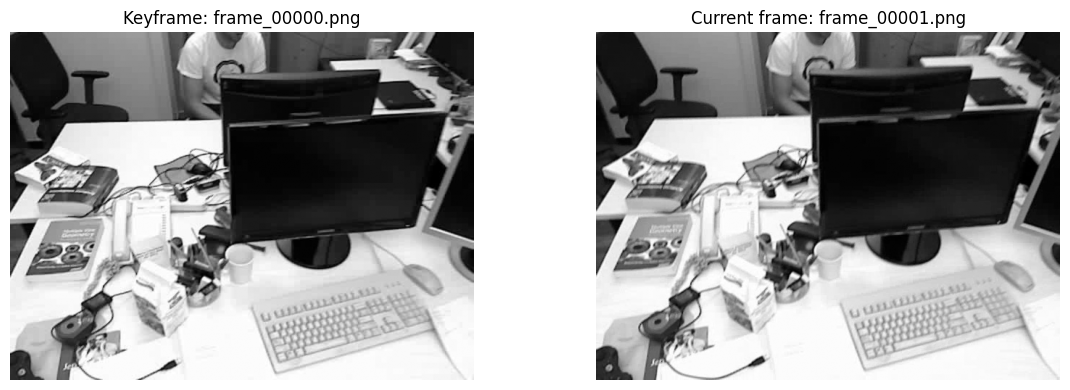

In [52]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].imshow(keyframe_image, cmap="gray")
axes[0].set_title(f"Keyframe: {keyframe_image_path.name}")


axes[1].imshow(current_image, cmap="gray")
axes[1].set_title(f"Current frame: {current_image_path.name}")


for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.show()


## Initial pose and optimization updates

Dans la cellule suivante, `pose_solver` est cree avec `cam`.
Donc les intrinseques utilisees pour l'estimation de pose sont bien celles affichees juste au-dessus.


In [53]:
pose_solver = pose_estimator_gauss_newton.pose_estimator_gauss_newton(cam, show_debug=False)

print("Proof before optimization:")
print("  pose_solver.camera is cam ->", pose_solver.camera is cam)
print("  pose_solver.camera.fx[0] =", pose_solver.camera.fx[0])
print("  pose_solver.camera.fy[0] =", pose_solver.camera.fy[0])
print("  pose_solver.camera.cx[0] =", pose_solver.camera.cx[0])
print("  pose_solver.camera.cy[0] =", pose_solver.camera.cy[0])
print()
print("Reference level-0 intrinsics that should match:")
print(intrinsics_used_lvl0)
print()

initial_error_lvl4, _ = pose_solver.computeError(current_frame, keyframe, lvl=4)
initial_error_lvl3, _ = pose_solver.computeError(current_frame, keyframe, lvl=3)
initial_error_lvl2, _ = pose_solver.computeError(current_frame, keyframe, lvl=2)

print("Initial photometric errors before optimization:")
print("  level 4 =", initial_error_lvl4)
print("  level 3 =", initial_error_lvl3)
print("  level 2 =", initial_error_lvl2)


Proof before optimization:
  pose_solver.camera is cam -> True
  pose_solver.camera.fx[0] = 525.0
  pose_solver.camera.fy[0] = 525.0
  pose_solver.camera.cx[0] = 319.5
  pose_solver.camera.cy[0] = 239.5

Reference level-0 intrinsics that should match:
{'width': 640, 'height': 480, 'fx': 525.0, 'fy': 525.0, 'cx': 319.5, 'cy': 239.5}

Initial photometric errors before optimization:
  level 4 = 2062.0811843361967
  level 3 = 1757.909090909089
  level 2 = 1797.5543938662795


**optPose(...)** performs several updates:

- it computes an error
- it locally linearizes the problem
- it computes a pose increment
- it accepts or rejects this update depending on the error improvement

At the end, **current_frame.pose** contains the estimated extrinsic matrix of the current frame relative to the keyframe.


In [54]:
pose_solver.optPose(current_frame, keyframe)

final_error_lvl4, _ = pose_solver.computeError(current_frame, keyframe, lvl=4)
final_error_lvl3, _ = pose_solver.computeError(current_frame, keyframe, lvl=3)
final_error_lvl2, _ = pose_solver.computeError(current_frame, keyframe, lvl=2)

print("Final photometric errors after optimization:")
print("  level 4 =", final_error_lvl4)
print("  level 3 =", final_error_lvl3)
print("  level 2 =", final_error_lvl2)


lvl:  4  initial error:  2062.0811843361967
update too small, level converged! it:  4  error:  1242.5559693778052  lambda:  450359962737049.6
lvl:  3  initial error:  858.1635862688839
 error improvement too small, level converged! it:  5  error:  670.0585124604014  lambda:  0.2
lvl:  2  initial error:  294.66691260675555
 error improvement too small, level converged! it:  3  error:  288.7769118997986  lambda:  7036874417766.4
Final photometric errors after optimization:
  level 4 = 1280.7613682180752
  level 3 = 670.0899717524165
  level 2 = 288.7769118997986


### Sanity check on pose estimation

Ici on verifie que le resultat a du sens :
- les erreurs photometriques doivent baisser apres optimisation
- la pose finale doit contenir des valeurs finies
- on veut aussi garder une trace interpretable du gain obtenu a chaque niveau.

In [55]:
optimization_summary = {
    "lvl4_initial": float(initial_error_lvl4),
    "lvl4_final": float(final_error_lvl4),
    "lvl3_initial": float(initial_error_lvl3),
    "lvl3_final": float(final_error_lvl3),
    "lvl2_initial": float(initial_error_lvl2),
    "lvl2_final": float(final_error_lvl2),
}

error_improvement = {
    "lvl4": float(initial_error_lvl4 - final_error_lvl4),
    "lvl3": float(initial_error_lvl3 - final_error_lvl3),
    "lvl2": float(initial_error_lvl2 - final_error_lvl2),
}

print("Optimization summary:")
for lvl in [4, 3, 2]:
    initial_value = optimization_summary[f"lvl{lvl}_initial"]
    final_value = optimization_summary[f"lvl{lvl}_final"]
    improvement = error_improvement[f"lvl{lvl}"]
    print(f"  level {lvl}: initial={initial_value:.6f}, final={final_value:.6f}, improvement={improvement:.6f}")

pose_matrix_now = current_frame.pose.as_matrix()
pose_is_finite = bool(np.isfinite(pose_matrix_now).all())
errors_improved = {lvl: (error_improvement[f"lvl{lvl}"] > 0.0) for lvl in [4, 3, 2]}

print()
print("Pose matrix finite ->", pose_is_finite)
print("Errors improved by level ->", errors_improved)

assert pose_is_finite, "Pose matrix contains non-finite values."
assert all(errors_improved.values()), "At least one pyramid level did not improve after optimization."

print()
print("Sanity check passed: intrinsics are coherent and pose optimization improves the photometric error at all checked levels.")


Optimization summary:
  level 4: initial=2062.081184, final=1280.761368, improvement=781.319816
  level 3: initial=1757.909091, final=670.089972, improvement=1087.819119
  level 2: initial=1797.554394, final=288.776912, improvement=1508.777482

Pose matrix finite -> True
Errors improved by level -> {4: True, 3: True, 2: True}

Sanity check passed: intrinsics are coherent and pose optimization improves the photometric error at all checked levels.


### Output matrix: the final extrinsic matrix

This is the most important output of the notebook.

This 4x4 matrix represents the estimated relative pose of the current image with respect to the keyframe.

In block form:

$$
T =
\begin{bmatrix}
R & t \\
0 & 1
\end{bmatrix}
$$


In [56]:
extrinsic_matrix = show_pose_matrix(
    f"Extrinsic matrix for {current_image_path.name} relative to {keyframe_image_path.name}:",
    current_frame.pose,
)


Extrinsic matrix for frame_00001.png relative to frame_00000.png:
[[ 0.999964 -0.004935  0.006973 -0.001342]
 [ 0.005001  0.999942 -0.009515  0.012141]
 [-0.006925  0.009549  0.99993  -0.039433]
 [ 0.        0.        0.        1.      ]]


--
Comparaison avec le GT

In [57]:
GT_Pose = np.array([
    [0.999994773, -0.001180835, -0.002703893, -0.017635176],
    [0.001167188,  0.999986898, -0.005040318, -0.021989598],
    [0.002709795,  0.005037578,  0.999983107,  0.000817620],
    [0.0,          0.0,          0.0,          1.0],
], dtype=np.float64)


Difference = extrinsic_matrix - GT_Pose
A = np.round(Difference, 2)  # 1 chiffre après la virgule

print(A)

[[-0.   -0.    0.01  0.02]
 [ 0.   -0.   -0.    0.03]
 [-0.01  0.   -0.   -0.04]
 [ 0.    0.    0.    0.  ]]


----------- 

## Evaluation

On garde maintenant **une seule metrique** : la **photometric error**.

Definition :
- on reprojecte chaque pixel valide du keyframe dans l image courante
- on compare l intensite du keyframe a l intensite observee apres reprojection
- on prend la difference au carre
- on somme sur tous les pixels valides



In [58]:
def compute_photometric_error(frame, keyframe, cam, lvl=0):
    width = cam.width[lvl]
    height = cam.height[lvl]
    fx = cam.fx[lvl]
    fy = cam.fy[lvl]
    cx = cam.cx[lvl]
    cy = cam.cy[lvl]
    fxinv = cam.fxinv[lvl]
    fyinv = cam.fyinv[lvl]
    cxinv = cam.cxinv[lvl]
    cyinv = cam.cyinv[lvl]

    relativePose = frame.pose.dot(keyframe.pose.inv())

    squared_error_map = np.full((height, width), np.nan, dtype=np.float32)
    valid_mask = np.zeros((height, width), dtype=bool)

    for y in range(height):
        for x in range(width):
            invDepth = keyframe.invDepth[lvl][y, x]
            if invDepth <= 0.0:
                continue

            pointKeyframe = np.array([fxinv * x + cxinv, fyinv * y + cyinv, 1.0]) / invDepth
            pointFrame = relativePose.dot(pointKeyframe)

            if pointFrame[2] <= 0.0:
                continue

            pixelFrame = np.array([
                fx * pointFrame[0] / pointFrame[2] + cx,
                fy * pointFrame[1] / pointFrame[2] + cy,
            ])
            if pixelFrame[0] < 1.0 or pixelFrame[0] >= width - 1 or pixelFrame[1] < 1.0 or pixelFrame[1] >= height - 1:
                continue

            key_intensity = float(keyframe.image[lvl][y, x])
            observed_intensity = float(common.getSubPixelValue(frame.image[lvl], pixelFrame))
            squared_error = (key_intensity - observed_intensity) ** 2

            squared_error_map[y, x] = squared_error
            valid_mask[y, x] = True

    photometric_error = float(np.nansum(squared_error_map[valid_mask]))

    return {
        "photometric_error": photometric_error,
        "squared_error_map": squared_error_map,
        "valid_mask": valid_mask,
        "level": lvl,
    }


In [59]:
evaluation = compute_photometric_error(current_frame, keyframe, cam, lvl=0)

In [60]:
photometric_error = evaluation["photometric_error"]

print("Photometric error =", photometric_error)


Photometric error = 88287536.0


In [61]:
abs_error_map = np.sqrt(evaluation["squared_error_map"])
valid_mask = evaluation["valid_mask"]

valid_abs_errors = abs_error_map[valid_mask]

total_valid_pixels = int(valid_abs_errors.size)
num_gt_200 = int(np.sum(valid_abs_errors > 200))
num_150_200 = int(np.sum((valid_abs_errors >= 150) & (valid_abs_errors <= 200)))
num_100_150 = int(np.sum((valid_abs_errors >= 100) & (valid_abs_errors < 150)))
num_50_100 = int(np.sum((valid_abs_errors >= 50) & (valid_abs_errors < 100)))





num_30_50 = int(np.sum((valid_abs_errors >= 30) & (valid_abs_errors < 50)))

num_10_30 = int(np.sum((valid_abs_errors >= 10) & (valid_abs_errors < 30)))

num_0_10 = int(np.sum((valid_abs_errors >= 0) & (valid_abs_errors < 10)))

num_30_50 = int(np.sum((valid_abs_errors >= 30) & (valid_abs_errors < 50)))

num_10_30 = int(np.sum((valid_abs_errors >= 10) & (valid_abs_errors < 30)))

num_0_10 = int(np.sum((valid_abs_errors >= 0) & (valid_abs_errors < 10)))








print("Pixel count by absolute difference range:")
print("  total valid pixels       =", total_valid_pixels)
print("  difference > 200         =", num_gt_200)
print("  150 <= difference <= 200 =", num_150_200)
print("  100 <= difference < 150  =", num_100_150)
print("   50 <= difference < 100  =", num_50_100)
print("   30 <= difference < 50   =", num_30_50)
print("   10 <= difference < 30   =", num_10_30)
print("    0 <= difference < 10   =", num_0_10)


Pixel count by absolute difference range:
  total valid pixels       = 298757
  difference > 200         = 1
  150 <= difference <= 200 = 158
  100 <= difference < 150  = 1101
   50 <= difference < 100  = 7319
   30 <= difference < 50   = 11961
   10 <= difference < 30   = 40829
    0 <= difference < 10   = 237388


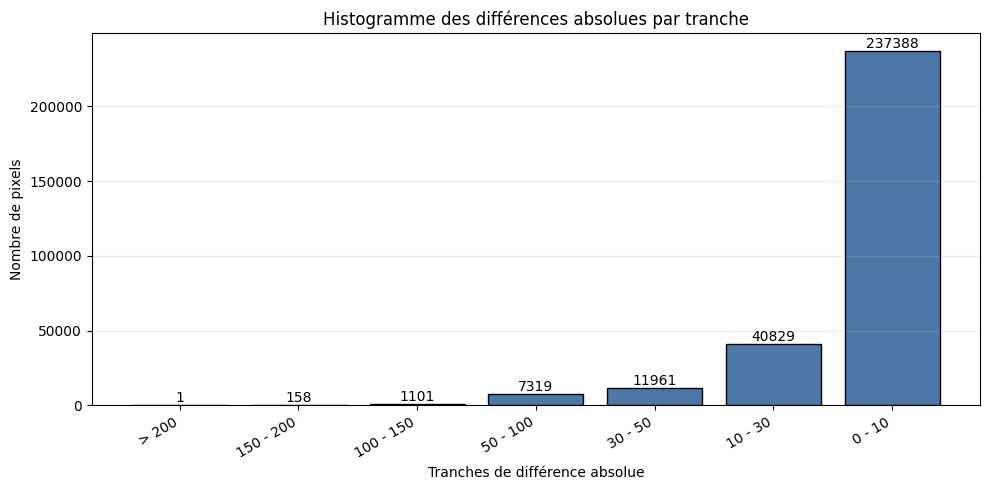

In [62]:
range_labels = [
    "> 200",
    "150 - 200",
    "100 - 150",
    "50 - 100",
    "30 - 50",
    "10 - 30",
    "0 - 10",
]

range_counts = [
    num_gt_200,
    num_150_200,
    num_100_150,
    num_50_100,
    num_30_50,
    num_10_30,
    num_0_10,
]

plt.figure(figsize=(10, 5))
bars = plt.bar(range_labels, range_counts, color="#4C78A8", edgecolor="black")
plt.title("Histogramme des différences absolues par tranche")
plt.xlabel("Tranches de différence absolue")
plt.ylabel("Nombre de pixels")
plt.grid(axis="y", alpha=0.25)
plt.xticks(rotation=30, ha="right")

for bar, count in zip(bars, range_counts):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        str(count),
        ha="center",
        va="bottom",
    )

plt.tight_layout()
plt.show()


### Squared photometric error map

Cette figure n ajoute pas une nouvelle metrique.
Elle sert seulement a voir **ou** l erreur photometrique se concentre dans l image.


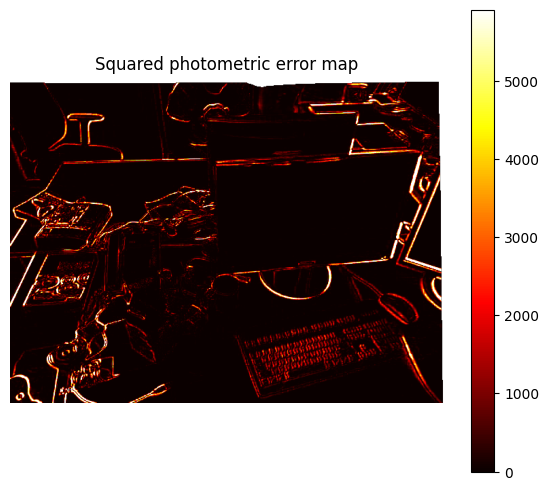

In [63]:
squared_error_map = evaluation["squared_error_map"]
valid_mask = evaluation["valid_mask"]

valid_values = squared_error_map[valid_mask]
vmax_sq = float(np.nanpercentile(valid_values, 99)) if valid_values.size > 0 else 1.0

plt.figure(figsize=(7, 6))
plt.imshow(squared_error_map, cmap="hot", vmin=0, vmax=vmax_sq)
plt.title("Squared photometric error map")
plt.axis("off")
plt.colorbar()
plt.show()


In [64]:
print("Only evaluation metric used in this notebook:")
print("  photometric_error = sum((I_keyframe - I_reprojected)^2) over valid pixels")


Only evaluation metric used in this notebook:
  photometric_error = sum((I_keyframe - I_reprojected)^2) over valid pixels


------
## Scale sur toutes les images

In [65]:


print(len(real_frame_paths))

798


Sequence real:
  source size = 640 x 480
  working size level-0 = 640 x 480
  fx level-0 = 525.0
  fy level-0 = 525.0

[real] frame 0 -> keyframe de reference: frame_00000.png
Depth Anything loaded on cpu (97.47M parameters)
lvl:  4  initial error:  2062.0811843361967
update too small, level converged! it:  4  error:  1242.5559693778052  lambda:  450359962737049.6
lvl:  3  initial error:  858.1635862688839
 error improvement too small, level converged! it:  5  error:  670.0585124604014  lambda:  0.2
lvl:  2  initial error:  294.66691260675555
 error improvement too small, level converged! it:  3  error:  288.7769118997986  lambda:  7036874417766.4
[real] frame 1 -> frame_00001.png | sum error = 88287536.00 | mean abs error = 7.8914 | valid pixels = 298757


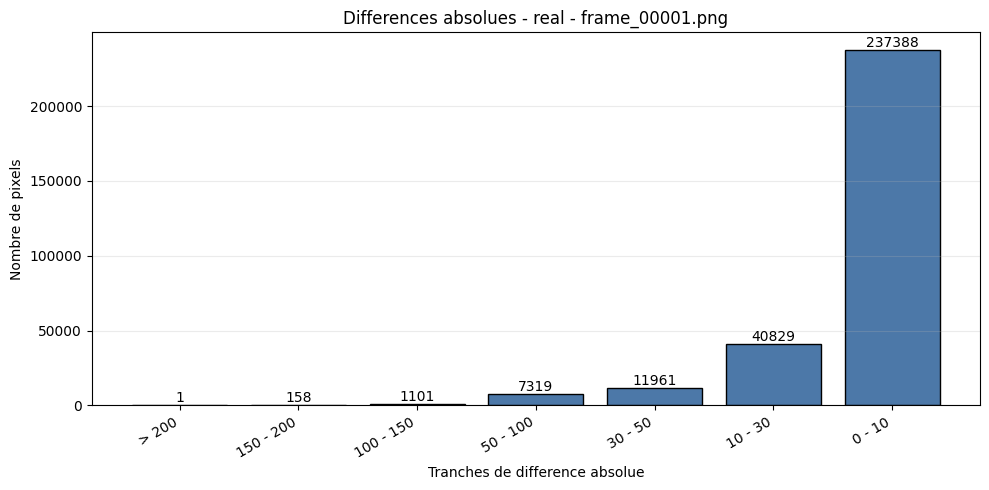

lvl:  4  initial error:  3362.025787965613
 error improvement too small, level converged! it:  4  error:  1101.5157320039352  lambda:  0.4
lvl:  3  initial error:  891.1159392208202
 error improvement too small, level converged! it:  3  error:  817.0366316349977  lambda:  0.0
lvl:  2  initial error:  591.5778002779987
 error improvement too small, level converged! it:  5  error:  554.3376073395826  lambda:  0.0
[real] frame 2 -> frame_00002.png | sum error = 205446496.00 | mean abs error = 12.4948 | valid pixels = 286704


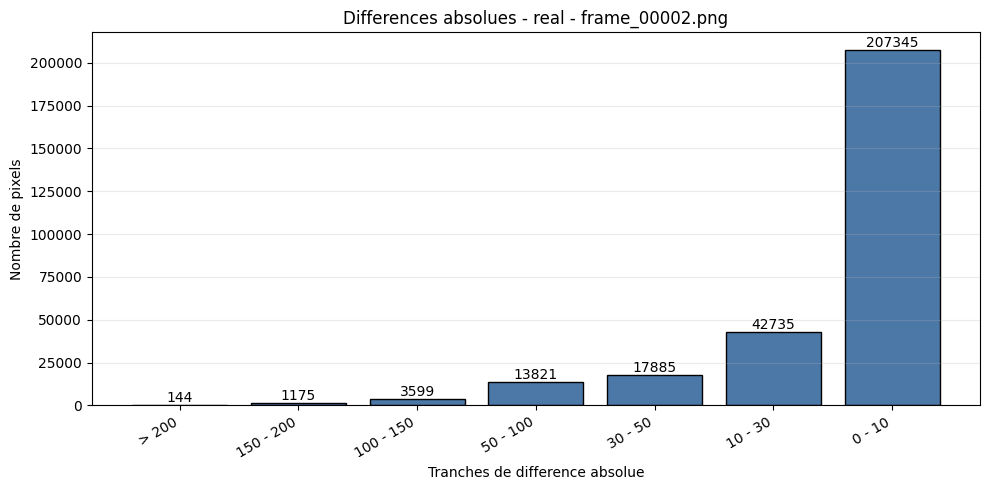

lvl:  4  initial error:  4394.613180515756
update too small, level converged! it:  6  error:  1134.5123951739977  lambda:  900719925474099.2
lvl:  3  initial error:  969.1556792518635
 error improvement too small, level converged! it:  4  error:  825.6746334965746  lambda:  879609302220.8
lvl:  2  initial error:  859.9302956953409
 error improvement too small, level converged! it:  2  error:  856.3459581560456  lambda:  1.6
[real] frame 3 -> frame_00003.png | sum error = 298987968.00 | mean abs error = 15.9306 | valid pixels = 277794


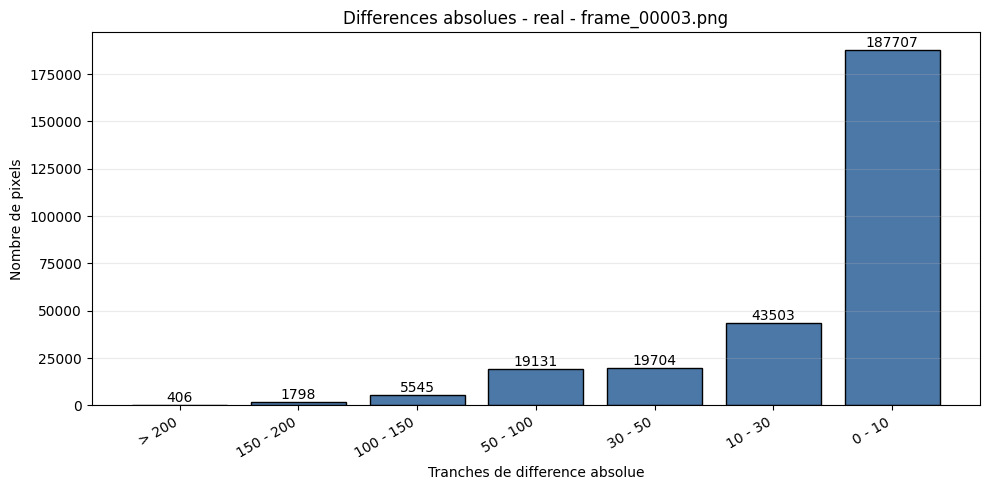

lvl:  4  initial error:  5241.473734479462
 error improvement too small, level converged! it:  9  error:  1233.9277550472295  lambda:  0.1
lvl:  3  initial error:  1151.6507659327096
 error improvement too small, level converged! it:  4  error:  1034.7724203951304  lambda:  0.0
lvl:  2  initial error:  1081.7384968267704
 error improvement too small, level converged! it:  2  error:  1065.8538016470773  lambda:  6.4
[real] frame 4 -> frame_00004.png | sum error = 364818048.00 | mean abs error = 18.9135 | valid pixels = 261176


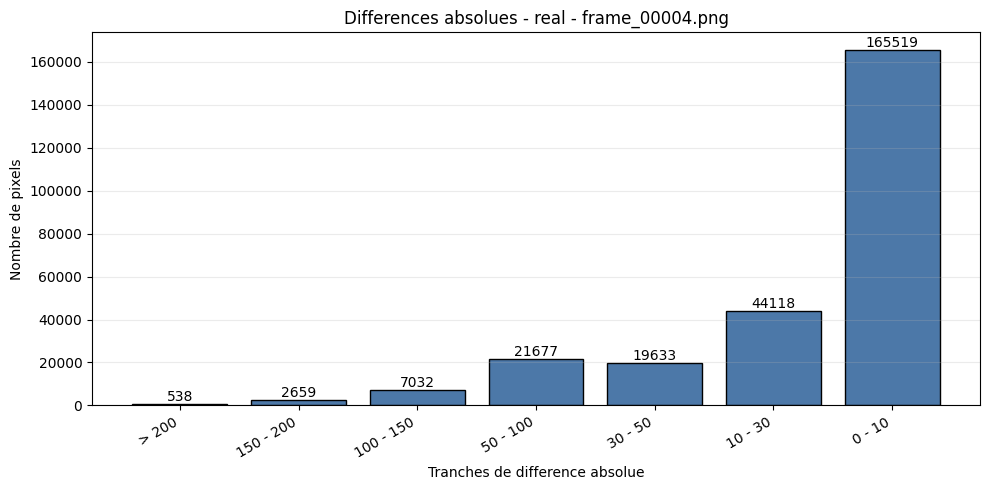

lvl:  4  initial error:  5334.437440305634
 error improvement too small, level converged! it:  4  error:  1211.6045604116662  lambda:  6.4
lvl:  3  initial error:  1320.9300070581799
 error improvement too small, level converged! it:  6  error:  1192.334273124349  lambda:  0.0
lvl:  2  initial error:  1294.3658250399321
 error improvement too small, level converged! it:  16  error:  1233.8547758485047  lambda:  0.0
[real] frame 5 -> frame_00005.png | sum error = 398515424.00 | mean abs error = 20.2305 | valid pixels = 255200


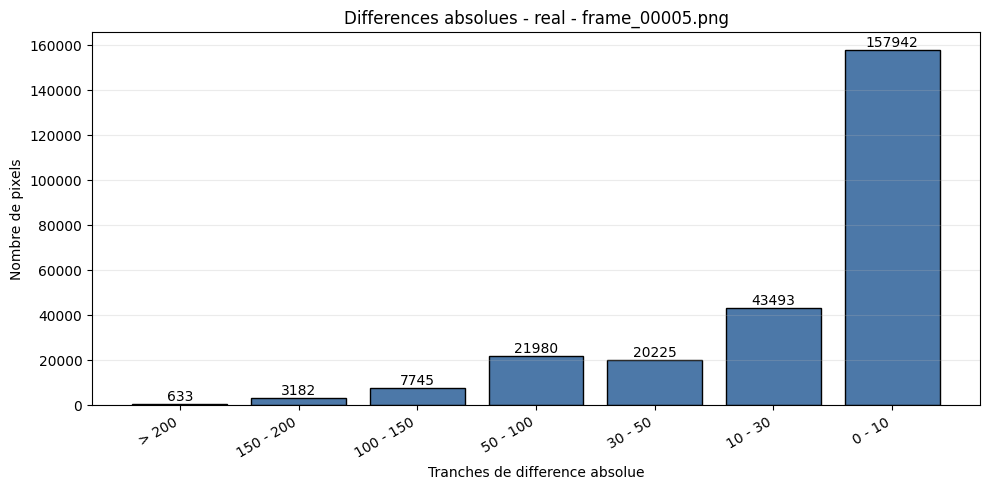

lvl:  4  initial error:  5469.224450811842
 error improvement too small, level converged! it:  5  error:  1360.721604906363  lambda:  25.6
lvl:  3  initial error:  1476.3117139990577
 error improvement too small, level converged! it:  2  error:  1420.6579777080453  lambda:  0.4
lvl:  2  initial error:  1485.4134837503302
 error improvement too small, level converged! it:  2  error:  1470.2532075038255  lambda:  0.8
[real] frame 6 -> frame_00006.png | sum error = 474265472.00 | mean abs error = 25.1854 | valid pixels = 253516


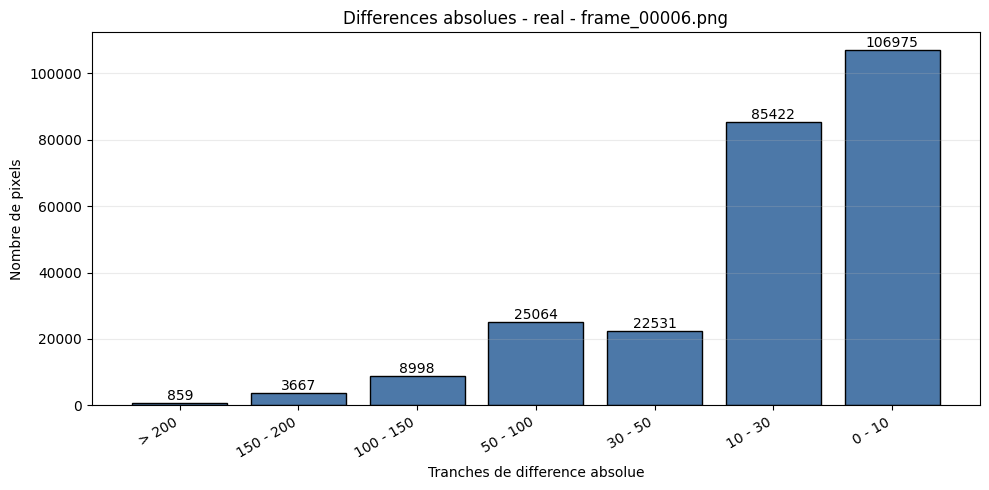

lvl:  4  initial error:  5810.332378223494
 error improvement too small, level converged! it:  5  error:  1207.0336495191655  lambda:  0.4
lvl:  3  initial error:  1394.3606746049873
 error improvement too small, level converged! it:  5  error:  1271.7877676364617  lambda:  219902325555.2
lvl:  2  initial error:  1443.865440779258
 error improvement too small, level converged! it:  3  error:  1416.1071532096942  lambda:  0.0
[real] frame 7 -> frame_00007.png | sum error = 423479168.00 | mean abs error = 24.4701 | valid pixels = 243908


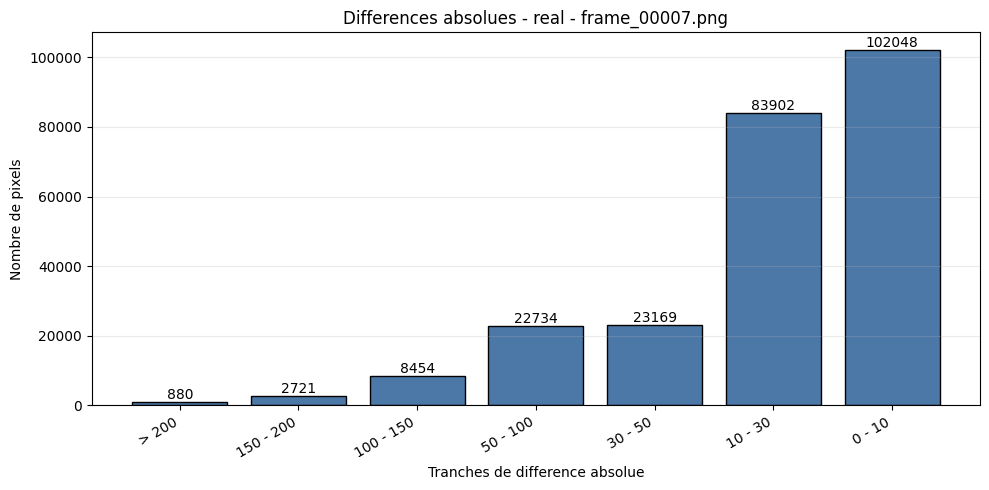

lvl:  4  initial error:  6166.429799426934
update too small, level converged! it:  4  error:  1271.9914455868995  lambda:  900719925474099.2
lvl:  3  initial error:  1430.1418385202044
 error improvement too small, level converged! it:  5  error:  1254.4784071502636  lambda:  7036874417766.4
lvl:  2  initial error:  1428.3720794769822
 error improvement too small, level converged! it:  4  error:  1372.6917038937004  lambda:  0.0
[real] frame 8 -> frame_00008.png | sum error = 392503808.00 | mean abs error = 24.1410 | valid pixels = 239324


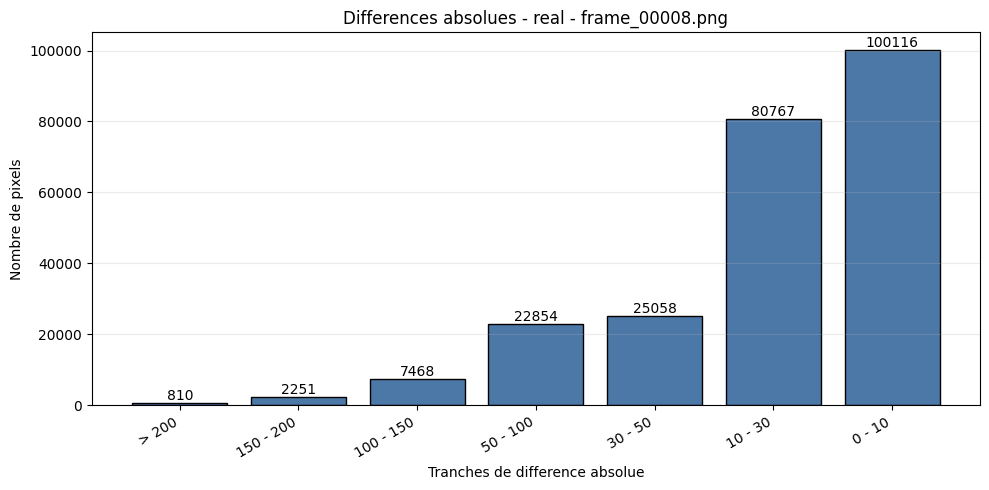

lvl:  4  initial error:  6737.461318051576
 error improvement too small, level converged! it:  6  error:  1335.7999143432014  lambda:  3.2
lvl:  3  initial error:  1650.4220277701995
 error improvement too small, level converged! it:  4  error:  1361.6663343659188  lambda:  0.0
lvl:  2  initial error:  1561.6991109539597
 error improvement too small, level converged! it:  5  error:  1525.7530754905426  lambda:  0.0
[real] frame 9 -> frame_00009.png | sum error = 440533632.00 | mean abs error = 25.8932 | valid pixels = 235936


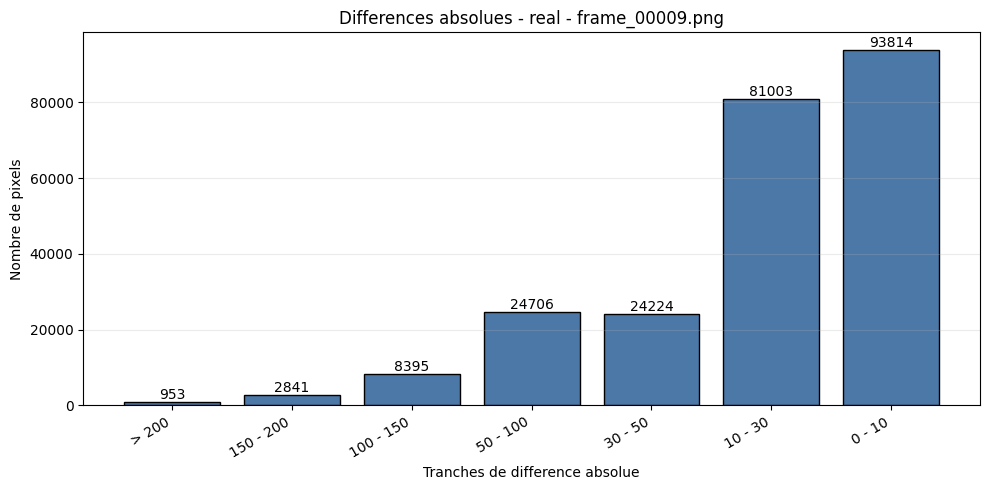

lvl:  4  initial error:  7131.263610315185
update too small, level converged! it:  5  error:  1473.047480087216  lambda:  1801439850948198.5
lvl:  3  initial error:  1792.193220885931
 error improvement too small, level converged! it:  6  error:  1559.104100854127  lambda:  0.0
lvl:  2  initial error:  1697.5556745409158
 error improvement too small, level converged! it:  1  error:  1697.0646775095345  lambda:  0.8
[real] frame 10 -> frame_00010.png | sum error = 470108192.00 | mean abs error = 26.9968 | valid pixels = 232509


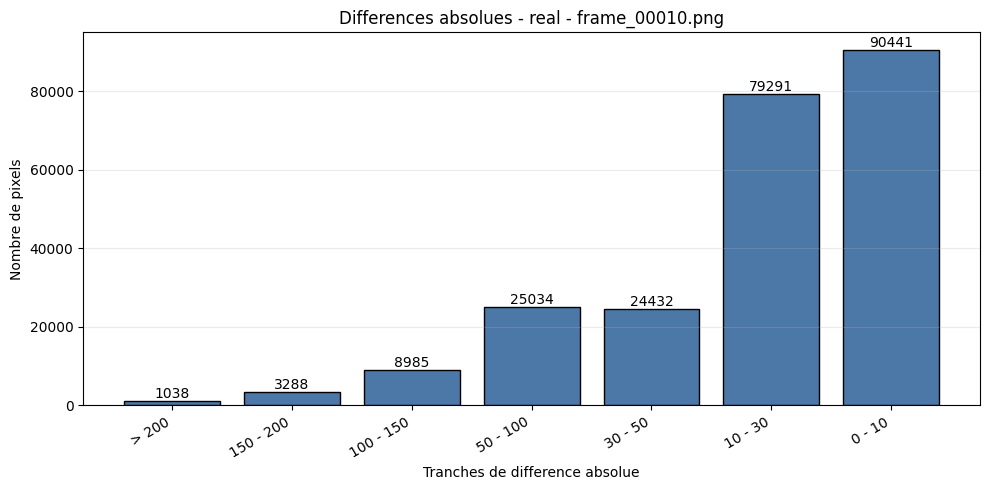

lvl:  4  initial error:  7513.827125119388
 error improvement too small, level converged! it:  6  error:  1622.4876372328263  lambda:  0.0
lvl:  3  initial error:  1775.2894436055171
 error improvement too small, level converged! it:  3  error:  1644.5989966569662  lambda:  6.4
lvl:  2  initial error:  1846.7948373221777
 error improvement too small, level converged! it:  1  error:  1845.5976221897154  lambda:  0.0
[real] frame 11 -> frame_00011.png | sum error = 500740800.00 | mean abs error = 28.1903 | valid pixels = 228286


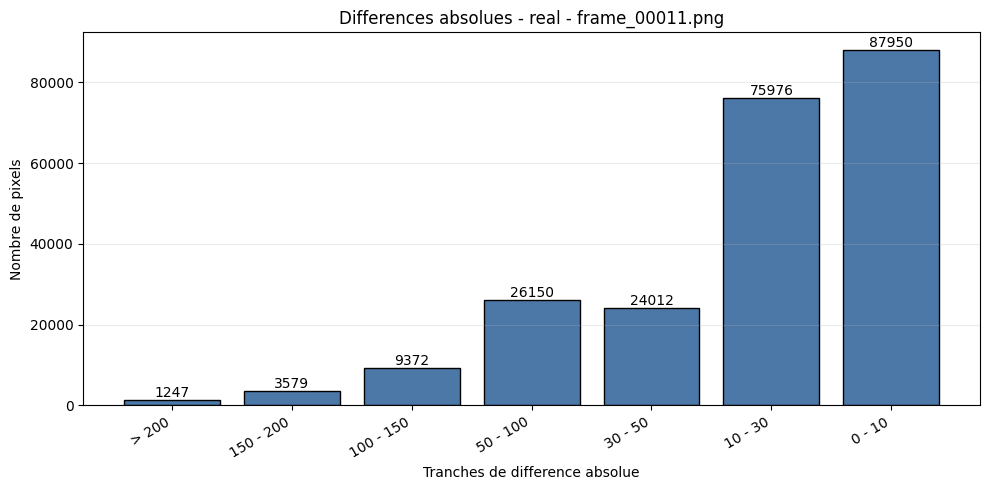

lvl:  4  initial error:  7075.25405921681
 error improvement too small, level converged! it:  4  error:  2012.6564925462305  lambda:  25.6
lvl:  3  initial error:  2325.9045406366513
update too small, level converged! it:  6  error:  2214.5725933217527  lambda:  450359962737049.6
lvl:  2  initial error:  2389.138712953323
 error improvement too small, level converged! it:  4  error:  2363.791929003103  lambda:  0.0
[real] frame 12 -> frame_00012.png | sum error = 637843008.00 | mean abs error = 35.5688 | valid pixels = 229694


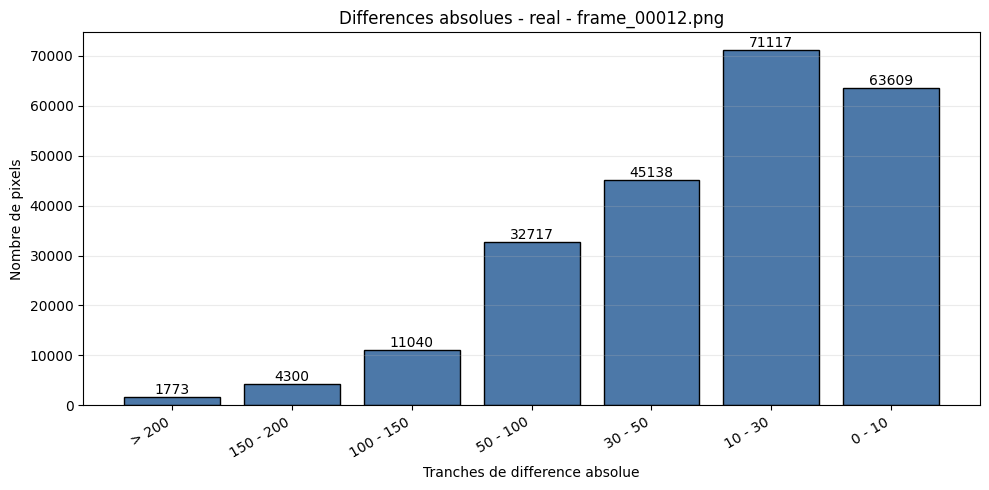

lvl:  4  initial error:  7060.642788920726
 error improvement too small, level converged! it:  5  error:  2079.7130200481324  lambda:  0.8
lvl:  3  initial error:  2433.383053214802
 error improvement too small, level converged! it:  3  error:  2293.0720802110513  lambda:  0.0
lvl:  2  initial error:  2472.163076469727
 error improvement too small, level converged! it:  1  error:  2469.782086136264  lambda:  0.0
[real] frame 13 -> frame_00013.png | sum error = 650040192.00 | mean abs error = 36.1437 | valid pixels = 228314


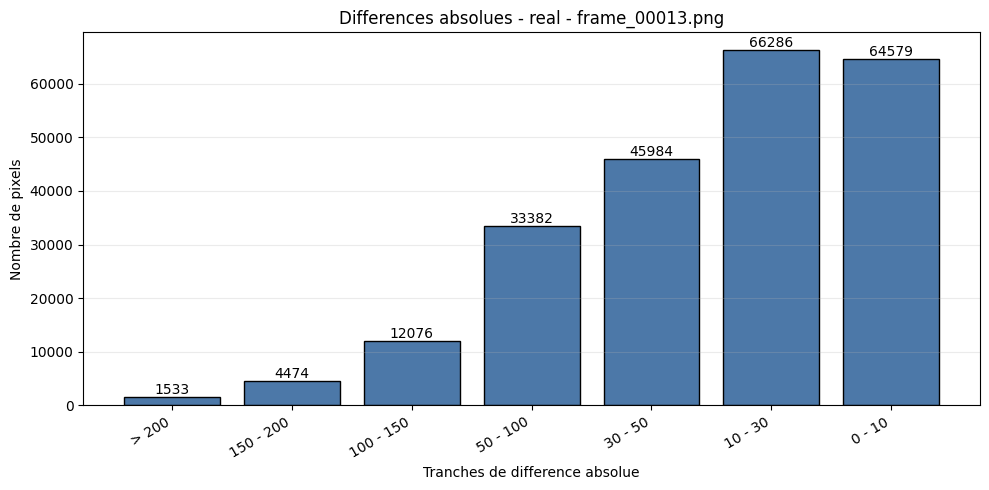

lvl:  4  initial error:  7215.194842406876
 error improvement too small, level converged! it:  5  error:  2196.6526376814295  lambda:  3.2
lvl:  3  initial error:  2527.5822781958673
 error improvement too small, level converged! it:  4  error:  2376.882206682746  lambda:  0.2
lvl:  2  initial error:  2620.376216221017
 error improvement too small, level converged! it:  4  error:  2590.7217874701514  lambda:  1759218604441.6
[real] frame 14 -> frame_00014.png | sum error = 680059008.00 | mean abs error = 37.1152 | valid pixels = 226444


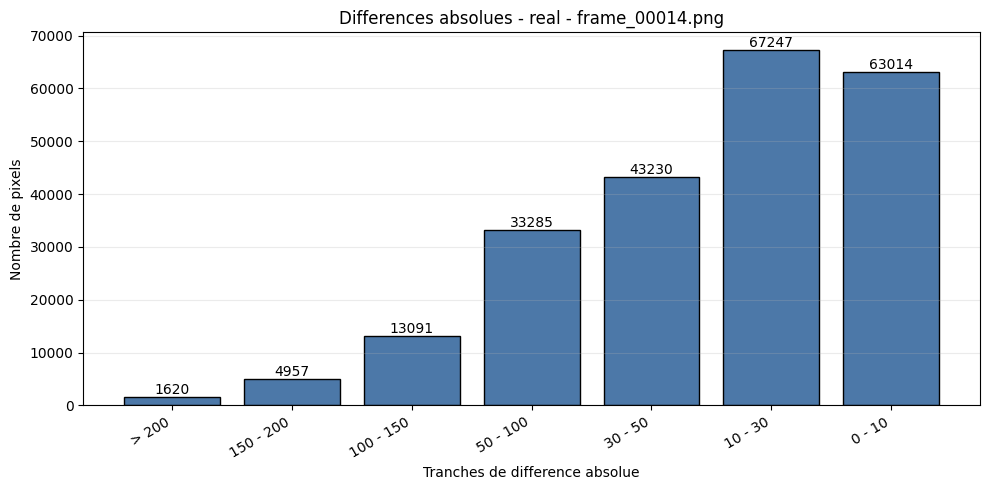

lvl:  4  initial error:  7237.113658070678
 error improvement too small, level converged! it:  4  error:  2275.347450356374  lambda:  879609302220.8
lvl:  3  initial error:  2697.2290477090237
 error improvement too small, level converged! it:  5  error:  2553.525822672288  lambda:  0.2
lvl:  2  initial error:  2734.409354029084
 error improvement too small, level converged! it:  1  error:  2734.409354029083  lambda:  109951162777.6
[real] frame 15 -> frame_00015.png | sum error = 712926464.00 | mean abs error = 38.1017 | valid pixels = 227040


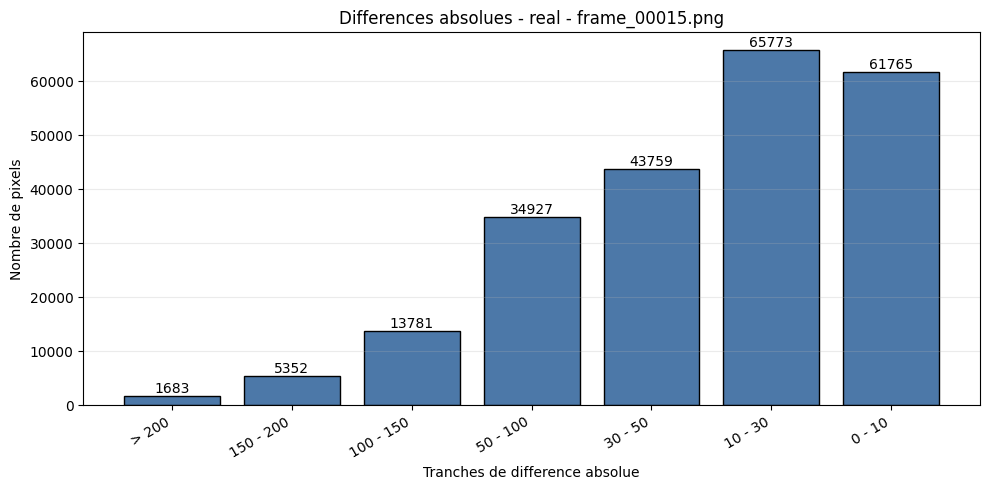

lvl:  4  initial error:  7032.401146131805
 error improvement too small, level converged! it:  5  error:  2399.3009986373227  lambda:  0.0
lvl:  3  initial error:  2729.204340712801
 error improvement too small, level converged! it:  4  error:  2641.1731605554774  lambda:  0.0
lvl:  2  initial error:  2883.1894065526367
 error improvement too small, level converged! it:  1  error:  2881.7421039909973  lambda:  0.0
[real] frame 16 -> frame_00016.png | sum error = 746272960.00 | mean abs error = 39.0394 | valid pixels = 225970


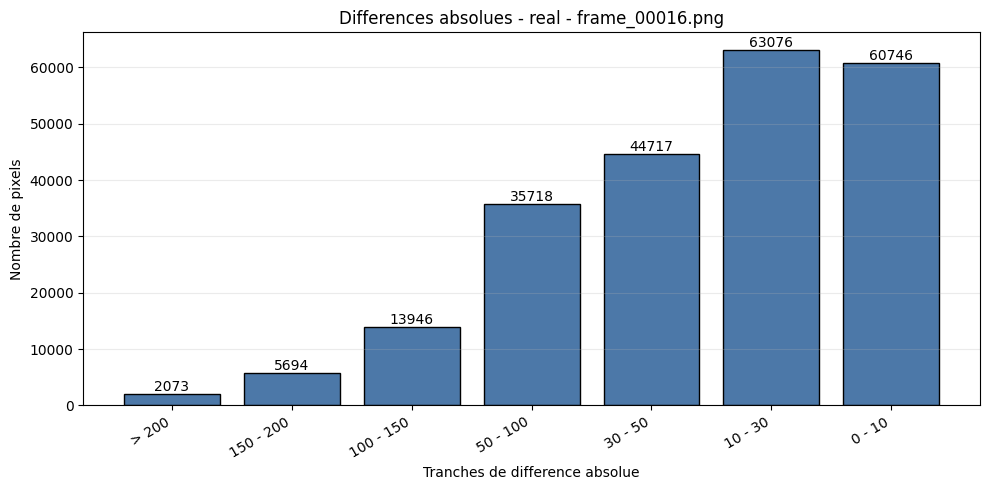

lvl:  4  initial error:  7279.14899713467
 error improvement too small, level converged! it:  3  error:  2377.4671072295014  lambda:  0.2
lvl:  3  initial error:  2938.938642703053
 error improvement too small, level converged! it:  3  error:  2697.1149029825083  lambda:  0.0
lvl:  2  initial error:  2961.2279912589324
 error improvement too small, level converged! it:  1  error:  2961.1596140948095  lambda:  51.2
[real] frame 17 -> frame_00017.png | sum error = 751296064.00 | mean abs error = 39.5456 | valid pixels = 225980


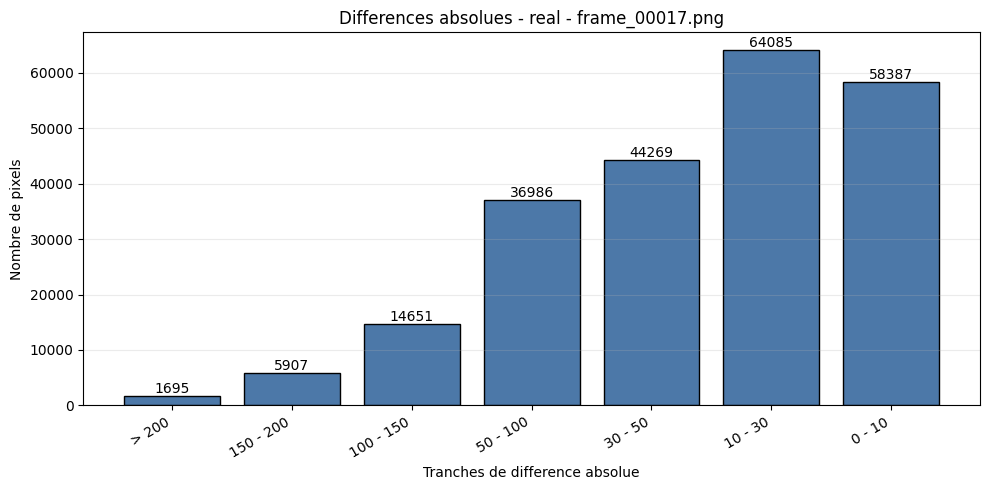

lvl:  4  initial error:  7384.312320916904
 error improvement too small, level converged! it:  3  error:  2438.3588325284477  lambda:  3.2
lvl:  3  initial error:  2921.1645570579044
 error improvement too small, level converged! it:  3  error:  2877.549591784356  lambda:  56294995342131.2
lvl:  2  initial error:  3108.7269613811563
 error improvement too small, level converged! it:  1  error:  3108.1092359688546  lambda:  0.1
[real] frame 18 -> frame_00018.png | sum error = 786112704.00 | mean abs error = 40.6878 | valid pixels = 224292


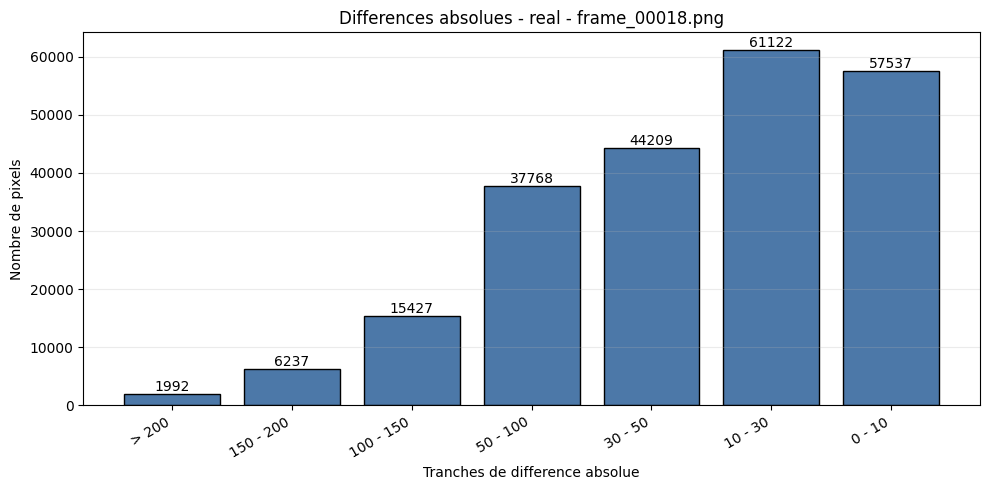

lvl:  4  initial error:  7487.55969436485
 error improvement too small, level converged! it:  3  error:  2585.202597133631  lambda:  12.8
lvl:  3  initial error:  2963.0282462227838
 error improvement too small, level converged! it:  8  error:  2862.4532853633546  lambda:  0.0
lvl:  2  initial error:  3125.596382801967
 error improvement too small, level converged! it:  1  error:  3124.018830863291  lambda:  0.1
[real] frame 19 -> frame_00019.png | sum error = 782396544.00 | mean abs error = 41.0362 | valid pixels = 222089


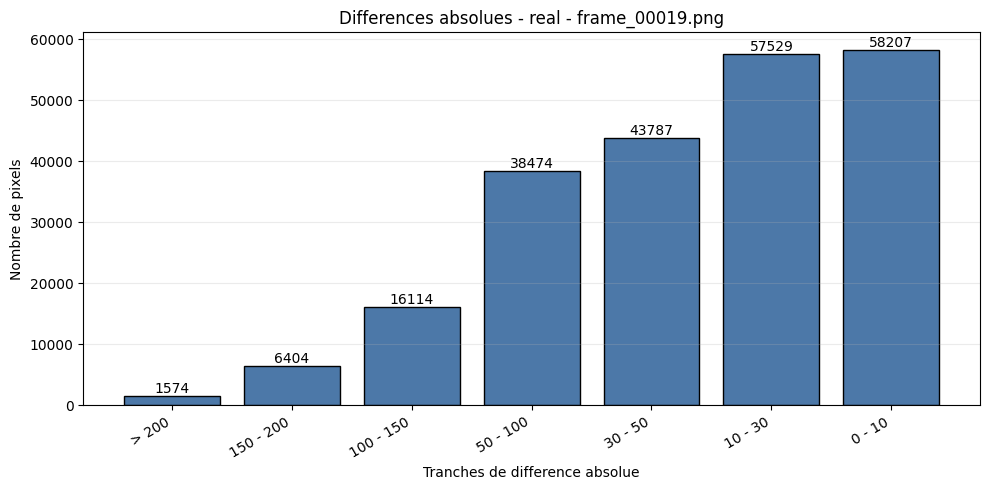

lvl:  4  initial error:  7326.470869149952
 error improvement too small, level converged! it:  5  error:  2641.9627128147667  lambda:  3.2
lvl:  3  initial error:  3163.6879679927906
 error improvement too small, level converged! it:  6  error:  3034.768755665931  lambda:  0.0
lvl:  2  initial error:  3246.457543772065
 error improvement too small, level converged! it:  6  error:  3216.5761008005315  lambda:  0.0
[real] frame 20 -> frame_00020.png | sum error = 789906048.00 | mean abs error = 41.3806 | valid pixels = 220485


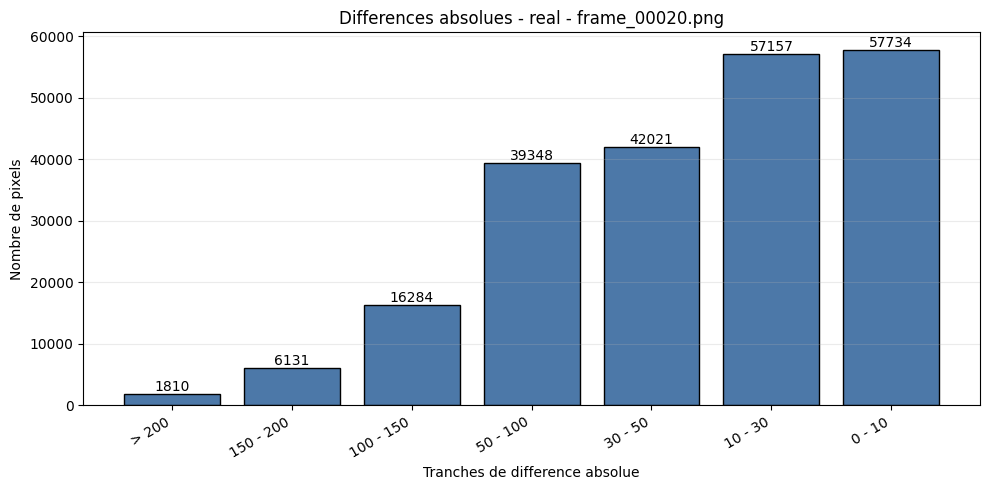

lvl:  4  initial error:  7547.516714422157
update too small, level converged! it:  5  error:  2724.178232077613  lambda:  900719925474099.2
lvl:  3  initial error:  3218.7460398183803
 error improvement too small, level converged! it:  3  error:  3130.339115077172  lambda:  3.2
lvl:  2  initial error:  3368.626837198811
 error improvement too small, level converged! it:  4  error:  3328.8271888092418  lambda:  6.4
[real] frame 21 -> frame_00021.png | sum error = 813150976.00 | mean abs error = 41.8306 | valid pixels = 219655


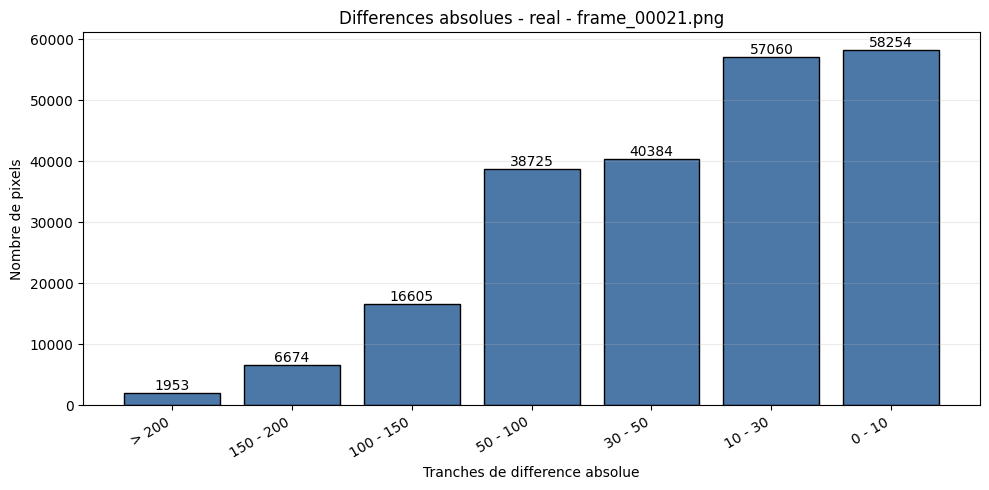

lvl:  4  initial error:  7581.966571155681
 error improvement too small, level converged! it:  5  error:  2736.1659853035917  lambda:  0.1
lvl:  3  initial error:  3350.3702427977128
 error improvement too small, level converged! it:  5  error:  3163.52994671086  lambda:  0.0
lvl:  2  initial error:  3361.752217017936
 error improvement too small, level converged! it:  2  error:  3346.089716130698  lambda:  0.0
[real] frame 22 -> frame_00022.png | sum error = 811999680.00 | mean abs error = 42.0542 | valid pixels = 216480


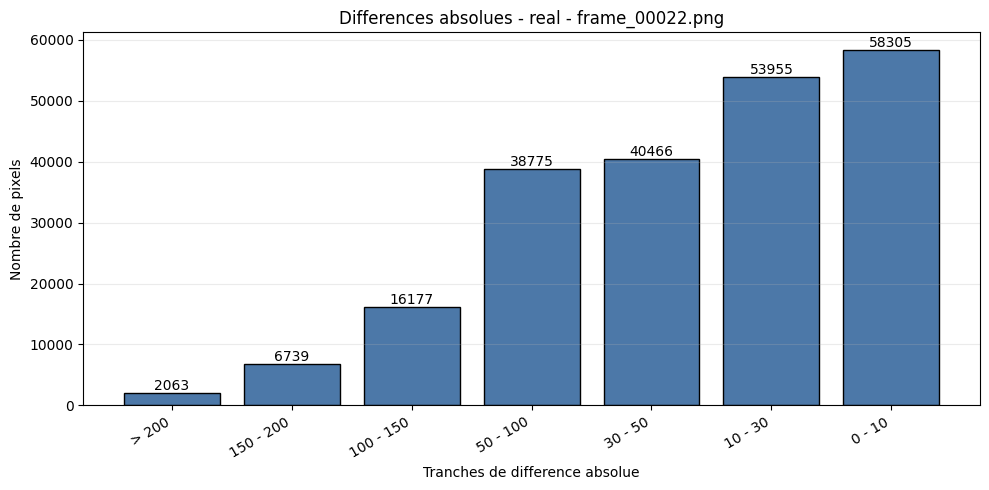

lvl:  4  initial error:  7579.292263610313
 error improvement too small, level converged! it:  5  error:  2769.09872085905  lambda:  3.2
lvl:  3  initial error:  3391.2908163372385
 error improvement too small, level converged! it:  8  error:  3155.4917880358803  lambda:  0.1
lvl:  2  initial error:  3466.516614817775
 error improvement too small, level converged! it:  3  error:  3449.4257353513276  lambda:  0.0
[real] frame 23 -> frame_00023.png | sum error = 832202496.00 | mean abs error = 42.8576 | valid pixels = 216780


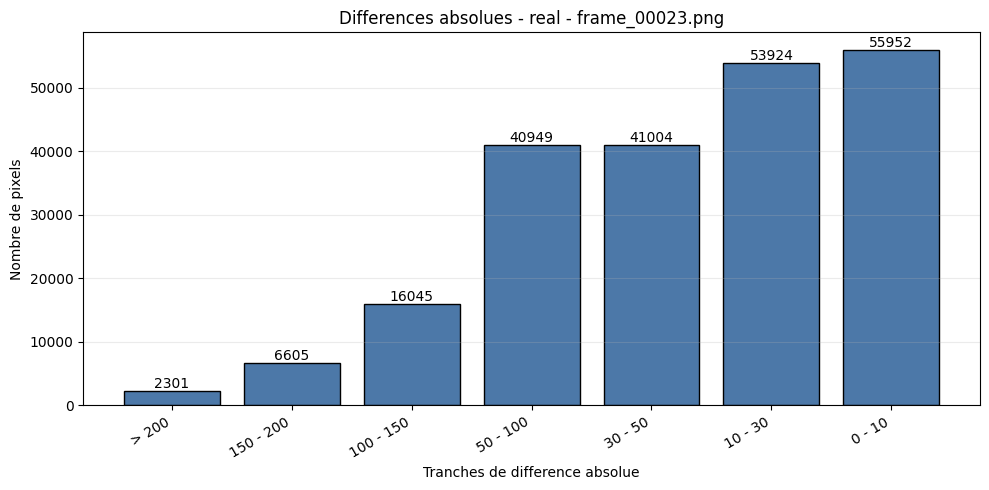

lvl:  4  initial error:  7515.723018147084
 error improvement too small, level converged! it:  6  error:  2718.165045416951  lambda:  102.4
lvl:  3  initial error:  3320.3405149999408
 error improvement too small, level converged! it:  4  error:  3127.7760847724376  lambda:  0.0
lvl:  2  initial error:  3401.185313880486
 error improvement too small, level converged! it:  3  error:  3387.1436338867707  lambda:  6.4
[real] frame 24 -> frame_00024.png | sum error = 795210816.00 | mean abs error = 42.5812 | valid pixels = 211313


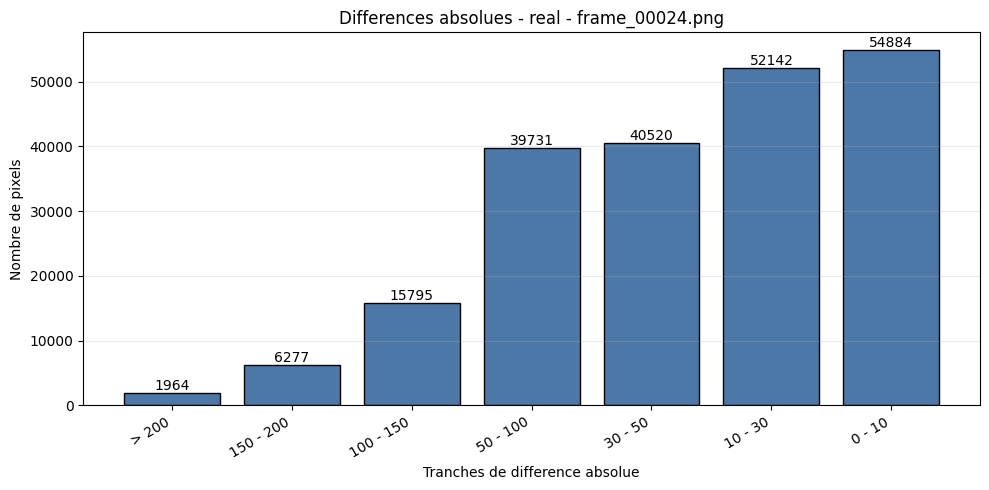

lvl:  4  initial error:  7456.616045845271
 error improvement too small, level converged! it:  5  error:  2879.291661728605  lambda:  0.1
lvl:  3  initial error:  3518.2703830373707
 error improvement too small, level converged! it:  9  error:  3290.3470652953297  lambda:  0.0
lvl:  2  initial error:  3590.7797709903152
 error improvement too small, level converged! it:  2  error:  3582.601872631518  lambda:  3.2
[real] frame 25 -> frame_00025.png | sum error = 833939648.00 | mean abs error = 43.8218 | valid pixels = 210139


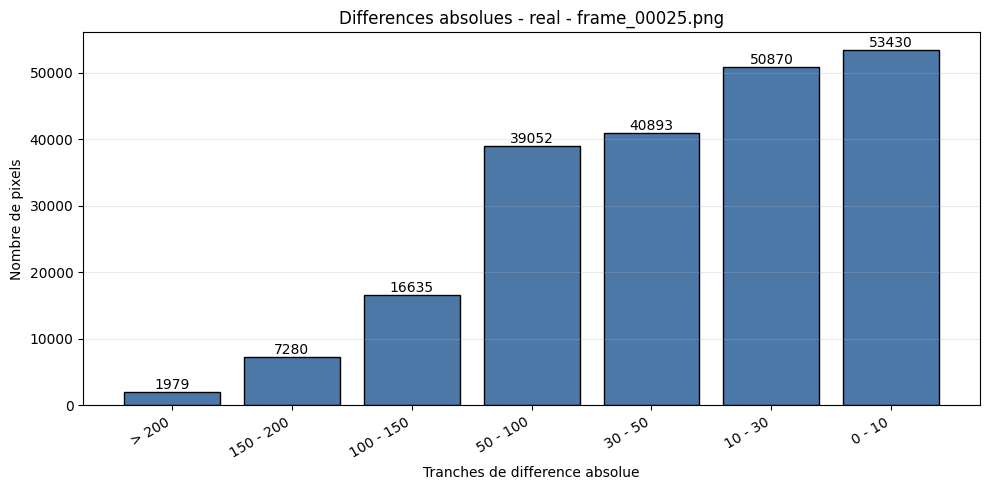

lvl:  4  initial error:  7425.360076408785
 error improvement too small, level converged! it:  4  error:  3045.3788873753806  lambda:  25.6
lvl:  3  initial error:  3507.503738629243
update too small, level converged! it:  5  error:  3461.7833950266377  lambda:  450359962737049.6
lvl:  2  initial error:  3793.64472954592
 error improvement too small, level converged! it:  4  error:  3762.7324684781706  lambda:  0.0
[real] frame 26 -> frame_00026.png | sum error = 857014528.00 | mean abs error = 44.7458 | valid pixels = 206637


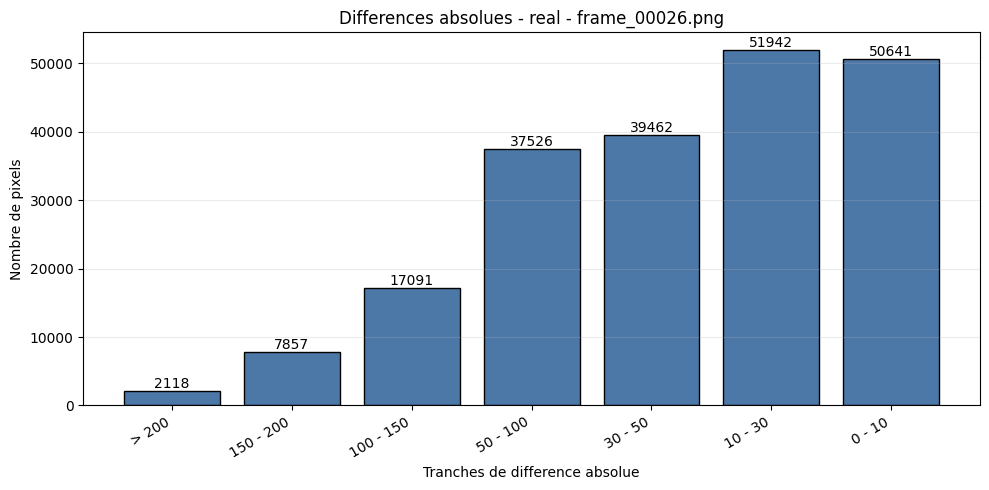

lvl:  4  initial error:  7386.711556829034
 error improvement too small, level converged! it:  4  error:  3341.4674294890383  lambda:  0.0
lvl:  3  initial error:  3651.770861007725
 error improvement too small, level converged! it:  3  error:  3608.6358233928254  lambda:  879609302220.8
lvl:  2  initial error:  3958.398897404124
 error improvement too small, level converged! it:  2  error:  3944.5522215317847  lambda:  0.0
[real] frame 27 -> frame_00027.png | sum error = 902331904.00 | mean abs error = 45.7918 | valid pixels = 206677


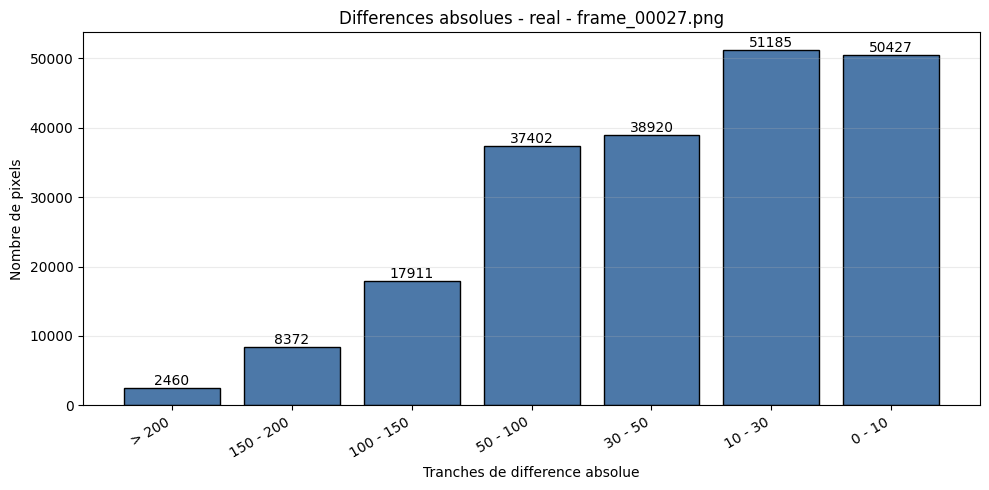

lvl:  4  initial error:  7464.054441260744
 error improvement too small, level converged! it:  4  error:  3397.936808041119  lambda:  12.8
lvl:  3  initial error:  3705.5019170146647
 error improvement too small, level converged! it:  3  error:  3649.4548415405748  lambda:  1.6
lvl:  2  initial error:  4002.850238334035
 error improvement too small, level converged! it:  1  error:  3999.462806145771  lambda:  0.0
[real] frame 28 -> frame_00028.png | sum error = 906577280.00 | mean abs error = 46.0241 | valid pixels = 206550


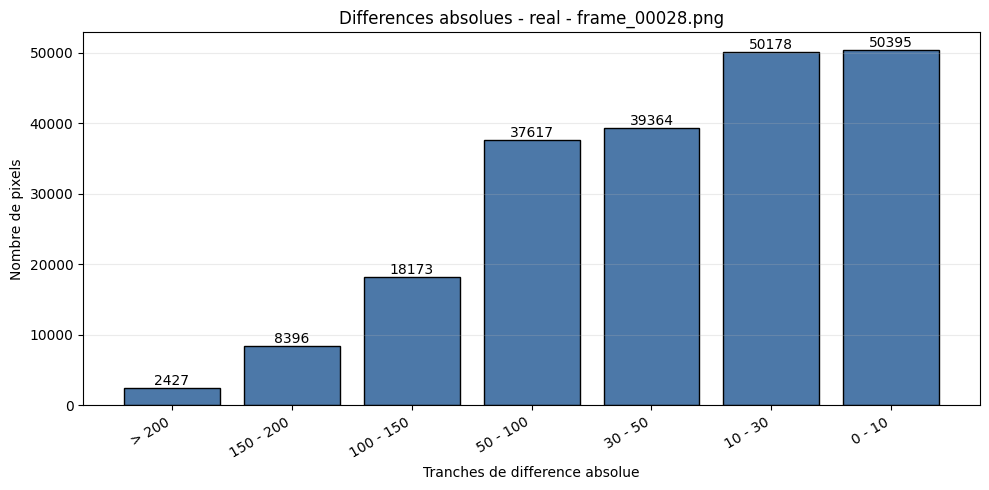

lvl:  4  initial error:  7634.106017191975
 error improvement too small, level converged! it:  6  error:  3489.2408145931017  lambda:  1759218604441.6
lvl:  3  initial error:  3869.527393072227
 error improvement too small, level converged! it:  4  error:  3727.709452034916  lambda:  204.8
lvl:  2  initial error:  4067.147366576574
 error improvement too small, level converged! it:  6  error:  4029.083198259489  lambda:  0.0
[real] frame 29 -> frame_00029.png | sum error = 911984256.00 | mean abs error = 46.2550 | valid pixels = 204246


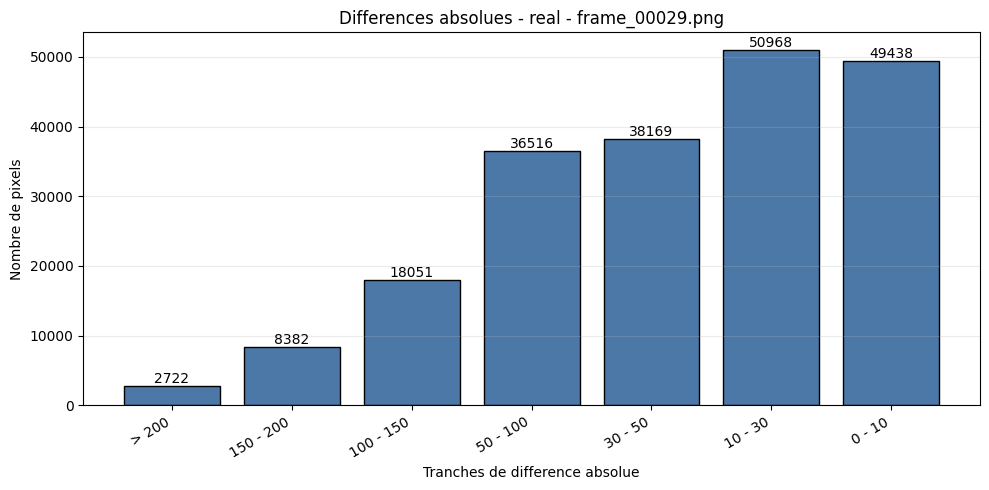

lvl:  4  initial error:  7349.512893982807
 error improvement too small, level converged! it:  3  error:  3279.54083813403  lambda:  879609302220.8
lvl:  3  initial error:  3796.950096050257
 error improvement too small, level converged! it:  5  error:  3759.516886280879  lambda:  0.0
lvl:  2  initial error:  4044.6920609285403
 error improvement too small, level converged! it:  1  error:  4040.7609133005085  lambda:  0.0
[real] frame 30 -> frame_00030.png | sum error = 895399616.00 | mean abs error = 46.5092 | valid pixels = 202213


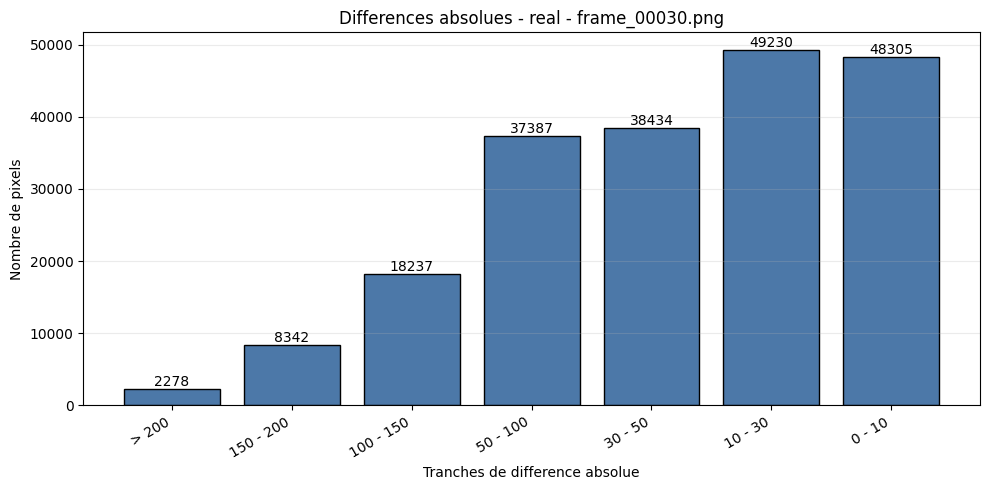

lvl:  4  initial error:  7425.106017191977
 error improvement too small, level converged! it:  7  error:  2848.0374916233163  lambda:  7036874417766.4
lvl:  3  initial error:  3570.5597282832014
 error improvement too small, level converged! it:  2  error:  3503.8539351339487  lambda:  0.0
lvl:  2  initial error:  3875.7934256406793
 error improvement too small, level converged! it:  1  error:  3873.9159454867818  lambda:  12.8
[real] frame 31 -> frame_00031.png | sum error = 834055104.00 | mean abs error = 46.1639 | valid pixels = 193226


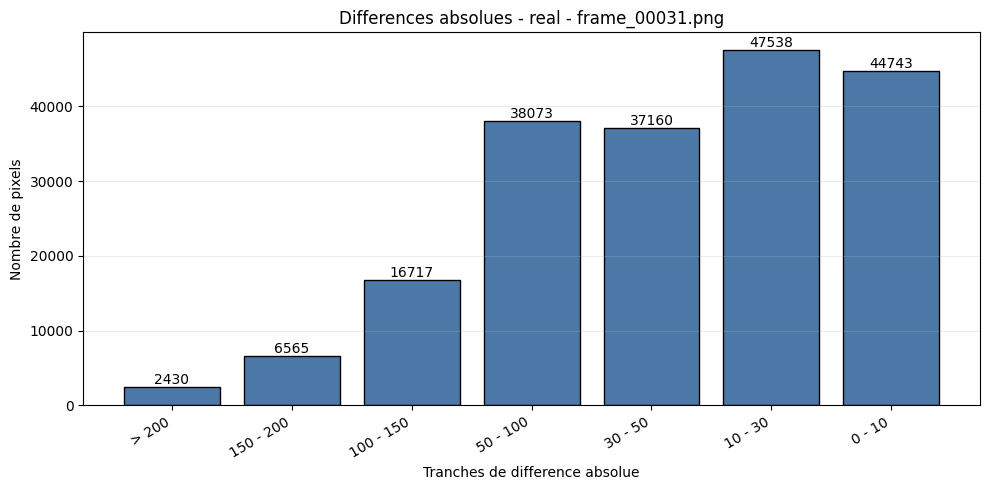

lvl:  4  initial error:  7340.978032473735
 error improvement too small, level converged! it:  13  error:  2601.337850748697  lambda:  12.8
lvl:  3  initial error:  3287.7427589993717
 error improvement too small, level converged! it:  4  error:  3130.2004384497473  lambda:  6.4
lvl:  2  initial error:  3350.7246588620565
 error improvement too small, level converged! it:  3  error:  3318.017048567638  lambda:  0.8
[real] frame 32 -> frame_00032.png | sum error = 587683200.00 | mean abs error = 44.1479 | valid pixels = 161180


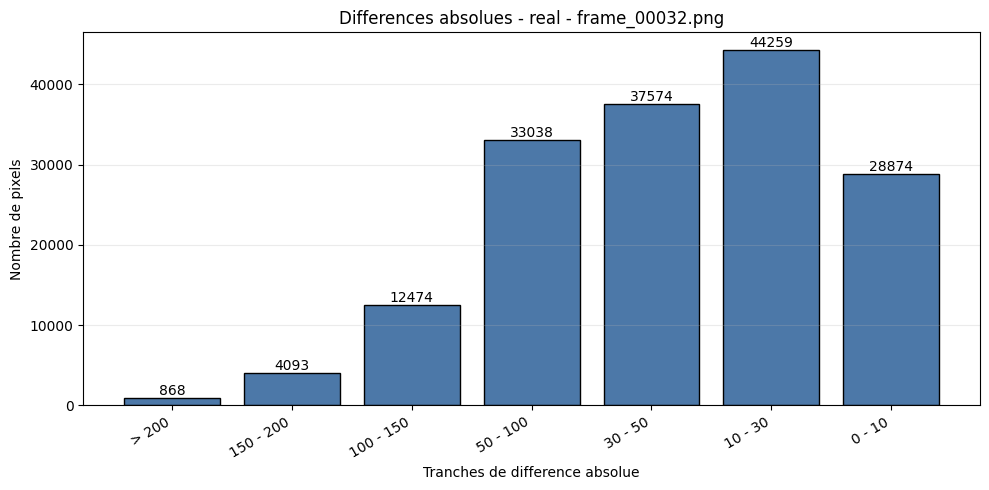

lvl:  4  initial error:  7866.563514804202
 error improvement too small, level converged! it:  6  error:  2421.784976951938  lambda:  0.1
lvl:  3  initial error:  3047.2109034010605
 error improvement too small, level converged! it:  7  error:  2724.128949046405  lambda:  0.8
lvl:  2  initial error:  2950.0336945384056
 error improvement too small, level converged! it:  11  error:  2760.557800662126  lambda:  0.0
[real] frame 33 -> frame_00033.png | sum error = 433437280.00 | mean abs error = 39.7777 | valid pixels = 142775


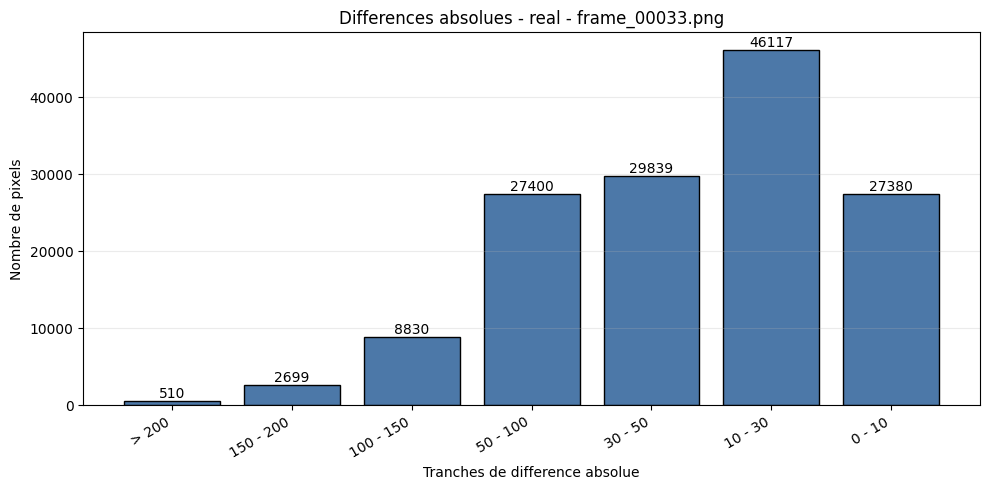

lvl:  4  initial error:  8200.539637058262
 error improvement too small, level converged! it:  8  error:  2134.8283063047484  lambda:  7036874417766.4
lvl:  3  initial error:  2710.305728236594
 error improvement too small, level converged! it:  6  error:  2568.2417818899125  lambda:  109951162777.6
lvl:  2  initial error:  2763.296134583683
 error improvement too small, level converged! it:  5  error:  2673.5030825755634  lambda:  0.1
[real] frame 34 -> frame_00034.png | sum error = 420831392.00 | mean abs error = 37.5744 | valid pixels = 140315


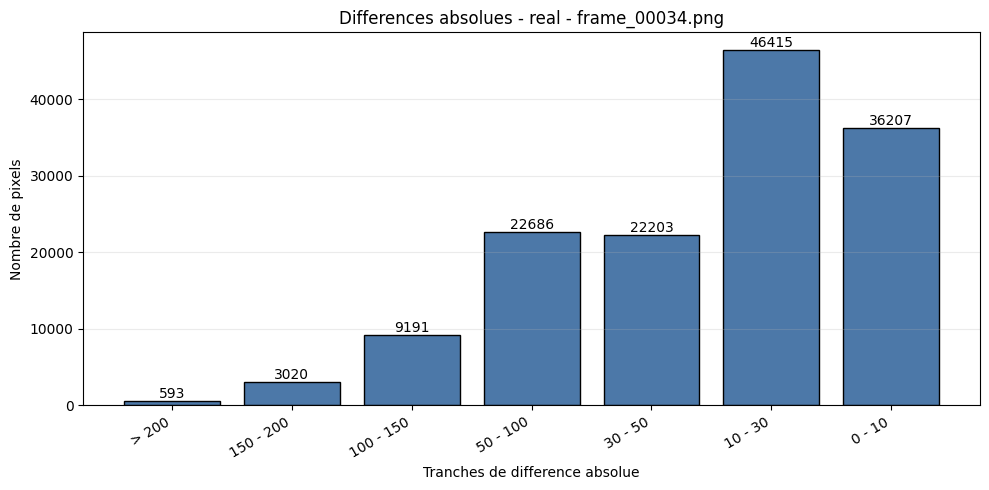

lvl:  4  initial error:  7818.99617956065
 error improvement too small, level converged! it:  3  error:  2716.0839348374543  lambda:  14073748835532.8
lvl:  3  initial error:  3317.341248077712
 error improvement too small, level converged! it:  5  error:  3134.786680257298  lambda:  1.6
lvl:  2  initial error:  3311.3380126337056
 error improvement too small, level converged! it:  16  error:  3130.1781561135867  lambda:  0.0
[real] frame 35 -> frame_00035.png | sum error = 494714336.00 | mean abs error = 43.1952 | valid pixels = 141179


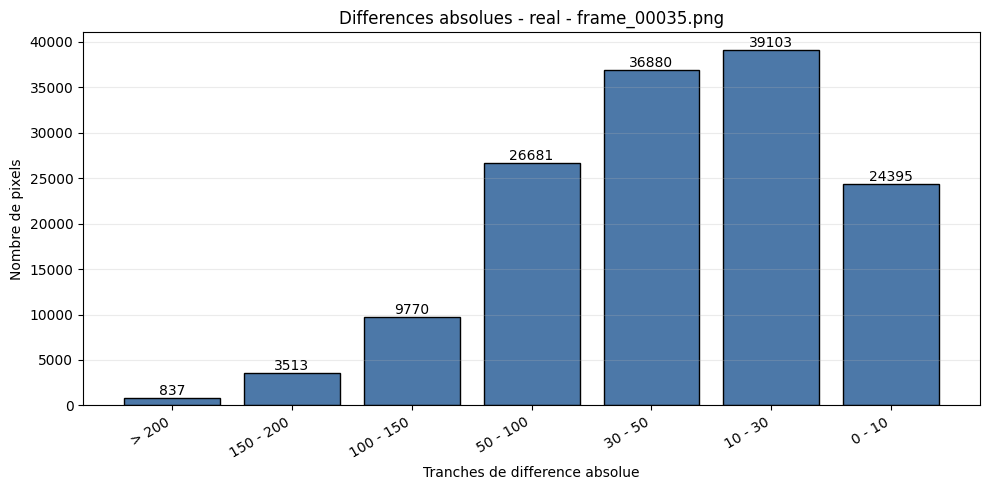

lvl:  4  initial error:  7947.398280802291
 error improvement too small, level converged! it:  5  error:  2684.429329737768  lambda:  0.0
lvl:  3  initial error:  3228.6094746675026
 error improvement too small, level converged! it:  14  error:  2896.2167401071924  lambda:  0.1
lvl:  2  initial error:  3065.26803475534
 error improvement too small, level converged! it:  13  error:  2874.713195241044  lambda:  0.0
[real] frame 36 -> frame_00036.png | sum error = 447576672.00 | mean abs error = 40.5753 | valid pixels = 139565


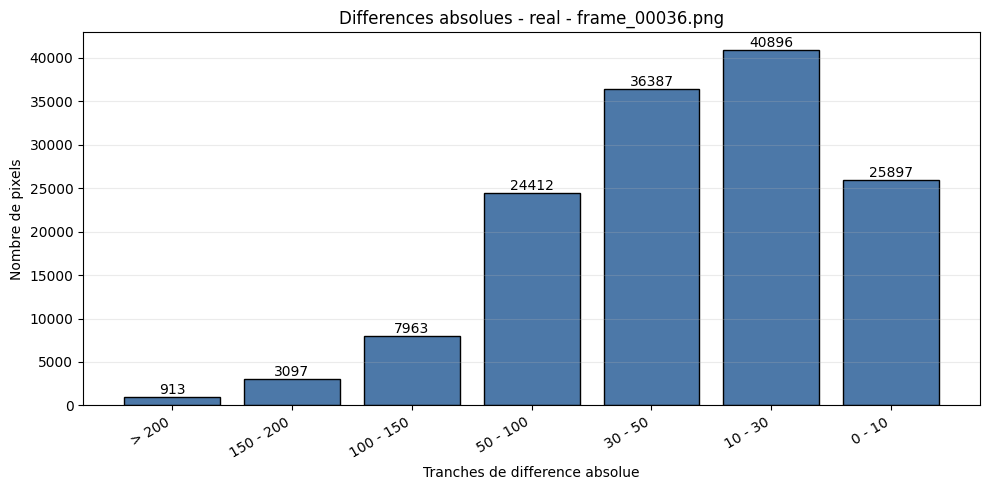

lvl:  4  initial error:  7857.902578796561
 error improvement too small, level converged! it:  6  error:  2394.881171463373  lambda:  12.8
lvl:  3  initial error:  2826.2006497449256
 error improvement too small, level converged! it:  6  error:  2549.0761124086116  lambda:  0.1
lvl:  2  initial error:  2745.5969663080377
 error improvement too small, level converged! it:  6  error:  2700.1129601165417  lambda:  0.1
[real] frame 37 -> frame_00037.png | sum error = 424394944.00 | mean abs error = 38.6894 | valid pixels = 141569


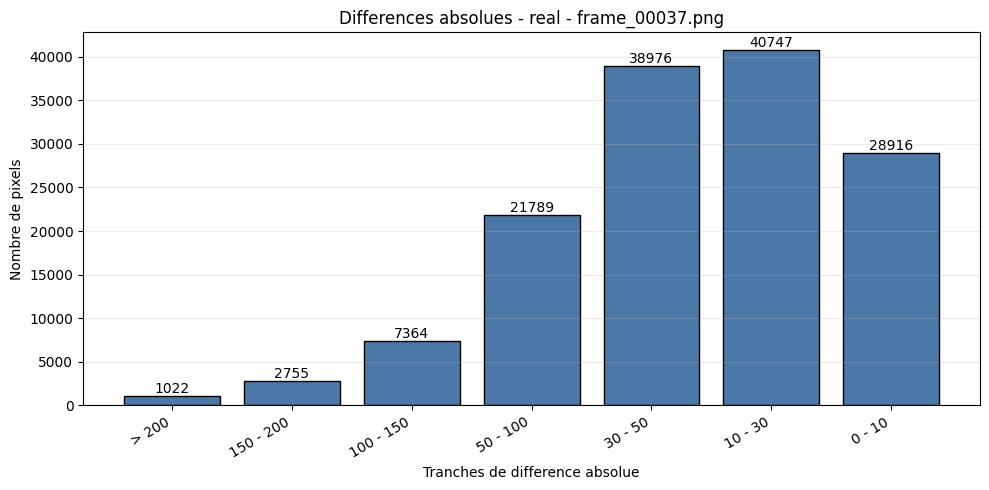

lvl:  4  initial error:  7901.472779369627
update too small, level converged! it:  6  error:  2233.7006003800293  lambda:  3602879701896397.0
lvl:  3  initial error:  2615.5185510609767
 error improvement too small, level converged! it:  4  error:  2541.596554935645  lambda:  3.2
lvl:  2  initial error:  2632.9658087283274
 error improvement too small, level converged! it:  4  error:  2616.8419725423623  lambda:  0.1
[real] frame 38 -> frame_00038.png | sum error = 417784736.00 | mean abs error = 38.2857 | valid pixels = 141476


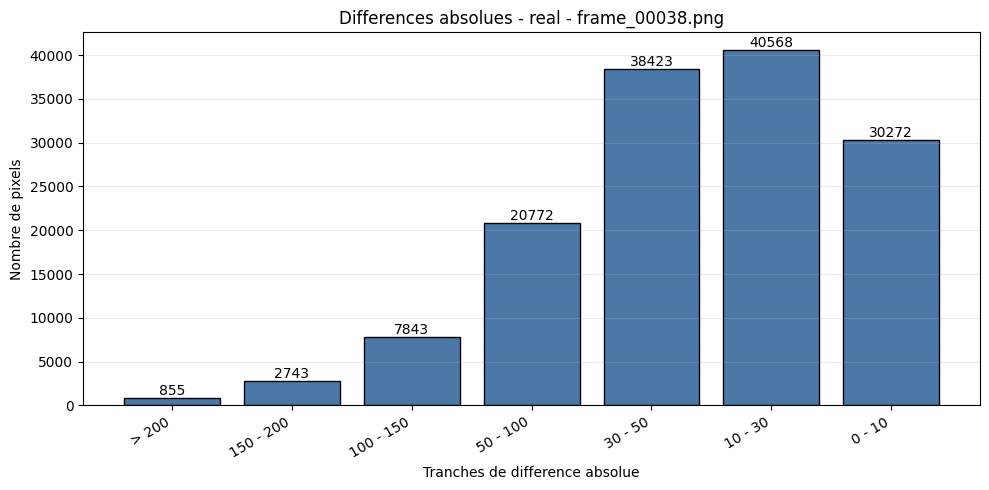

lvl:  4  initial error:  8041.735434574976
 error improvement too small, level converged! it:  3  error:  2408.085182150931  lambda:  225179981368524.8
lvl:  3  initial error:  2591.3615646279263
 error improvement too small, level converged! it:  8  error:  2497.6442045018434  lambda:  1.6
lvl:  2  initial error:  2588.190541253614
 error improvement too small, level converged! it:  2  error:  2581.6761298917804  lambda:  0.0
[real] frame 39 -> frame_00039.png | sum error = 409108768.00 | mean abs error = 38.0729 | valid pixels = 140593


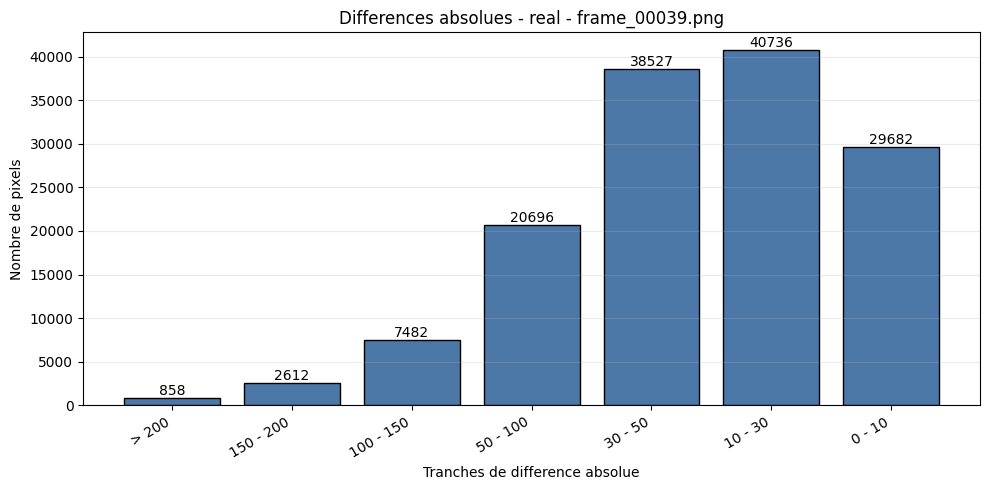

lvl:  4  initial error:  7804.808022922635
 error improvement too small, level converged! it:  3  error:  2377.511838318375  lambda:  7036874417766.4
lvl:  3  initial error:  2584.6374227767315
 error improvement too small, level converged! it:  5  error:  2454.2267757972745  lambda:  102.4
lvl:  2  initial error:  2594.009369418593
 error improvement too small, level converged! it:  1  error:  2591.9061657567854  lambda:  0.0
[real] frame 40 -> frame_00040.png | sum error = 415324096.00 | mean abs error = 38.1497 | valid pixels = 143921


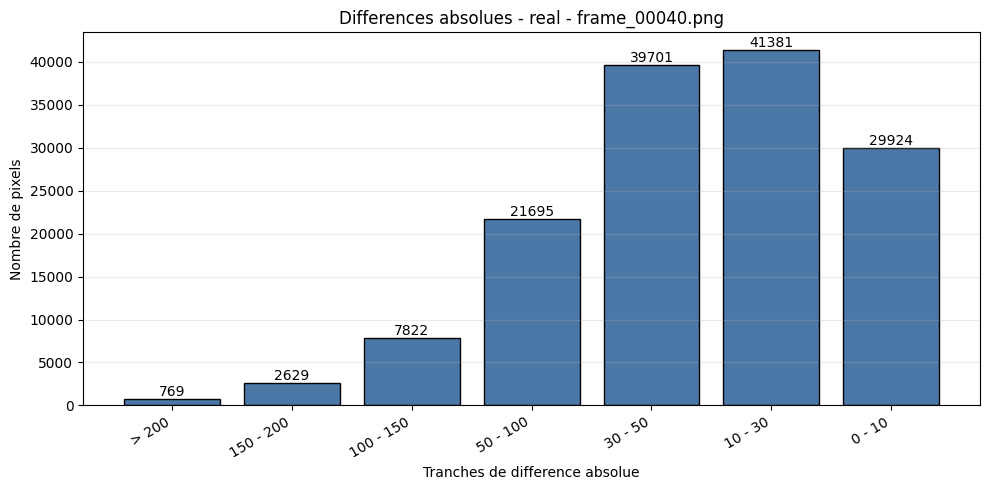

lvl:  4  initial error:  7612.212034383954
 error improvement too small, level converged! it:  6  error:  2242.905616275835  lambda:  879609302220.8
lvl:  3  initial error:  2516.9428972914225
 error improvement too small, level converged! it:  5  error:  2430.5569898170834  lambda:  0.1
lvl:  2  initial error:  2588.26181774549
 error improvement too small, level converged! it:  4  error:  2571.535174054527  lambda:  3518437208883.2
[real] frame 41 -> frame_00041.png | sum error = 419293824.00 | mean abs error = 38.0463 | valid pixels = 146346


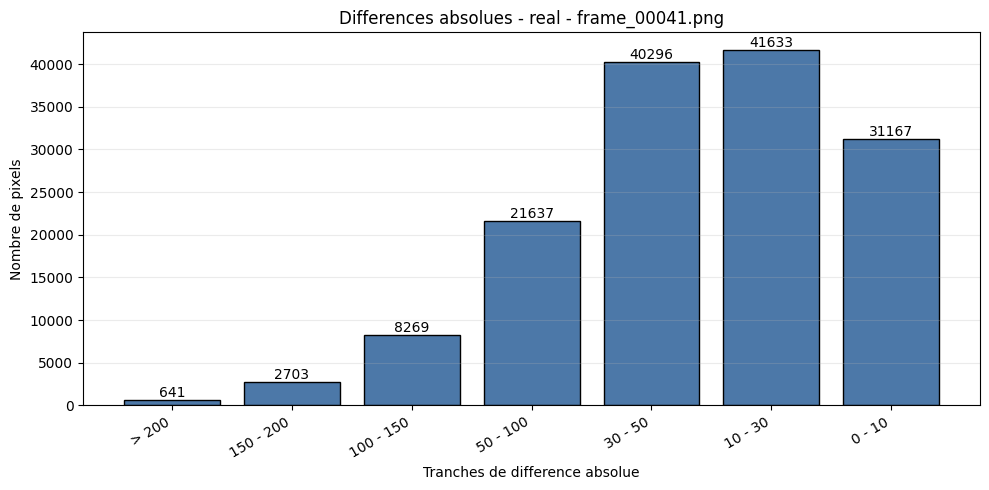

lvl:  4  initial error:  7494.5950334288445
 error improvement too small, level converged! it:  7  error:  1974.7232486011944  lambda:  3.2
lvl:  3  initial error:  2478.4170278582615
 error improvement too small, level converged! it:  3  error:  2345.862634950922  lambda:  0.8
lvl:  2  initial error:  2512.8347067953437
 error improvement too small, level converged! it:  1  error:  2511.9289865651667  lambda:  0.0
[real] frame 42 -> frame_00042.png | sum error = 420033472.00 | mean abs error = 37.2815 | valid pixels = 148082


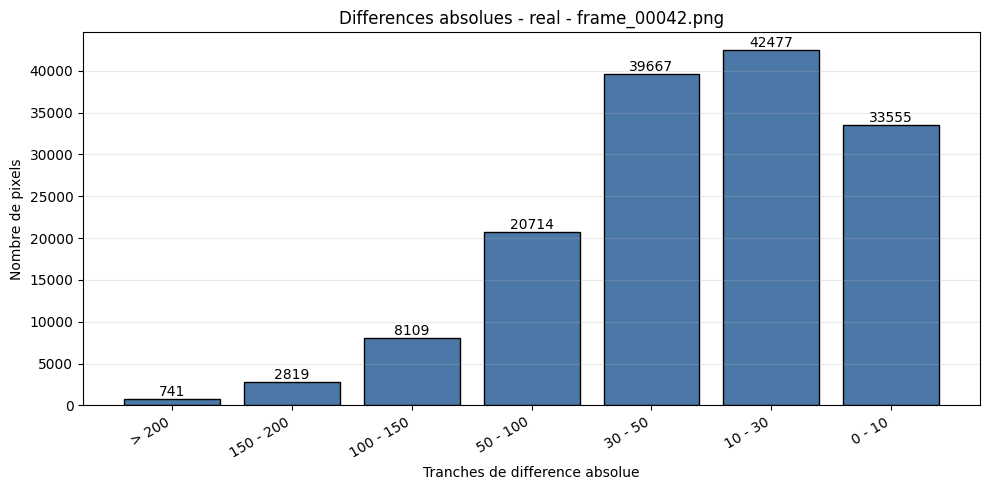

lvl:  4  initial error:  7435.976122254057
 error improvement too small, level converged! it:  4  error:  2030.78835522171  lambda:  1759218604441.6
lvl:  3  initial error:  2431.4998096746085
 error improvement too small, level converged! it:  3  error:  2362.5127078895976  lambda:  1638.4
lvl:  2  initial error:  2592.9612060624177
 error improvement too small, level converged! it:  6  error:  2545.421804400225  lambda:  0.1
[real] frame 43 -> frame_00043.png | sum error = 431295168.00 | mean abs error = 37.6711 | valid pixels = 149825


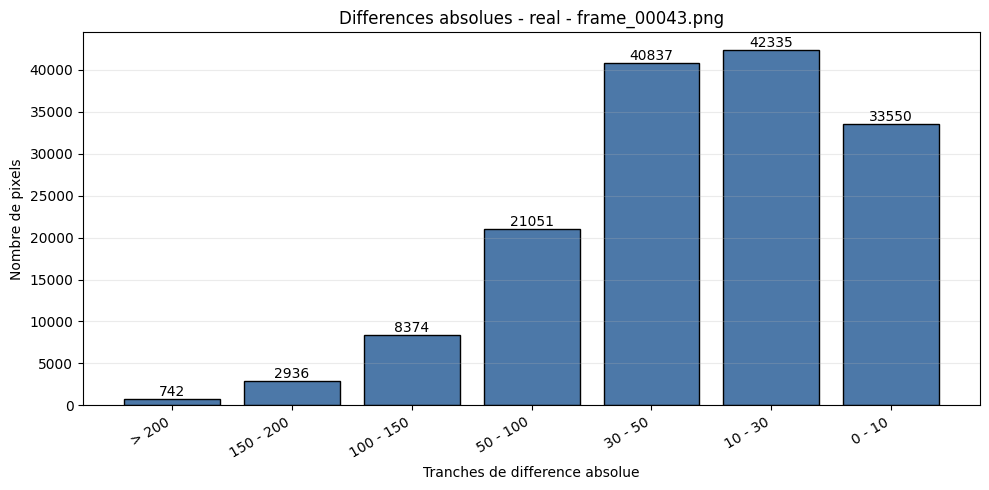

lvl:  4  initial error:  7513.941738299904
 error improvement too small, level converged! it:  7  error:  2141.7911101184322  lambda:  102.4
lvl:  3  initial error:  2637.4045357446594
 error improvement too small, level converged! it:  7  error:  2343.562446097884  lambda:  25.6
lvl:  2  initial error:  2720.7835297799083
 error improvement too small, level converged! it:  1  error:  2718.4207307787915  lambda:  3.2
[real] frame 44 -> frame_00044.png | sum error = 466593600.00 | mean abs error = 38.6721 | valid pixels = 151629


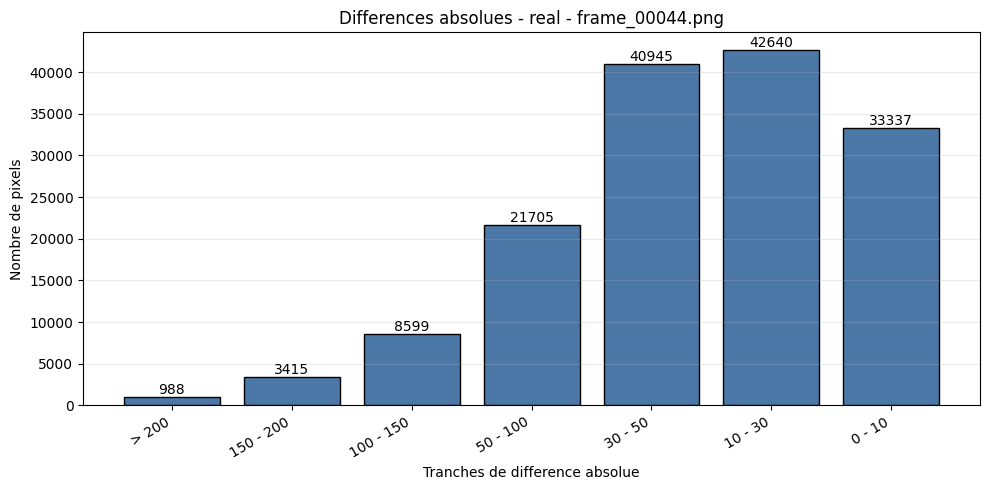

lvl:  4  initial error:  7166.24546322827
 error improvement too small, level converged! it:  4  error:  2374.7544636867888  lambda:  28147497671065.6
lvl:  3  initial error:  2793.693047093833
 error improvement too small, level converged! it:  5  error:  2508.6649833669308  lambda:  102.4
lvl:  2  initial error:  2774.3384860417946
 error improvement too small, level converged! it:  1  error:  2773.957992894292  lambda:  6.4
[real] frame 45 -> frame_00045.png | sum error = 497572032.00 | mean abs error = 38.7475 | valid pixels = 156562


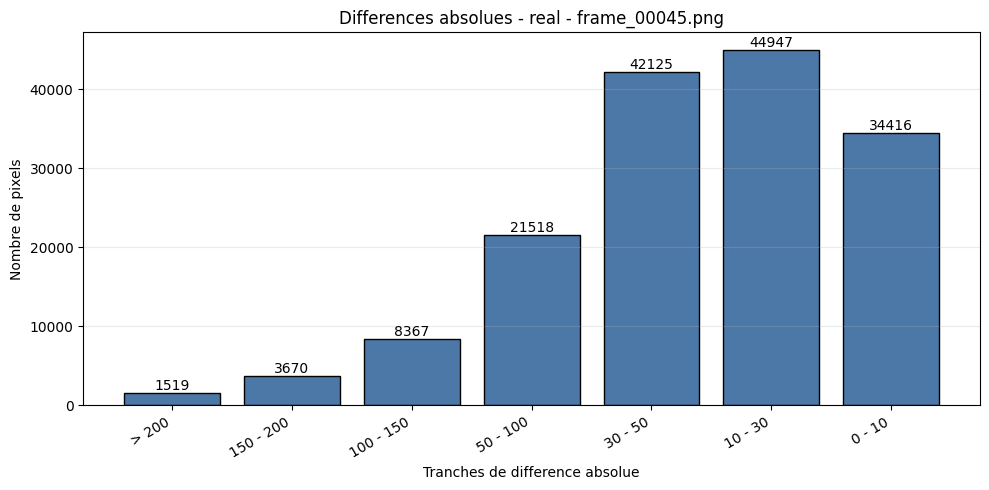

lvl:  4  initial error:  7159.893982808021
 error improvement too small, level converged! it:  4  error:  2411.2770787788454  lambda:  0.8
lvl:  3  initial error:  2894.654309823446
 error improvement too small, level converged! it:  6  error:  2757.4655793880115  lambda:  204.8
lvl:  2  initial error:  3065.4831855337857
 error improvement too small, level converged! it:  5  error:  3034.8846603796924  lambda:  0.0
[real] frame 46 -> frame_00046.png | sum error = 569395776.00 | mean abs error = 40.1643 | valid pixels = 164367


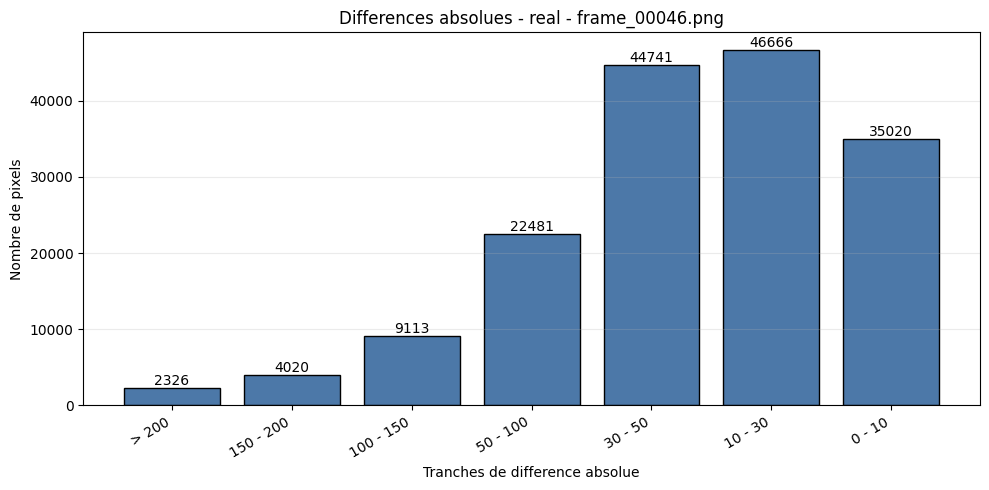

lvl:  4  initial error:  7185.776504297993
 error improvement too small, level converged! it:  4  error:  2686.893349409903  lambda:  28147497671065.6
lvl:  3  initial error:  2828.412244204725
 error improvement too small, level converged! it:  2  error:  2783.714768904314  lambda:  51.2
lvl:  2  initial error:  3041.187175540353
 error improvement too small, level converged! it:  4  error:  2989.9115082014805  lambda:  12.8
[real] frame 47 -> frame_00047.png | sum error = 563037824.00 | mean abs error = 39.6390 | valid pixels = 166625


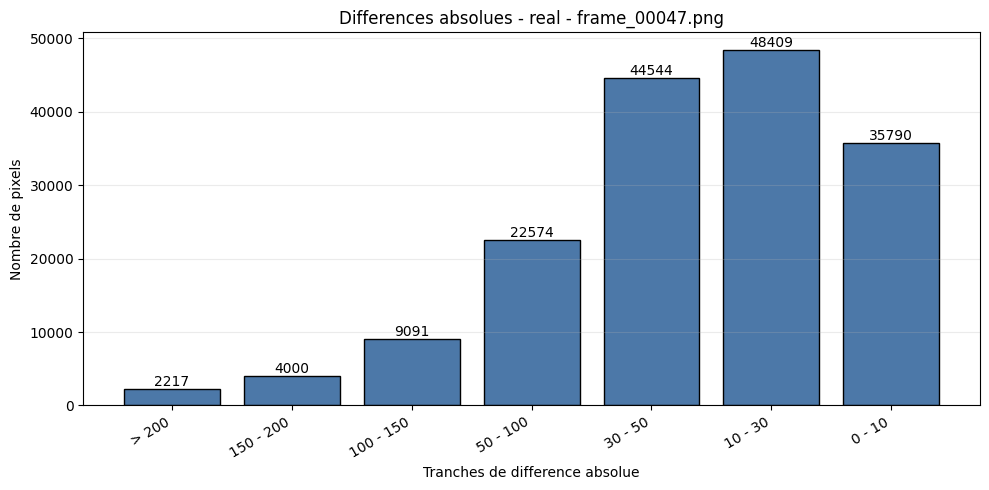

lvl:  4  initial error:  7296.903533906398
 error improvement too small, level converged! it:  5  error:  2548.031638559515  lambda:  12.8
lvl:  3  initial error:  3171.643479131013
 error improvement too small, level converged! it:  3  error:  3085.69016063428  lambda:  51.2
lvl:  2  initial error:  3368.839684603405
 error improvement too small, level converged! it:  20  error:  3103.565693088224  lambda:  0.0
[real] frame 48 -> frame_00048.png | sum error = 613452544.00 | mean abs error = 39.9748 | valid pixels = 175754


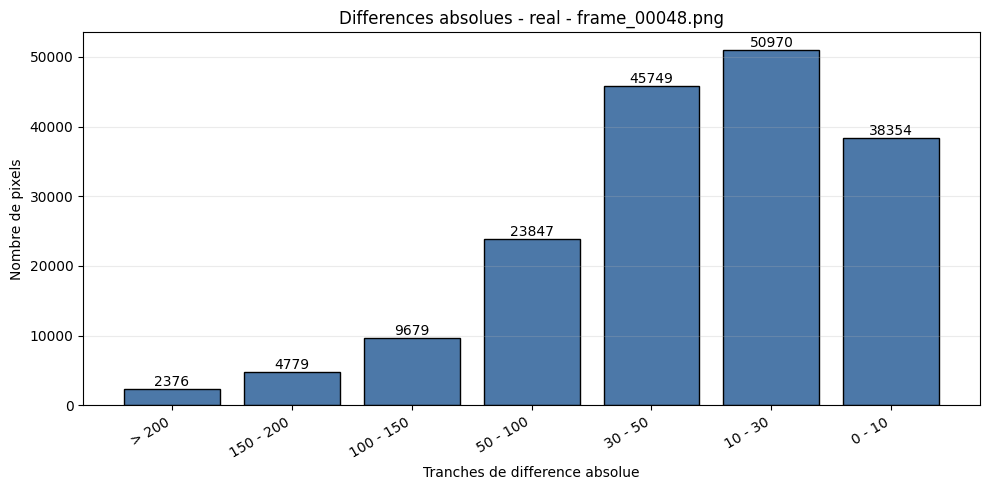

lvl:  4  initial error:  7273.015281757401
 error improvement too small, level converged! it:  5  error:  2606.7775027460298  lambda:  1.6
lvl:  3  initial error:  3345.3130627290357
 error improvement too small, level converged! it:  2  error:  3164.7930124492295  lambda:  0.0
lvl:  2  initial error:  3504.0542962526465
 error improvement too small, level converged! it:  4  error:  3420.6140297967345  lambda:  0.4
[real] frame 49 -> frame_00049.png | sum error = 722169344.00 | mean abs error = 41.9425 | valid pixels = 185983


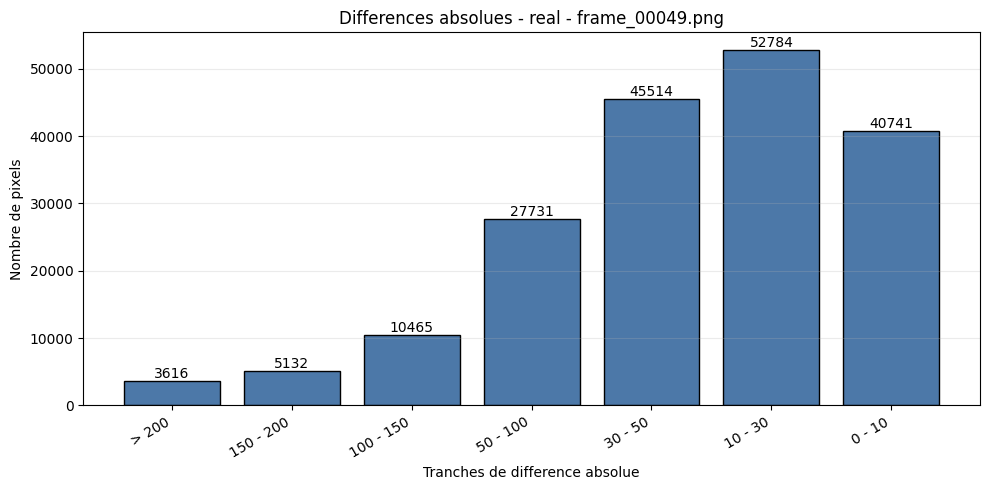

lvl:  4  initial error:  7225.884431709645
 error improvement too small, level converged! it:  3  error:  2468.489133968111  lambda:  204.8
lvl:  3  initial error:  3101.622892853443
 error improvement too small, level converged! it:  4  error:  3026.654164401248  lambda:  12.8
lvl:  2  initial error:  3365.1088299999465
 error improvement too small, level converged! it:  4  error:  3286.5997645838297  lambda:  25.6
[real] frame 50 -> frame_00050.png | sum error = 699804864.00 | mean abs error = 41.0807 | valid pixels = 188663


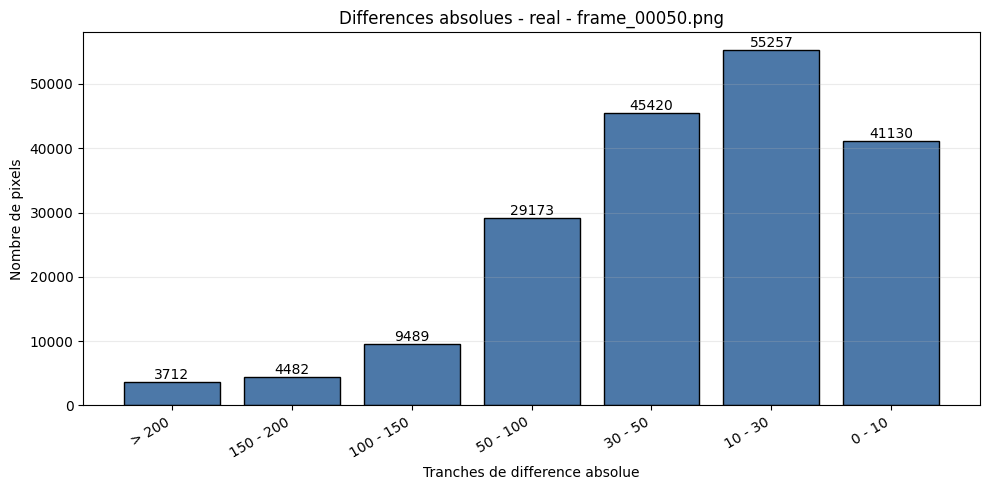

lvl:  4  initial error:  7015.287488061125
 error improvement too small, level converged! it:  2  error:  2514.851752430187  lambda:  0.0
lvl:  3  initial error:  3150.631601922135
 error improvement too small, level converged! it:  2  error:  2983.399873299399  lambda:  102.4
lvl:  2  initial error:  3388.819403758991
 error improvement too small, level converged! it:  4  error:  3104.6017404867757  lambda:  12.8
[real] frame 51 -> frame_00051.png | sum error = 689466112.00 | mean abs error = 41.0371 | valid pixels = 192974


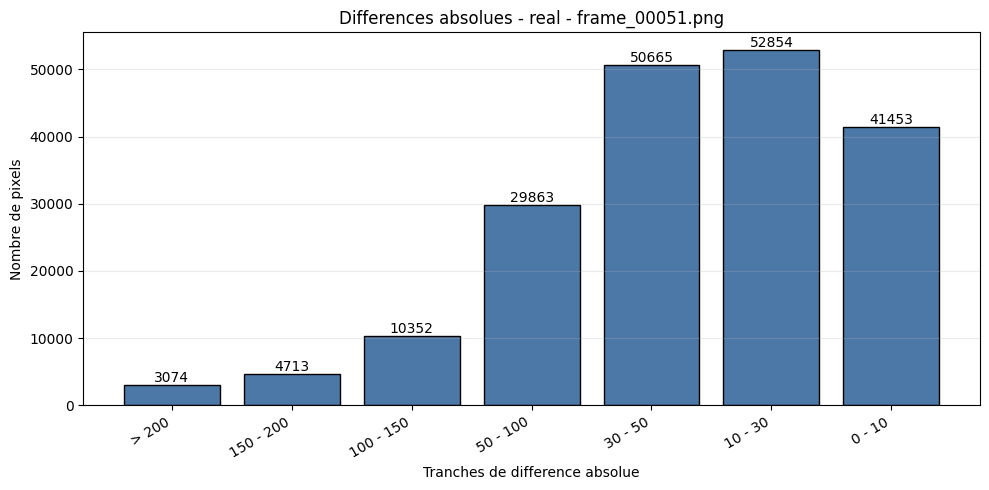

lvl:  4  initial error:  7359.820439350525
 error improvement too small, level converged! it:  4  error:  2447.838978407908  lambda:  3518437208883.2
lvl:  3  initial error:  3132.6899869726103
 error improvement too small, level converged! it:  2  error:  2927.0750019345937  lambda:  409.6
lvl:  2  initial error:  3230.9325737019667
 error improvement too small, level converged! it:  3  error:  3128.1451694391117  lambda:  25.6
[real] frame 52 -> frame_00052.png | sum error = 693103936.00 | mean abs error = 41.1492 | valid pixels = 196460


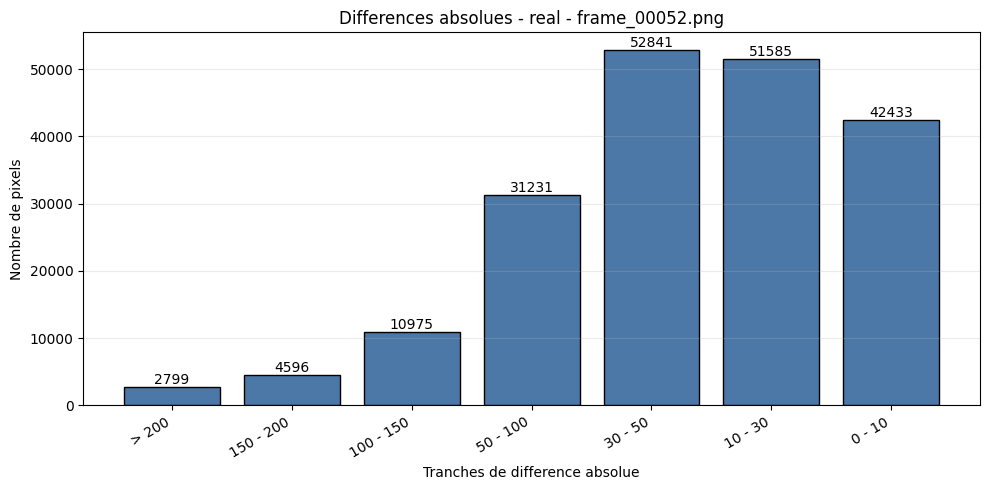

lvl:  4  initial error:  7596.340019102195
 error improvement too small, level converged! it:  4  error:  2284.6599064942775  lambda:  0.0
lvl:  3  initial error:  3150.665509169052
update too small, level converged! it:  5  error:  2801.1791087333413  lambda:  7205759403792794.0
lvl:  2  initial error:  3079.4418059764903
 error improvement too small, level converged! it:  4  error:  3030.293226404348  lambda:  0.0
[real] frame 53 -> frame_00053.png | sum error = 678560576.00 | mean abs error = 40.4308 | valid pixels = 199451


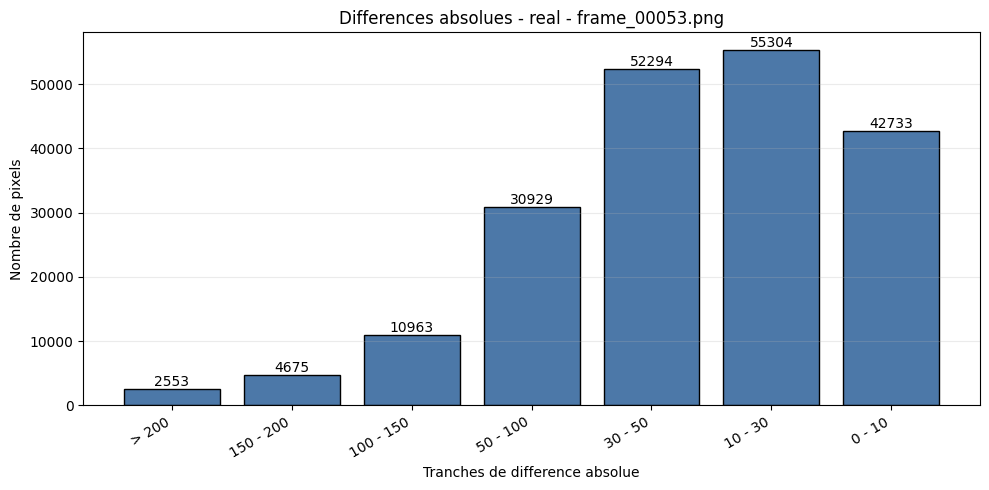

lvl:  4  initial error:  7803.015281757402
 error improvement too small, level converged! it:  4  error:  2499.9406075391976  lambda:  1759218604441.6
lvl:  3  initial error:  2803.818753193022
 error improvement too small, level converged! it:  5  error:  2667.0437840517884  lambda:  0.0
lvl:  2  initial error:  2818.813593419973
 error improvement too small, level converged! it:  4  error:  2805.3107633772975  lambda:  0.0
[real] frame 54 -> frame_00054.png | sum error = 638221568.00 | mean abs error = 39.6104 | valid pixels = 202267


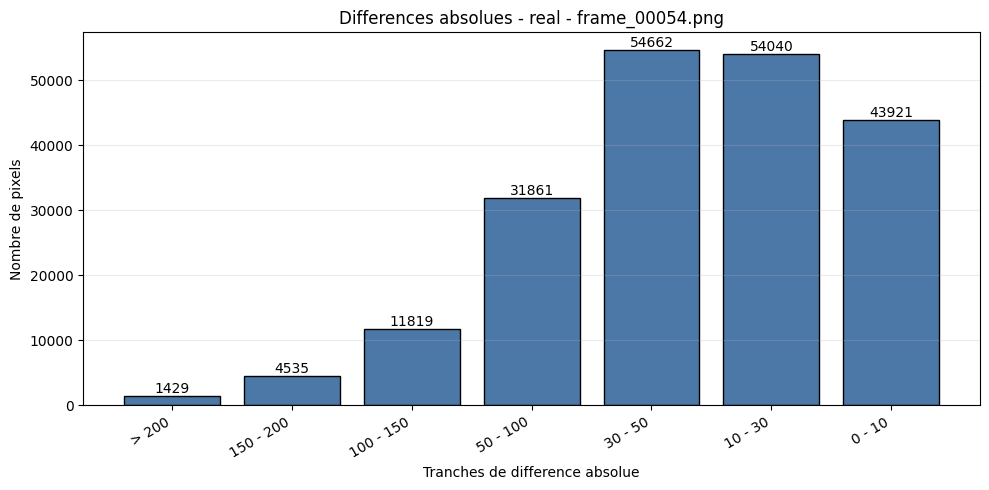

lvl:  4  initial error:  7749.85864374403
 error improvement too small, level converged! it:  6  error:  2328.567775764975  lambda:  3518437208883.2
lvl:  3  initial error:  2532.9540918454036
 error improvement too small, level converged! it:  3  error:  2448.409514493442  lambda:  439804651110.4
lvl:  2  initial error:  2557.683747606163
 error improvement too small, level converged! it:  2  error:  2551.051436860739  lambda:  0.0
[real] frame 55 -> frame_00055.png | sum error = 577725824.00 | mean abs error = 37.3992 | valid pixels = 204433


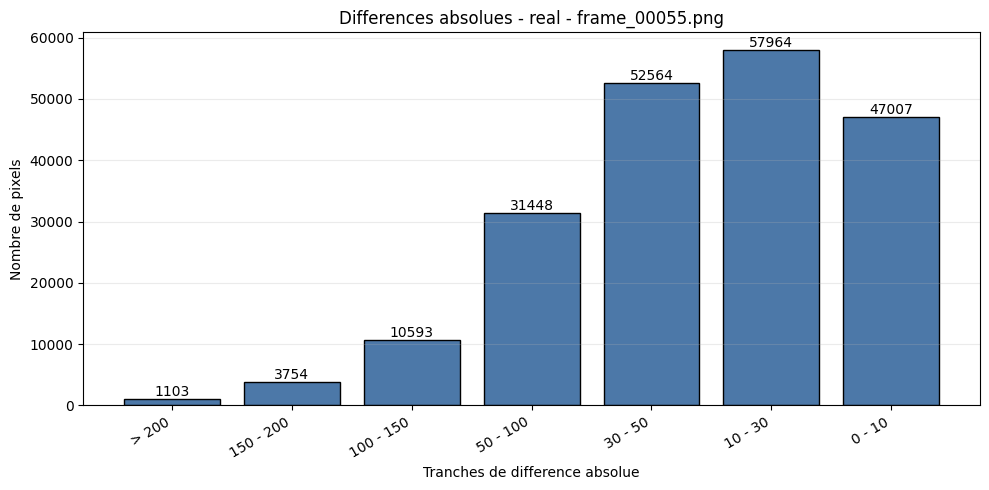

lvl:  4  initial error:  7849.481375358165
 error improvement too small, level converged! it:  6  error:  2107.233866409124  lambda:  0.1
lvl:  3  initial error:  2386.0917007934213
 error improvement too small, level converged! it:  5  error:  2159.643914928244  lambda:  0.0
lvl:  2  initial error:  2336.802505885599
 error improvement too small, level converged! it:  2  error:  2332.814002150964  lambda:  0.0
[real] frame 56 -> frame_00056.png | sum error = 551549184.00 | mean abs error = 35.7862 | valid pixels = 209184


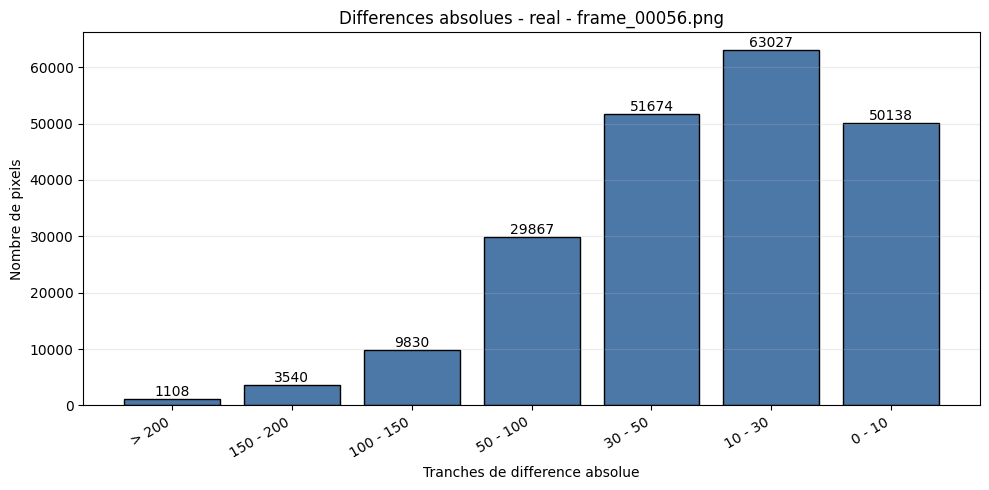

lvl:  4  initial error:  8192.109837631326
 error improvement too small, level converged! it:  6  error:  1451.2868791170488  lambda:  0.1
lvl:  3  initial error:  1830.8261154496265
 error improvement too small, level converged! it:  4  error:  1605.5077833018338  lambda:  0.0
lvl:  2  initial error:  1792.3589435089475
 error improvement too small, level converged! it:  1  error:  1792.320130480037  lambda:  51.2
[real] frame 57 -> frame_00057.png | sum error = 471969472.00 | mean abs error = 27.6577 | valid pixels = 214098


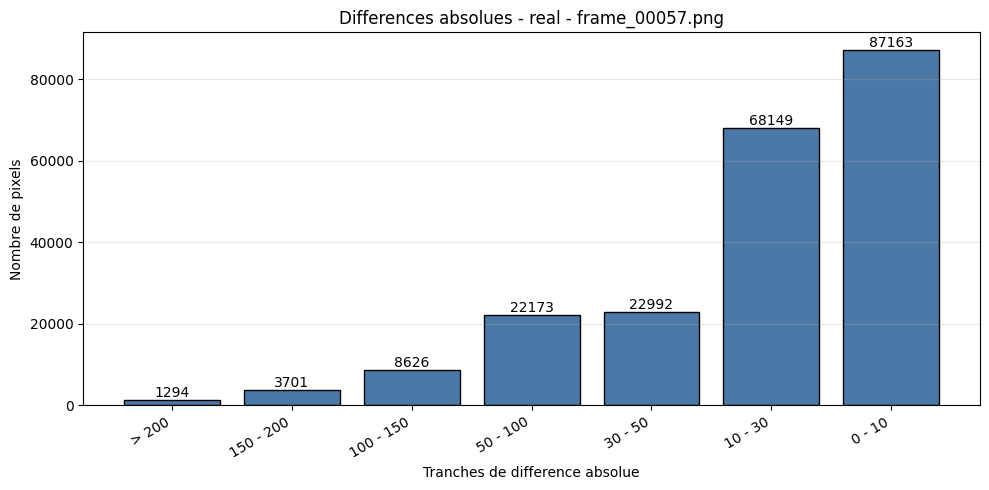

lvl:  4  initial error:  7705.698185291308
 error improvement too small, level converged! it:  4  error:  1699.0705072951735  lambda:  6.4
lvl:  3  initial error:  1809.2280468778497
 error improvement too small, level converged! it:  4  error:  1711.5207069432681  lambda:  0.0
lvl:  2  initial error:  1809.771739890798
 error improvement too small, level converged! it:  8  error:  1776.5122095560012  lambda:  0.0
[real] frame 58 -> frame_00058.png | sum error = 459513280.00 | mean abs error = 29.7155 | valid pixels = 217733


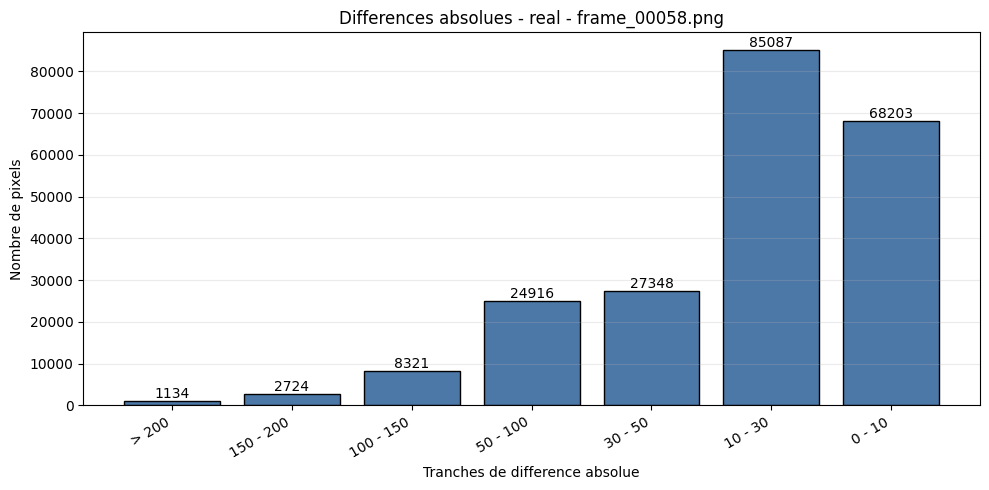

lvl:  4  initial error:  7322.789875835721
 error improvement too small, level converged! it:  6  error:  1615.5945036774021  lambda:  12.8
lvl:  3  initial error:  1780.560512231379
 error improvement too small, level converged! it:  5  error:  1583.1991449376462  lambda:  7036874417766.4
lvl:  2  initial error:  1708.1930415962947
 error improvement too small, level converged! it:  6  error:  1660.6159694995492  lambda:  0.0
[real] frame 59 -> frame_00059.png | sum error = 446619712.00 | mean abs error = 28.9624 | valid pixels = 222187


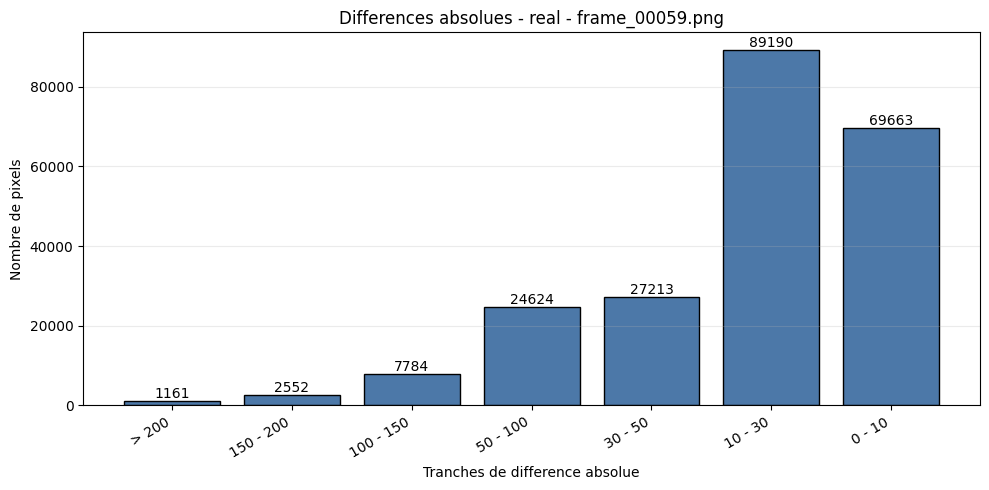

lvl:  4  initial error:  7083.127029608404
 error improvement too small, level converged! it:  3  error:  1421.1462240049257  lambda:  0.0
lvl:  3  initial error:  1691.5671686382425
 error improvement too small, level converged! it:  3  error:  1436.9153627650812  lambda:  0.0
lvl:  2  initial error:  1595.924032375023
 error improvement too small, level converged! it:  6  error:  1543.7186221046006  lambda:  0.0
[real] frame 60 -> frame_00060.png | sum error = 430639296.00 | mean abs error = 28.2180 | valid pixels = 225324


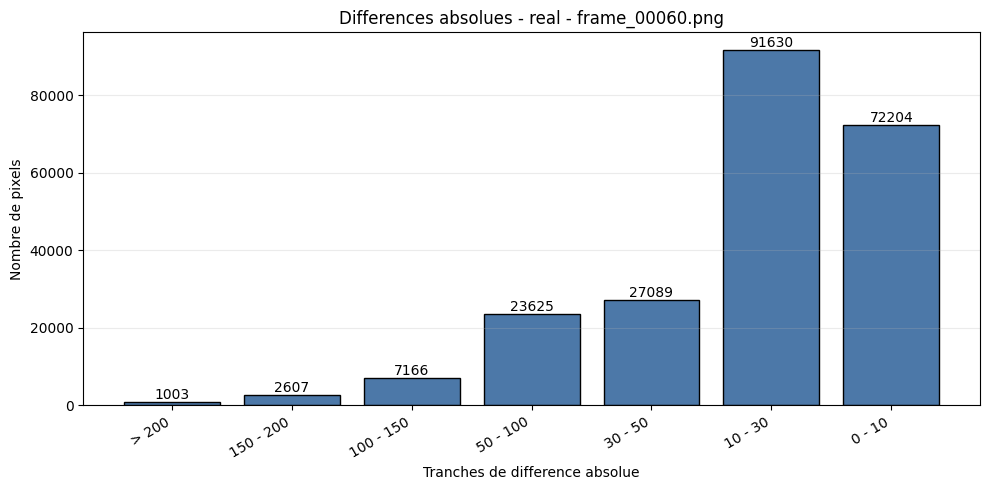

lvl:  4  initial error:  6904.993314231135
 error improvement too small, level converged! it:  3  error:  1379.0911029305  lambda:  25.6
lvl:  3  initial error:  1389.473412321793
 error improvement too small, level converged! it:  3  error:  1333.5950977018033  lambda:  0.1
lvl:  2  initial error:  1422.379234764324
 error improvement too small, level converged! it:  3  error:  1385.7639064800164  lambda:  0.0
[real] frame 61 -> frame_00061.png | sum error = 391461056.00 | mean abs error = 26.8777 | valid pixels = 228078


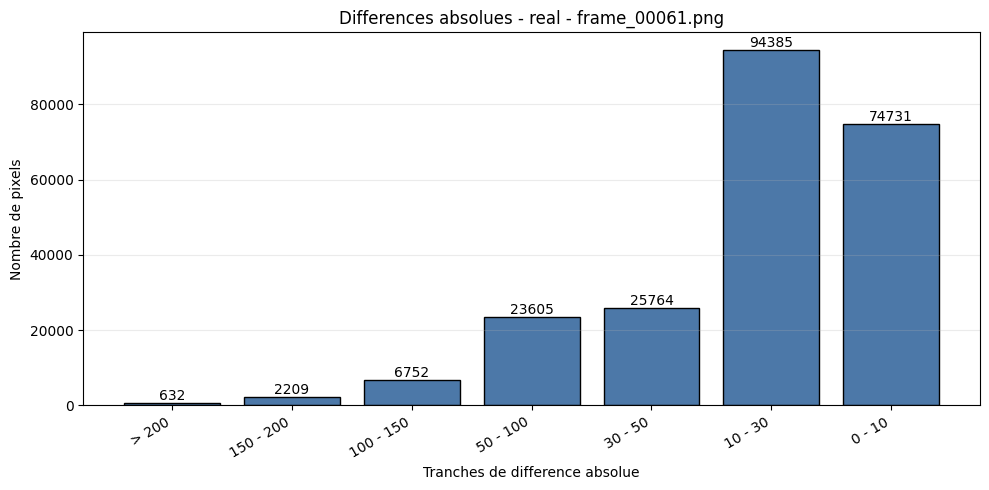

lvl:  4  initial error:  6417.439350525308
 error improvement too small, level converged! it:  7  error:  1338.3702203664734  lambda:  7036874417766.4
lvl:  3  initial error:  1494.0775710788107
 error improvement too small, level converged! it:  4  error:  1344.035990839977  lambda:  6.4
lvl:  2  initial error:  1388.5353497904657
 error improvement too small, level converged! it:  7  error:  1318.3109899165393  lambda:  0.0
[real] frame 62 -> frame_00062.png | sum error = 367697536.00 | mean abs error = 26.3412 | valid pixels = 230712


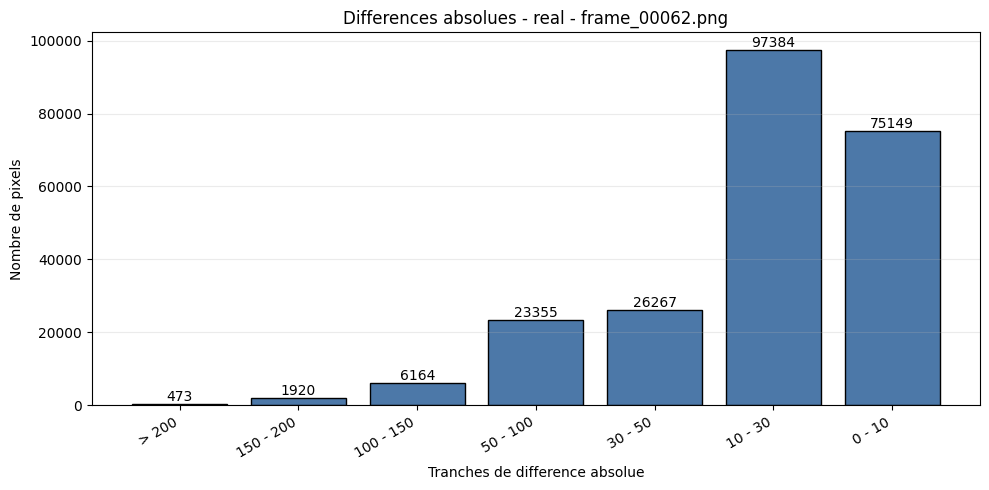

lvl:  4  initial error:  6177.591212989492
 error improvement too small, level converged! it:  5  error:  1175.8678844512608  lambda:  7036874417766.4
lvl:  3  initial error:  1249.22039610576
 error improvement too small, level converged! it:  2  error:  1167.712150623808  lambda:  51.2
lvl:  2  initial error:  1217.3946372429953
 error improvement too small, level converged! it:  4  error:  1159.8687566784786  lambda:  0.0
[real] frame 63 -> frame_00063.png | sum error = 333554528.00 | mean abs error = 24.7230 | valid pixels = 232553


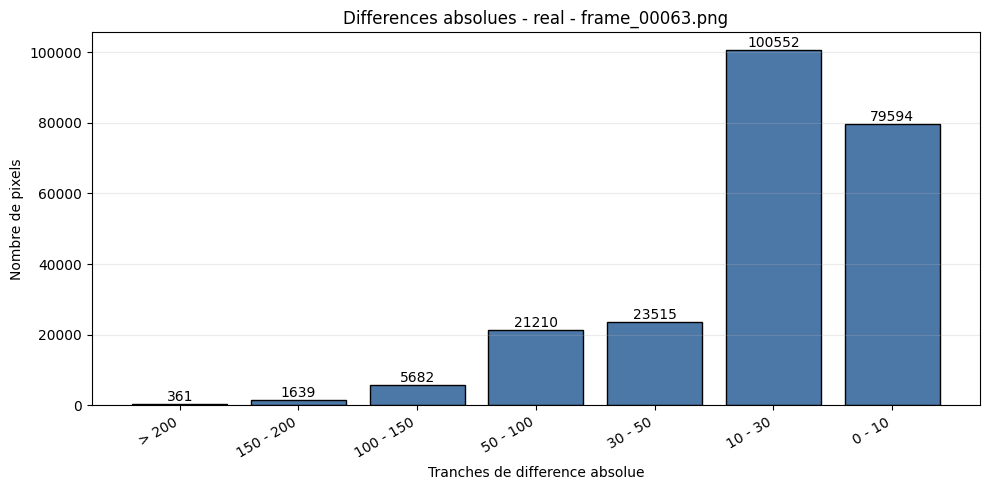

lvl:  4  initial error:  6005.969436485192
 error improvement too small, level converged! it:  6  error:  913.4737628049779  lambda:  14073748835532.8
lvl:  3  initial error:  1017.3951155354353
 error improvement too small, level converged! it:  2  error:  903.9384671147616  lambda:  0.0
lvl:  2  initial error:  923.555553130855
 error improvement too small, level converged! it:  3  error:  891.651063303703  lambda:  0.0
[real] frame 64 -> frame_00064.png | sum error = 281896896.00 | mean abs error = 17.5911 | valid pixels = 239598


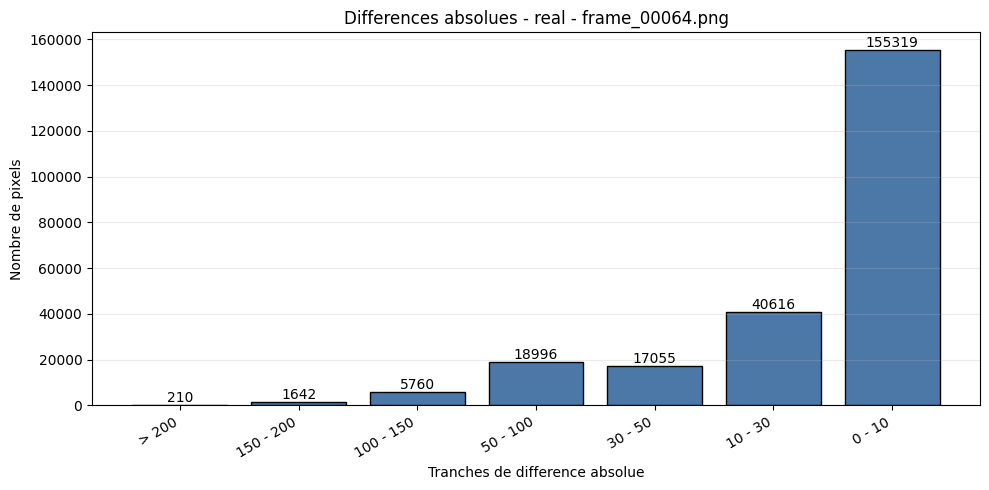

lvl:  4  initial error:  5295.621776504297
update too small, level converged! it:  5  error:  1101.5578385711337  lambda:  900719925474099.2
lvl:  3  initial error:  993.1428074460463
 error improvement too small, level converged! it:  4  error:  865.8429693612231  lambda:  0.1
lvl:  2  initial error:  931.4549966489545
 error improvement too small, level converged! it:  9  error:  859.7837428613676  lambda:  0.0
[real] frame 65 -> frame_00065.png | sum error = 280138912.00 | mean abs error = 18.2195 | valid pixels = 247288


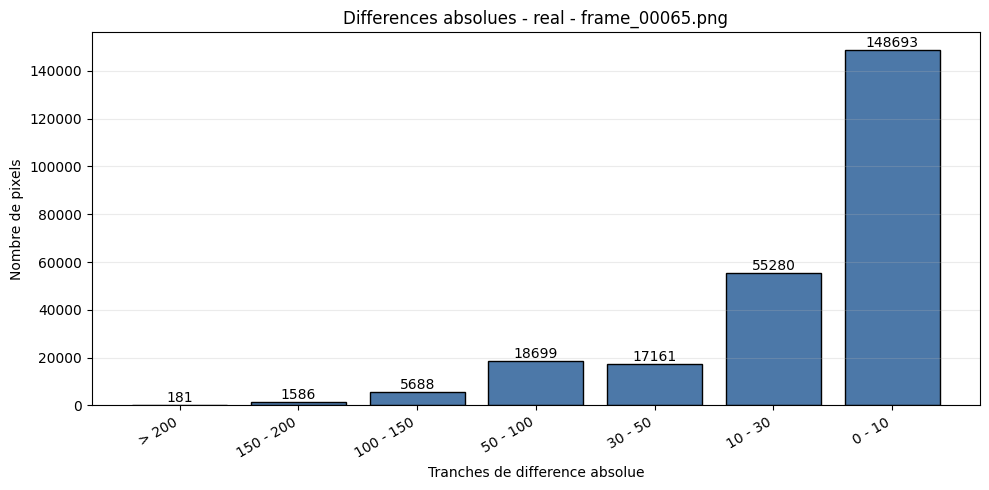

lvl:  4  initial error:  5071.734479465137
 error improvement too small, level converged! it:  6  error:  1169.5808689766784  lambda:  0.0
lvl:  3  initial error:  859.5623718599664
 error improvement too small, level converged! it:  3  error:  801.4271294063119  lambda:  0.0
lvl:  2  initial error:  786.8065513006957
 error improvement too small, level converged! it:  6  error:  739.3450326241974  lambda:  0.1
[real] frame 66 -> frame_00066.png | sum error = 258983392.00 | mean abs error = 16.8608 | valid pixels = 252196


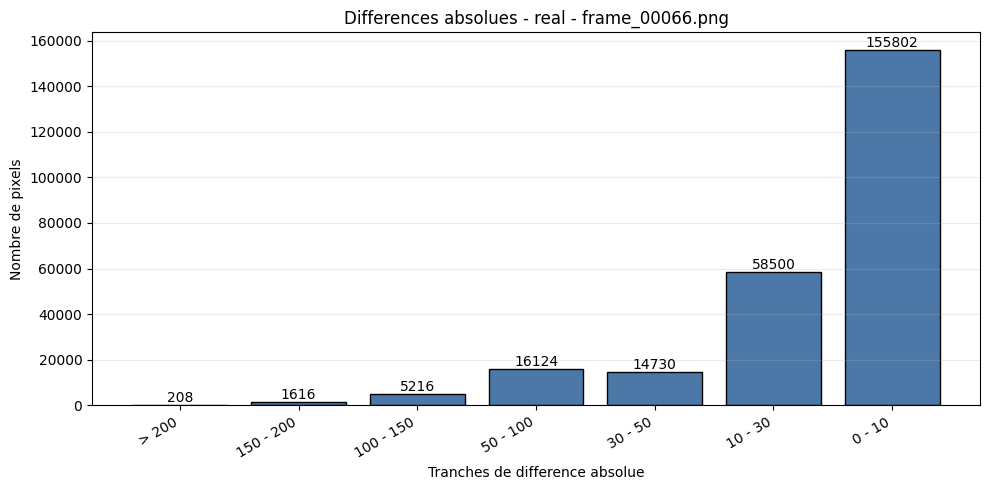

lvl:  4  initial error:  4852.516714422156
 error improvement too small, level converged! it:  5  error:  1189.9833507782294  lambda:  0.0
lvl:  3  initial error:  875.2694191670258
 error improvement too small, level converged! it:  2  error:  780.2882545814861  lambda:  879609302220.8
lvl:  2  initial error:  734.25841523703
 error improvement too small, level converged! it:  9  error:  672.1048940977576  lambda:  0.0
[real] frame 67 -> frame_00067.png | sum error = 235238160.00 | mean abs error = 15.3846 | valid pixels = 257189


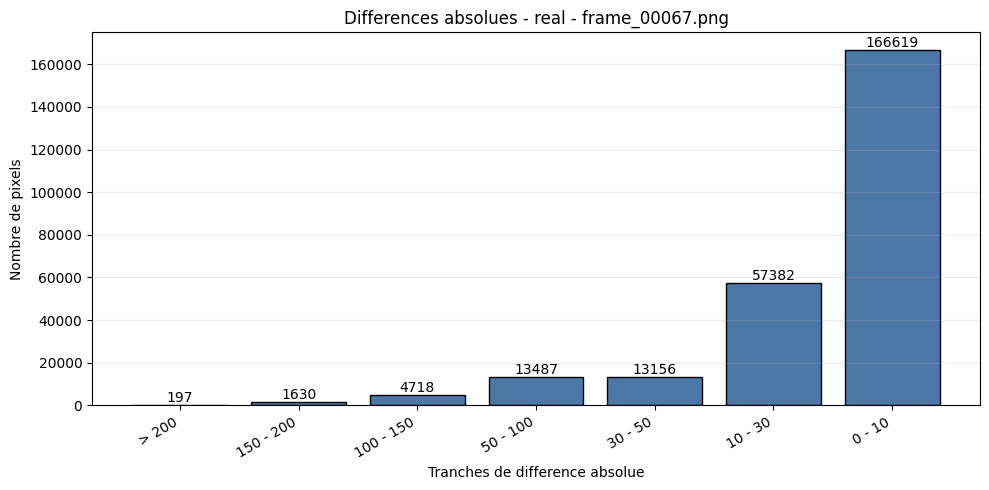

lvl:  4  initial error:  4834.520534861506
 error improvement too small, level converged! it:  7  error:  1117.3613107929857  lambda:  14073748835532.8
lvl:  3  initial error:  834.2788845939549
update too small, level converged! it:  3  error:  737.7464217596366  lambda:  900719925474099.2
lvl:  2  initial error:  590.2100554464987
 error improvement too small, level converged! it:  2  error:  578.8087281932168  lambda:  6871947673.6
[real] frame 68 -> frame_00068.png | sum error = 207168544.00 | mean abs error = 14.0931 | valid pixels = 266474


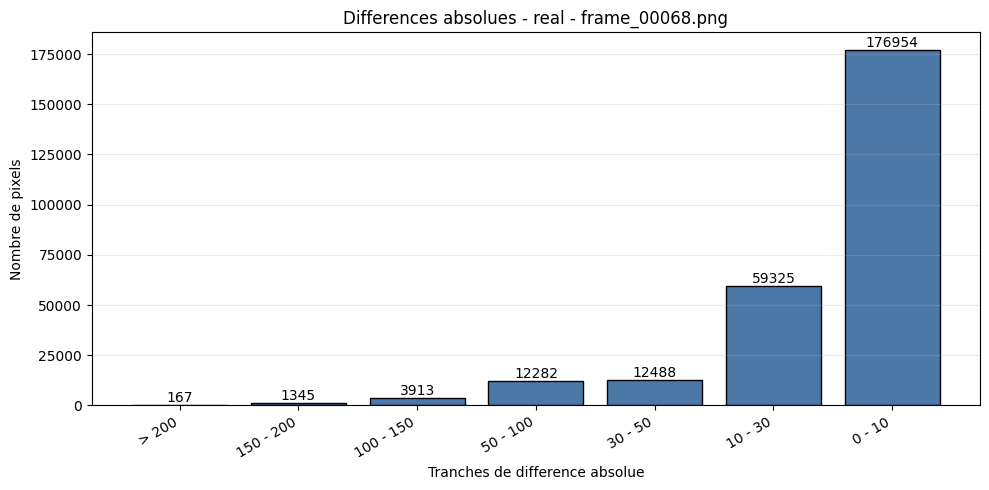

lvl:  4  initial error:  4991.875835721106
 error improvement too small, level converged! it:  3  error:  1173.7275156436062  lambda:  1759218604441.6
lvl:  3  initial error:  866.9026568924179
 error improvement too small, level converged! it:  4  error:  779.9419007530803  lambda:  25.6
lvl:  2  initial error:  562.7815581392816
update too small, level converged! it:  3  error:  531.9764539537075  lambda:  112589990684262.4
[real] frame 69 -> frame_00069.png | sum error = 197079120.00 | mean abs error = 13.7568 | valid pixels = 270170


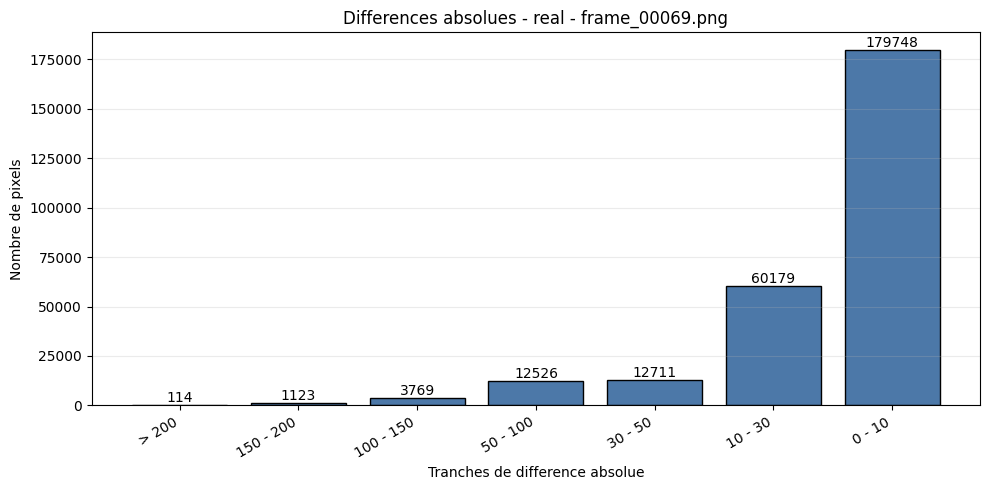

lvl:  4  initial error:  5276.872015281756
 error improvement too small, level converged! it:  5  error:  1260.9305754209358  lambda:  3.2
lvl:  3  initial error:  912.3623908438801
 error improvement too small, level converged! it:  6  error:  708.8332213091238  lambda:  1759218604441.6
lvl:  2  initial error:  583.0041303279966
 error improvement too small, level converged! it:  2  error:  575.491642931225  lambda:  0.0
[real] frame 70 -> frame_00070.png | sum error = 215467040.00 | mean abs error = 14.5429 | valid pixels = 273038


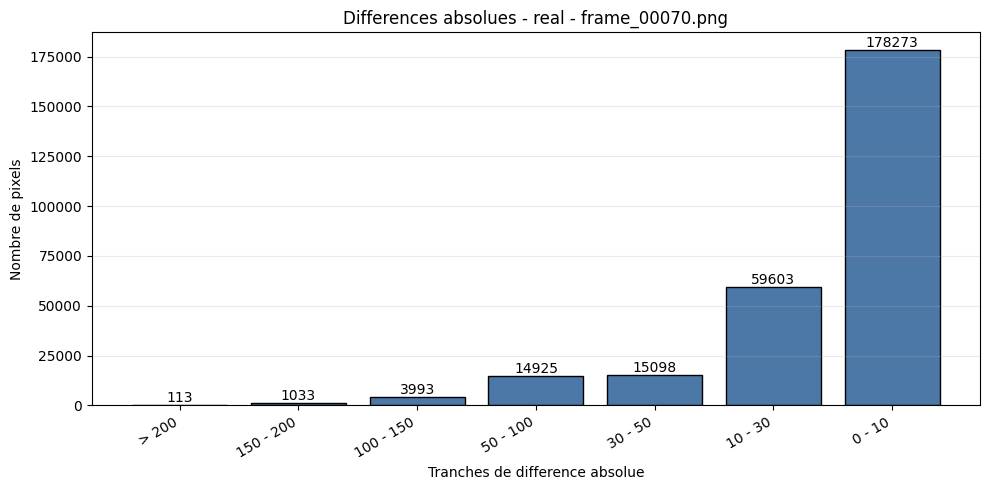

lvl:  4  initial error:  5468.449856733522
 error improvement too small, level converged! it:  5  error:  870.5641405216334  lambda:  879609302220.8
lvl:  3  initial error:  805.7604182149415
 error improvement too small, level converged! it:  3  error:  743.0334088967073  lambda:  0.8
lvl:  2  initial error:  600.5070831168852
 error improvement too small, level converged! it:  5  error:  584.6148721255482  lambda:  12.8
[real] frame 71 -> frame_00071.png | sum error = 216688736.00 | mean abs error = 14.8676 | valid pixels = 272722


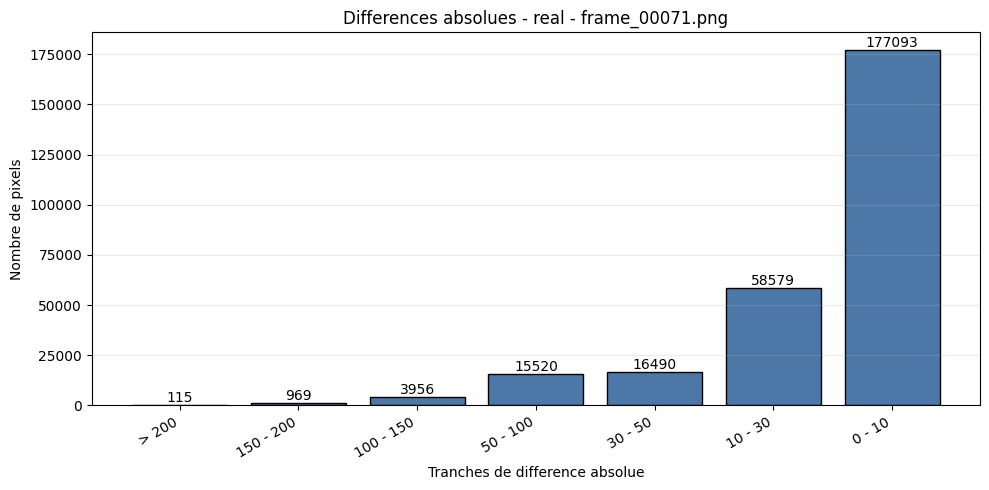

lvl:  4  initial error:  5496.929321872012
update too small, level converged! it:  6  error:  1173.5970541002253  lambda:  225179981368524.8
lvl:  3  initial error:  883.8237916675798
 error improvement too small, level converged! it:  4  error:  828.8242034597167  lambda:  0.0
lvl:  2  initial error:  662.5487610817404
 error improvement too small, level converged! it:  3  error:  655.4882121190802  lambda:  3.2
[real] frame 72 -> frame_00072.png | sum error = 232397648.00 | mean abs error = 15.6094 | valid pixels = 272256


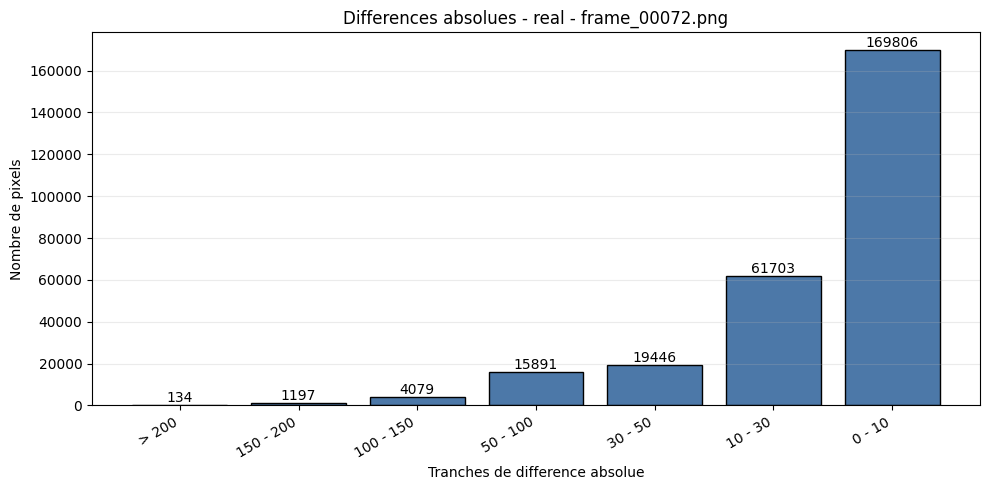

lvl:  4  initial error:  6296.063992359121
 error improvement too small, level converged! it:  4  error:  1171.6191150927982  lambda:  0.0
lvl:  3  initial error:  958.4901650936547
 error improvement too small, level converged! it:  3  error:  919.9809175166321  lambda:  6.4
lvl:  2  initial error:  854.9879521490659
 error improvement too small, level converged! it:  3  error:  845.6028533042314  lambda:  27487790694.4
[real] frame 73 -> frame_00073.png | sum error = 271094816.00 | mean abs error = 17.5537 | valid pixels = 268748


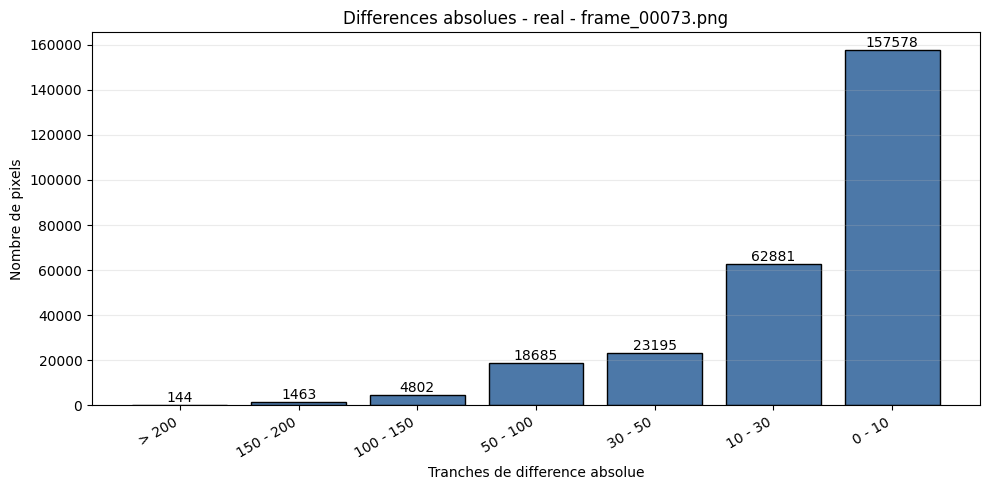

lvl:  4  initial error:  6949.988538681947
 error improvement too small, level converged! it:  5  error:  1078.3736043185695  lambda:  0.8
lvl:  3  initial error:  1091.465208831453
 error improvement too small, level converged! it:  4  error:  1084.359710341873  lambda:  0.0
lvl:  2  initial error:  1037.9180856667979
 error improvement too small, level converged! it:  3  error:  1011.1232981242325  lambda:  0.0
[real] frame 74 -> frame_00074.png | sum error = 321809600.00 | mean abs error = 18.7957 | valid pixels = 268658


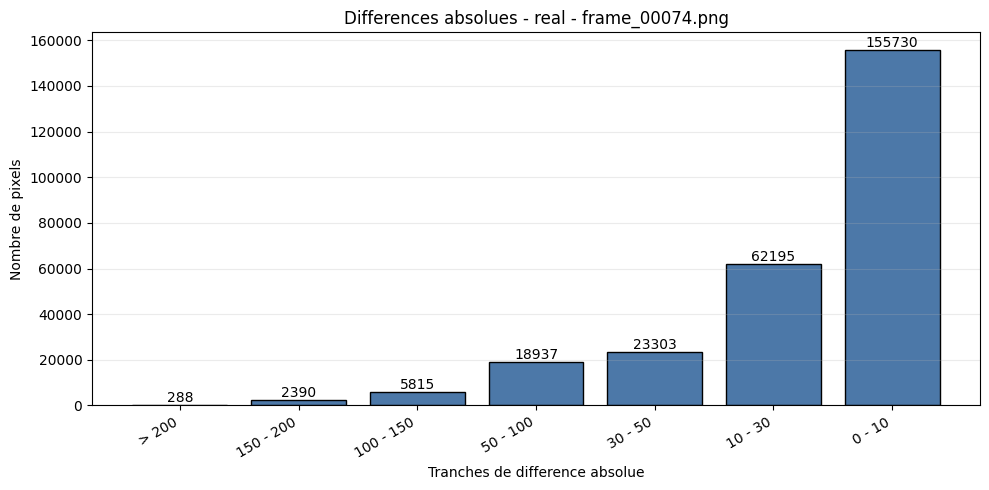

lvl:  4  initial error:  7916.775549188155
update too small, level converged! it:  5  error:  1607.6576264983992  lambda:  112589990684262.4
lvl:  3  initial error:  1489.3498507387
 error improvement too small, level converged! it:  4  error:  1433.0414448815238  lambda:  54975581388.8
lvl:  2  initial error:  1468.4446787546772
 error improvement too small, level converged! it:  5  error:  1434.5004751613747  lambda:  102.4
[real] frame 75 -> frame_00075.png | sum error = 439418688.00 | mean abs error = 22.6940 | valid pixels = 266880


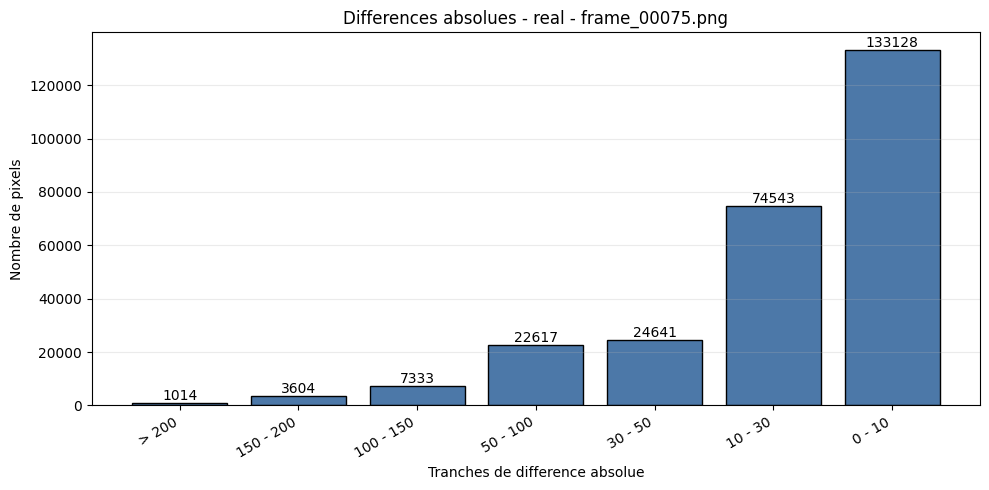

lvl:  4  initial error:  9525.803247373447
 error improvement too small, level converged! it:  7  error:  1957.7964300109518  lambda:  0.8
lvl:  3  initial error:  1911.895518780767
 error improvement too small, level converged! it:  5  error:  1847.972509614515  lambda:  0.1
lvl:  2  initial error:  1903.3150459182798
 error improvement too small, level converged! it:  3  error:  1886.5055062624126  lambda:  0.2
[real] frame 76 -> frame_00076.png | sum error = 548623808.00 | mean abs error = 27.5786 | valid pixels = 258556


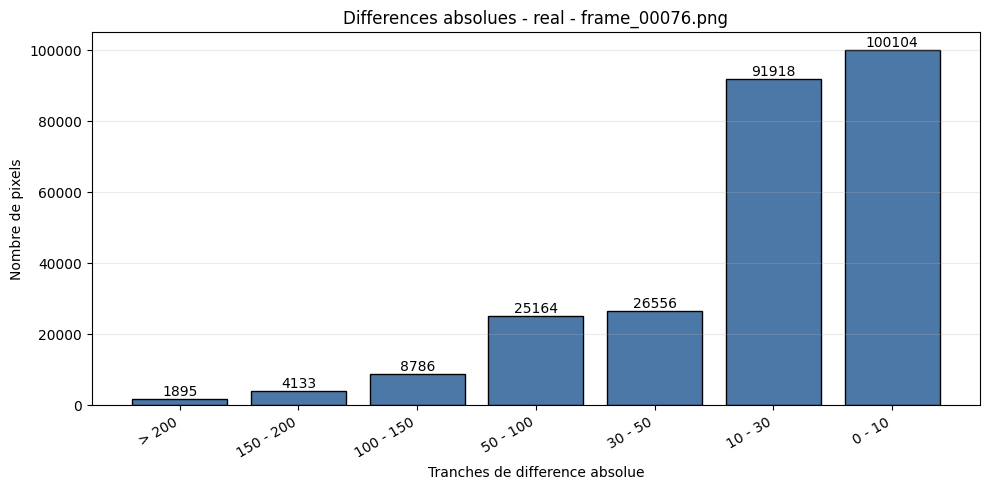

lvl:  4  initial error:  10786.418338108882
 error improvement too small, level converged! it:  6  error:  2418.8623464306675  lambda:  1.6
lvl:  3  initial error:  2184.881081523684
 error improvement too small, level converged! it:  4  error:  2145.669184802173  lambda:  0.8
lvl:  2  initial error:  2257.4703341919962
 error improvement too small, level converged! it:  4  error:  2213.0491215105685  lambda:  0.0
[real] frame 77 -> frame_00077.png | sum error = 609133312.00 | mean abs error = 30.2799 | valid pixels = 247560


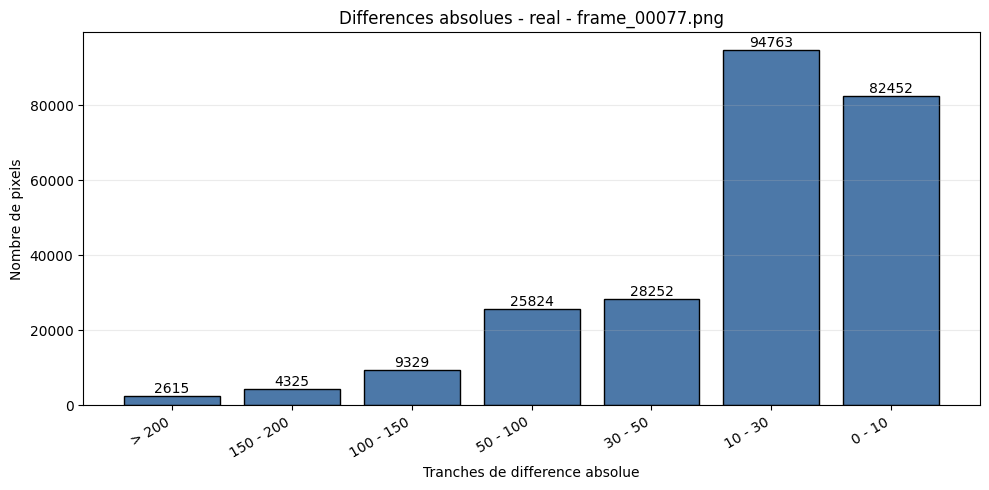

lvl:  4  initial error:  11975.112702960836
 error improvement too small, level converged! it:  5  error:  2651.376203827347  lambda:  204.8
lvl:  3  initial error:  2482.766645844318
 error improvement too small, level converged! it:  3  error:  2402.233407675994  lambda:  879609302220.8
lvl:  2  initial error:  2614.9074974209893
 error improvement too small, level converged! it:  3  error:  2604.6230591204226  lambda:  0.0
[real] frame 78 -> frame_00078.png | sum error = 680703488.00 | mean abs error = 33.9626 | valid pixels = 236589


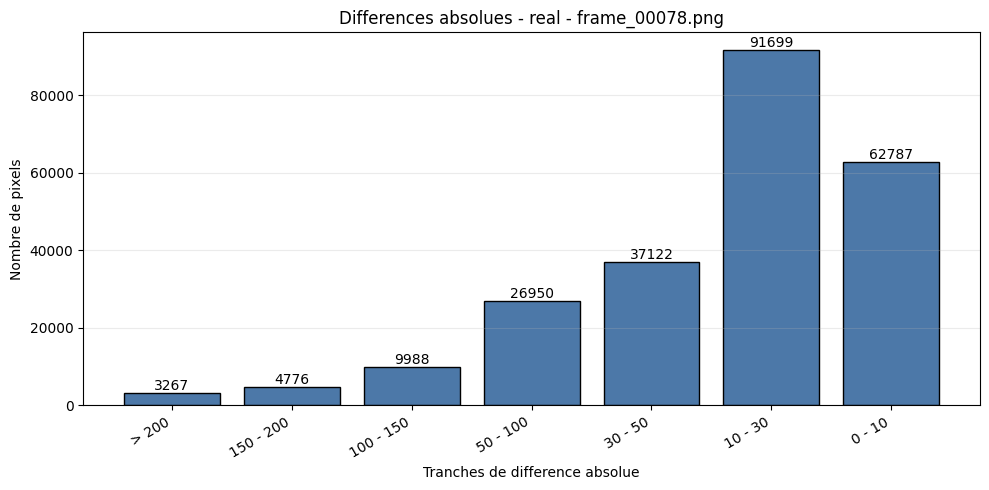

lvl:  4  initial error:  11868.424068767907
 error improvement too small, level converged! it:  7  error:  2696.3027608918114  lambda:  51.2
lvl:  3  initial error:  2926.5310445368123
 error improvement too small, level converged! it:  3  error:  2904.763512734335  lambda:  0.0
lvl:  2  initial error:  3111.4362339014215
 error improvement too small, level converged! it:  4  error:  3071.5351786340207  lambda:  0.0
[real] frame 79 -> frame_00079.png | sum error = 772416128.00 | mean abs error = 37.4943 | valid pixels = 229349


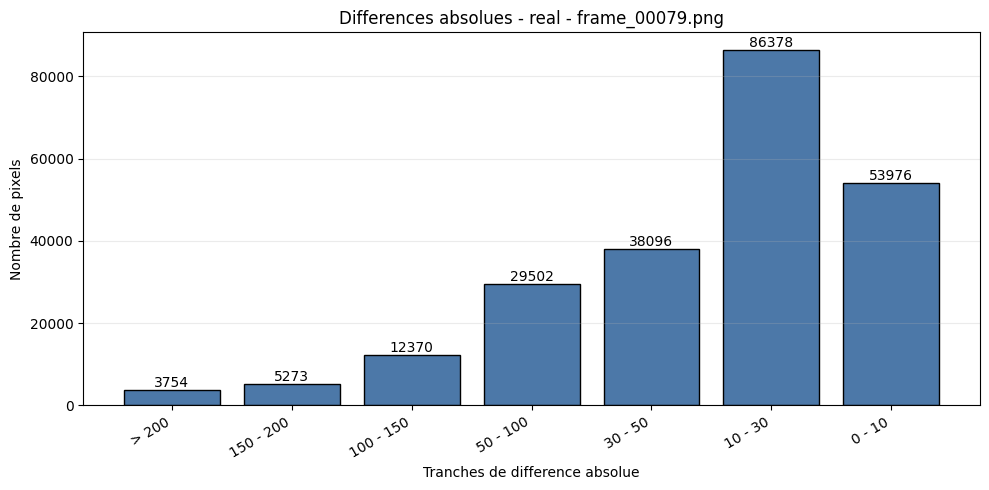

lvl:  4  initial error:  12642.02483285578
 error improvement too small, level converged! it:  5  error:  3282.3096751411067  lambda:  0.0
lvl:  3  initial error:  2950.2987727503505
 error improvement too small, level converged! it:  4  error:  2853.127152514836  lambda:  0.0
lvl:  2  initial error:  3083.5897180197335
 error improvement too small, level converged! it:  4  error:  3034.241608082349  lambda:  0.0
[real] frame 80 -> frame_00080.png | sum error = 748376640.00 | mean abs error = 36.6109 | valid pixels = 222247


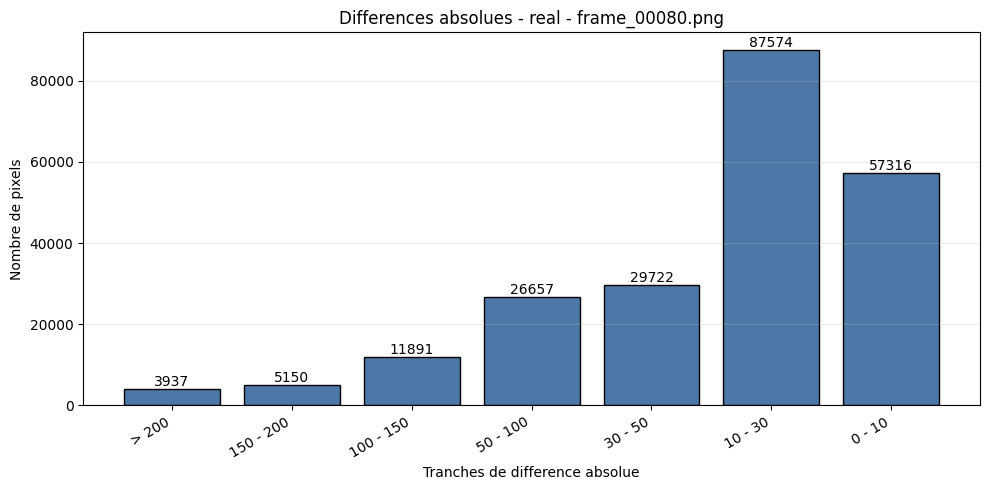

lvl:  4  initial error:  13076.808978032474
 error improvement too small, level converged! it:  5  error:  2318.907724325961  lambda:  0.4
lvl:  3  initial error:  2778.802825907205
 error improvement too small, level converged! it:  6  error:  2754.874726735268  lambda:  0.0
lvl:  2  initial error:  2971.047135301223
 error improvement too small, level converged! it:  4  error:  2921.8738773417685  lambda:  0.1
[real] frame 81 -> frame_00081.png | sum error = 734191872.00 | mean abs error = 35.3995 | valid pixels = 218228


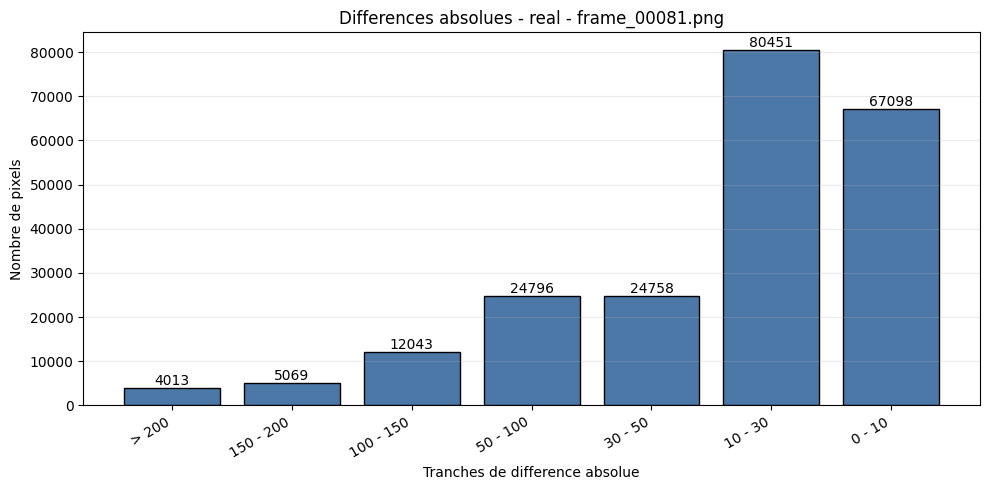

lvl:  4  initial error:  12992.889207258835
 error improvement too small, level converged! it:  3  error:  2374.409450981192  lambda:  0.1
lvl:  3  initial error:  2704.1211845151884
 error improvement too small, level converged! it:  5  error:  2583.020990131097  lambda:  0.0
lvl:  2  initial error:  2908.0207938286717
 error improvement too small, level converged! it:  8  error:  2786.096084565647  lambda:  0.0
[real] frame 82 -> frame_00082.png | sum error = 708826368.00 | mean abs error = 33.7491 | valid pixels = 217329


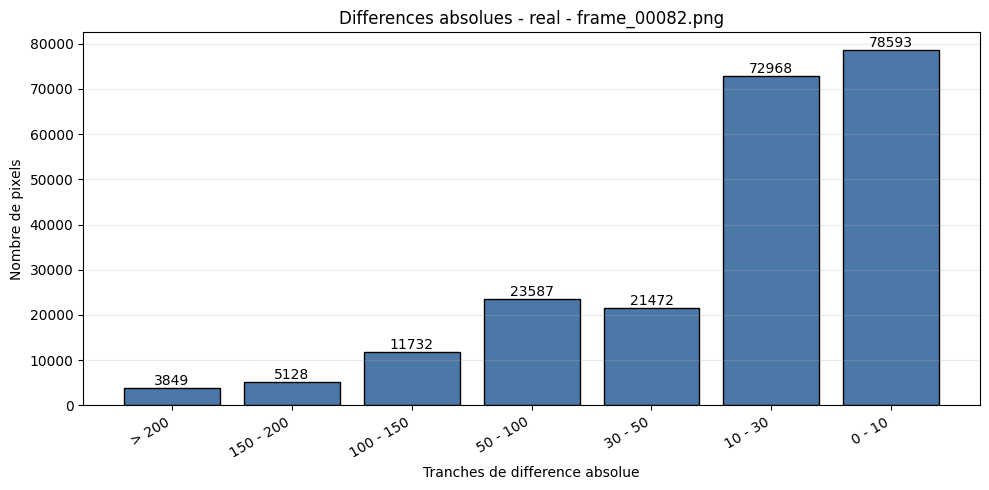

lvl:  4  initial error:  13095.32282712512
 error improvement too small, level converged! it:  4  error:  2458.6349934069385  lambda:  0.8
lvl:  3  initial error:  2681.52370085331
 error improvement too small, level converged! it:  5  error:  2570.4755743477754  lambda:  0.0
lvl:  2  initial error:  2911.9657252741617
 error improvement too small, level converged! it:  9  error:  2779.903377627624  lambda:  0.0
[real] frame 83 -> frame_00083.png | sum error = 706653568.00 | mean abs error = 33.7783 | valid pixels = 216520


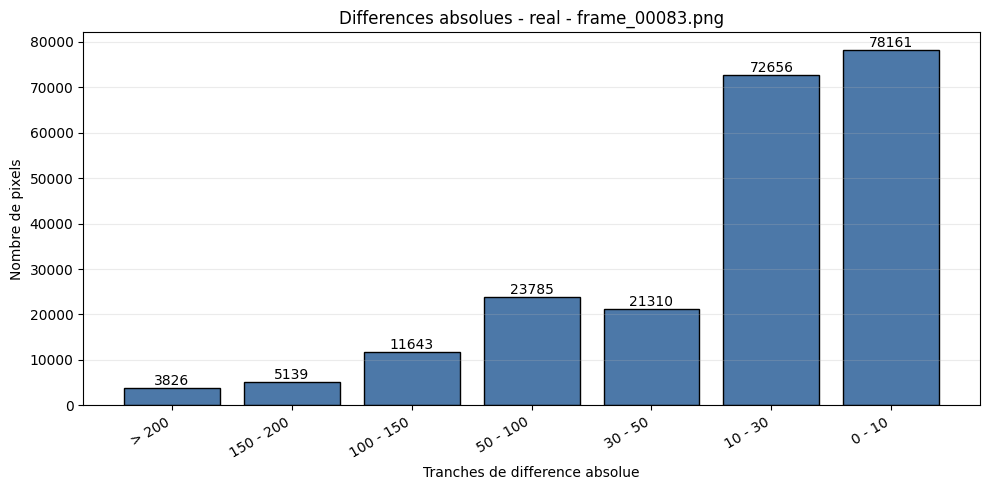

lvl:  4  initial error:  12714.92359121299
 error improvement too small, level converged! it:  6  error:  2235.7166607315335  lambda:  6.4
lvl:  3  initial error:  2711.312850750554
 error improvement too small, level converged! it:  3  error:  2674.1535356722966  lambda:  0.0
lvl:  2  initial error:  2829.9094702132925
 error improvement too small, level converged! it:  4  error:  2801.118843756054  lambda:  0.0
[real] frame 84 -> frame_00084.png | sum error = 706663296.00 | mean abs error = 33.7347 | valid pixels = 217705


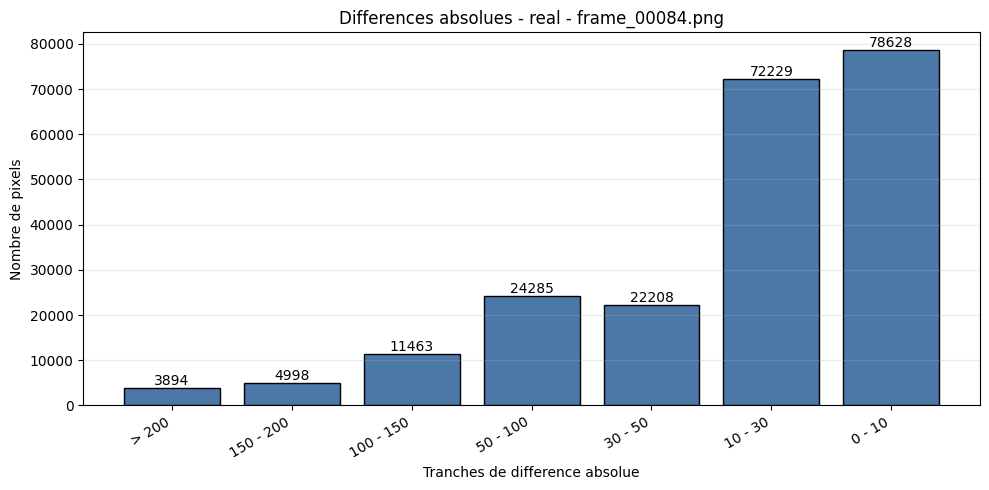

lvl:  4  initial error:  12016.161413562559
 error improvement too small, level converged! it:  6  error:  2607.250943093432  lambda:  14073748835532.8
lvl:  3  initial error:  2516.411198365939
 error improvement too small, level converged! it:  4  error:  2452.3951057390045  lambda:  0.0
lvl:  2  initial error:  2780.364048835307
 error improvement too small, level converged! it:  8  error:  2680.6616865305987  lambda:  1.6
[real] frame 85 -> frame_00085.png | sum error = 681660480.00 | mean abs error = 32.7347 | valid pixels = 221986


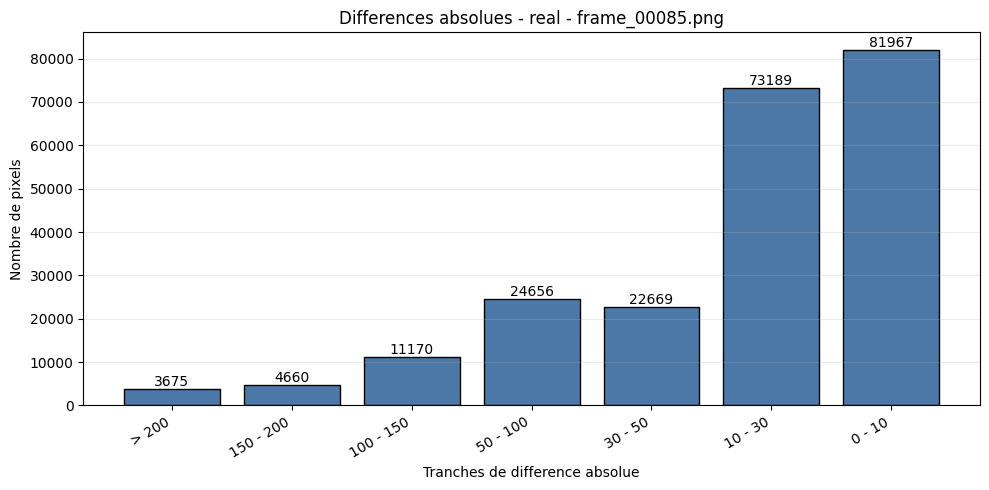

lvl:  4  initial error:  11652.998089780323
 error improvement too small, level converged! it:  7  error:  2249.2329405202695  lambda:  0.1
lvl:  3  initial error:  2370.3636119338194
 error improvement too small, level converged! it:  2  error:  2331.7306577673767  lambda:  12.8
lvl:  2  initial error:  2637.6326553716044
 error improvement too small, level converged! it:  8  error:  2566.5020695036337  lambda:  0.1
[real] frame 86 -> frame_00086.png | sum error = 658242816.00 | mean abs error = 31.9984 | valid pixels = 226062


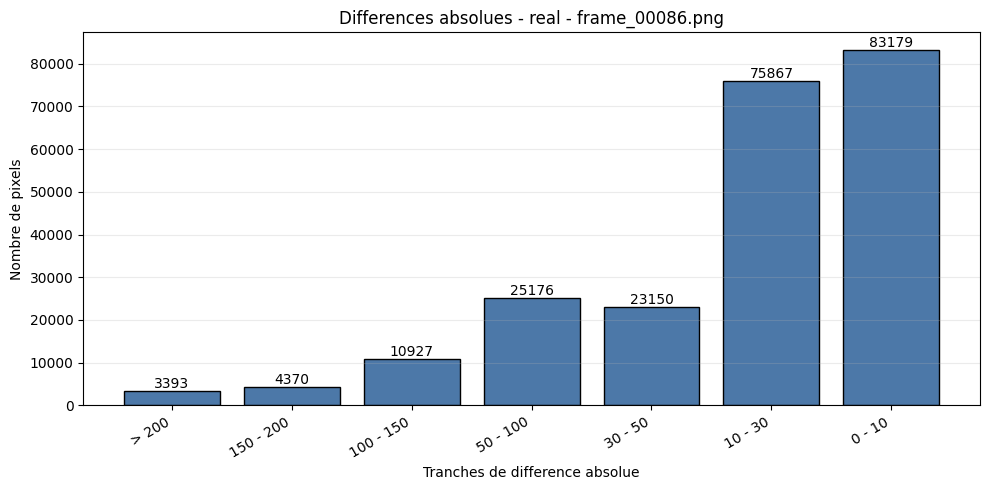

lvl:  4  initial error:  11394.64851957975
update too small, level converged! it:  6  error:  2419.206841906719  lambda:  450359962737049.6
lvl:  3  initial error:  2215.7137306162267
 error improvement too small, level converged! it:  4  error:  2191.2085738007404  lambda:  0.0
lvl:  2  initial error:  2435.0205740080064
 error improvement too small, level converged! it:  5  error:  2375.2799454688943  lambda:  0.0
[real] frame 87 -> frame_00087.png | sum error = 625025024.00 | mean abs error = 30.8844 | valid pixels = 231247


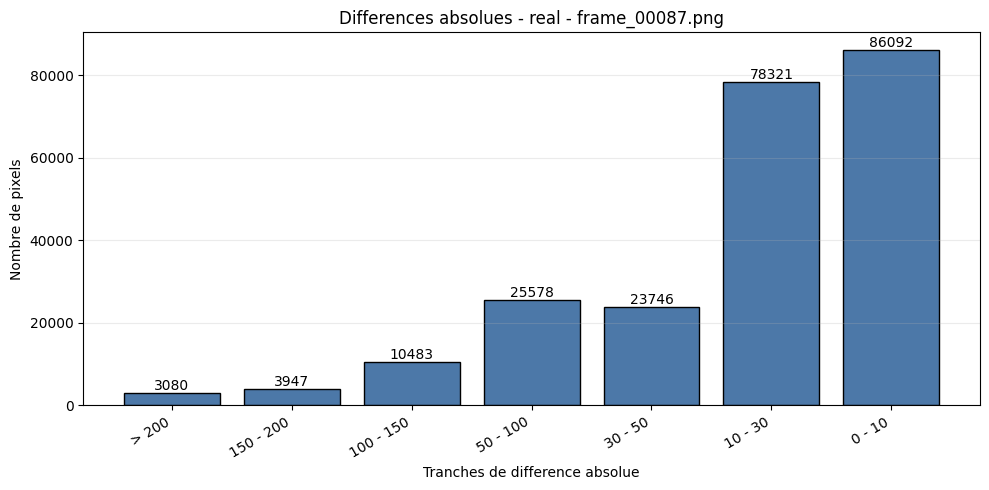

lvl:  4  initial error:  11570.231136580707
update too small, level converged! it:  7  error:  1913.9913786114294  lambda:  112589990684262.4
lvl:  3  initial error:  2061.307312913553
 error improvement too small, level converged! it:  2  error:  2027.3440525946369  lambda:  25.6
lvl:  2  initial error:  2141.1817859110483
 error improvement too small, level converged! it:  4  error:  2107.130818763321  lambda:  0.0
[real] frame 88 -> frame_00088.png | sum error = 571444032.00 | mean abs error = 29.3001 | valid pixels = 234318


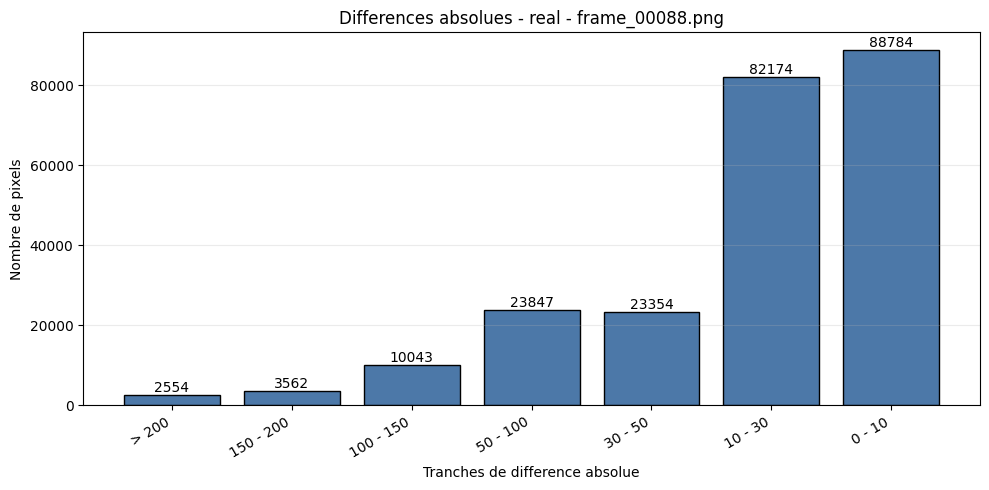

lvl:  4  initial error:  10610.0076408787
 error improvement too small, level converged! it:  5  error:  2111.2910103120257  lambda:  0.0
lvl:  3  initial error:  1970.6455742137455
 error improvement too small, level converged! it:  4  error:  1821.052459515493  lambda:  0.0
lvl:  2  initial error:  1968.58451673831
 error improvement too small, level converged! it:  3  error:  1943.904299177397  lambda:  0.0
[real] frame 89 -> frame_00089.png | sum error = 526704448.00 | mean abs error = 28.1447 | valid pixels = 240630


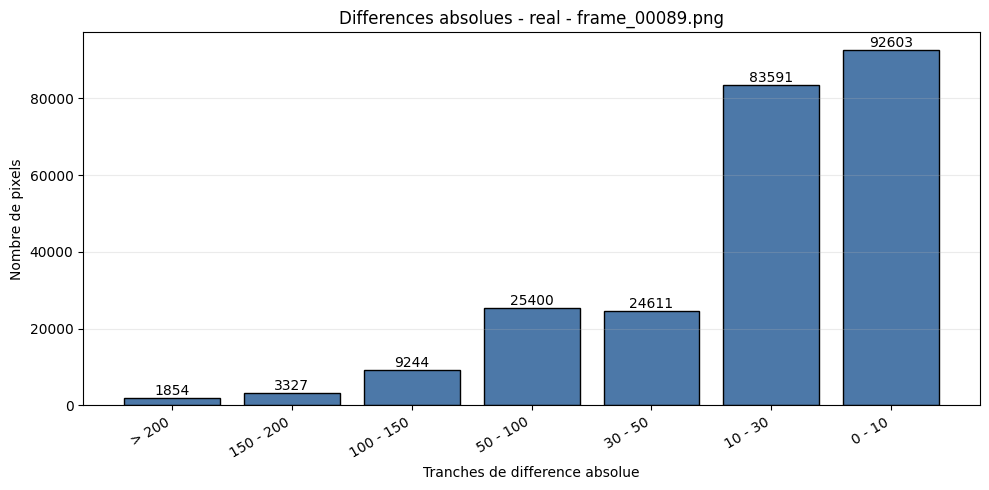

lvl:  4  initial error:  9296.251193887298
 error improvement too small, level converged! it:  9  error:  2027.6261198287011  lambda:  0.0
lvl:  3  initial error:  1701.0089091128714
 error improvement too small, level converged! it:  3  error:  1672.1937553866096  lambda:  0.0
lvl:  2  initial error:  1689.0901007105706
 error improvement too small, level converged! it:  5  error:  1667.7479518702175  lambda:  0.0
[real] frame 90 -> frame_00090.png | sum error = 471138176.00 | mean abs error = 26.4558 | valid pixels = 251965


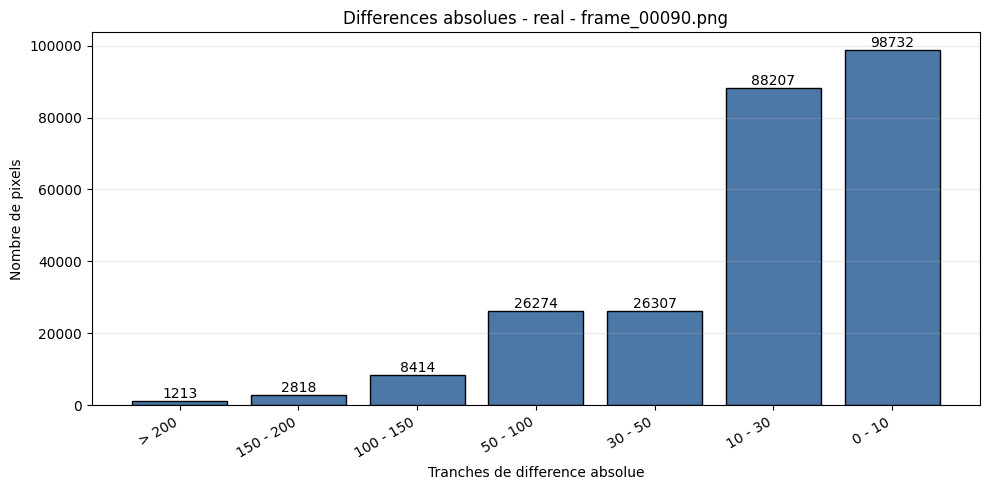

lvl:  4  initial error:  8483.82617000955
 error improvement too small, level converged! it:  9  error:  1639.2697040546568  lambda:  0.1
lvl:  3  initial error:  1433.7733984930458
update too small, level converged! it:  3  error:  1268.3976661116474  lambda:  112589990684262.4
lvl:  2  initial error:  1250.3221887579741
 error improvement too small, level converged! it:  5  error:  1219.4486903267032  lambda:  0.0
[real] frame 91 -> frame_00091.png | sum error = 354331520.00 | mean abs error = 22.3875 | valid pixels = 261392


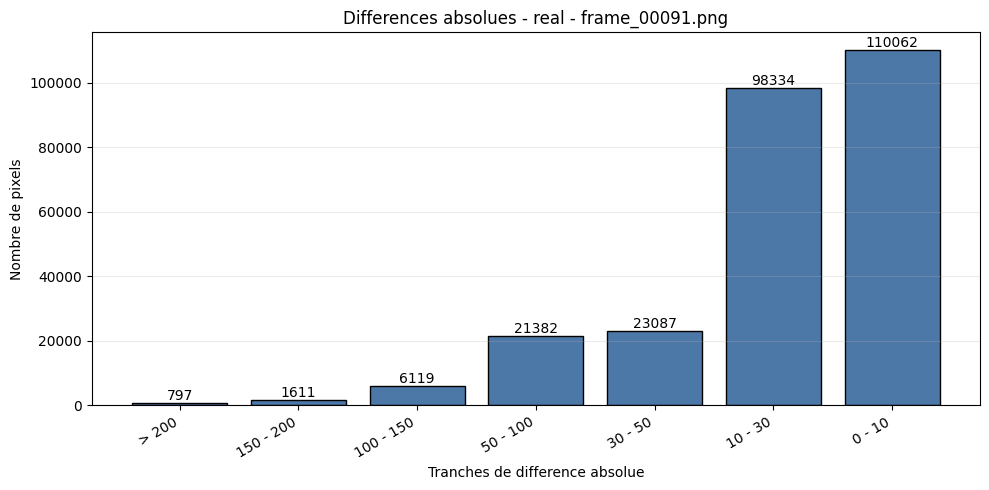

lvl:  4  initial error:  6959.151862464182
 error improvement too small, level converged! it:  6  error:  1547.9047579084604  lambda:  1.6
lvl:  3  initial error:  1356.7065364351167
update too small, level converged! it:  18  error:  1065.4817579310218  lambda:  28147497671065.6
lvl:  2  initial error:  930.3201801255448
 error improvement too small, level converged! it:  12  error:  768.4968359498363  lambda:  0.0
[real] frame 92 -> frame_00092.png | sum error = 225988432.00 | mean abs error = 18.5073 | valid pixels = 269356


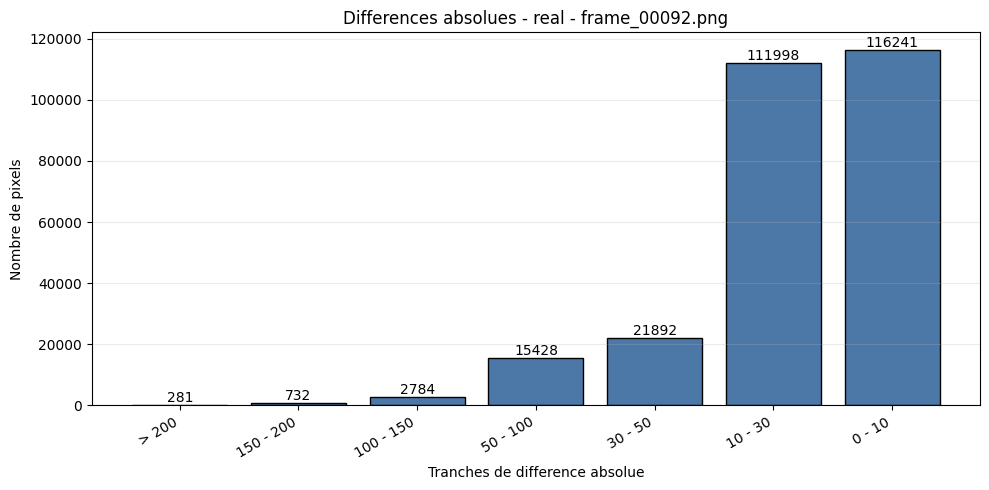

lvl:  4  initial error:  5067.659980897802
 error improvement too small, level converged! it:  7  error:  1483.0941260101251  lambda:  0.1
lvl:  3  initial error:  1151.114915944909
 error improvement too small, level converged! it:  5  error:  986.3673014279193  lambda:  1759218604441.6
lvl:  2  initial error:  892.5302593886595
update too small, level converged! it:  6  error:  857.9807775516946  lambda:  28147497671065.6
[real] frame 93 -> frame_00093.png | sum error = 261626976.00 | mean abs error = 19.0834 | valid pixels = 281677


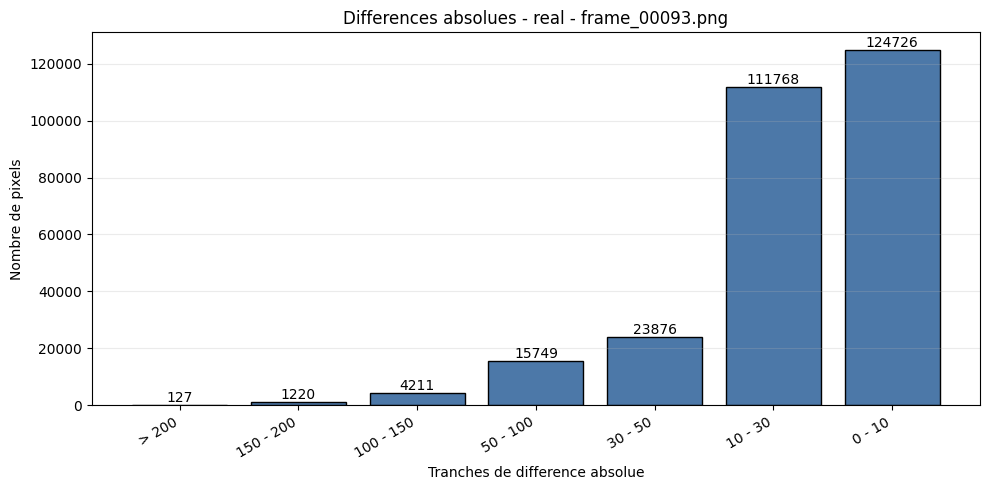

lvl:  4  initial error:  3439.5348615090725
 error improvement too small, level converged! it:  9  error:  1072.6144686750833  lambda:  0.8
lvl:  3  initial error:  917.7603554629661
 error improvement too small, level converged! it:  6  error:  813.2270369070951  lambda:  0.0
lvl:  2  initial error:  736.6947813024966
 error improvement too small, level converged! it:  15  error:  496.1965012491568  lambda:  0.0
[real] frame 94 -> frame_00094.png | sum error = 180337792.00 | mean abs error = 12.4956 | valid pixels = 285410


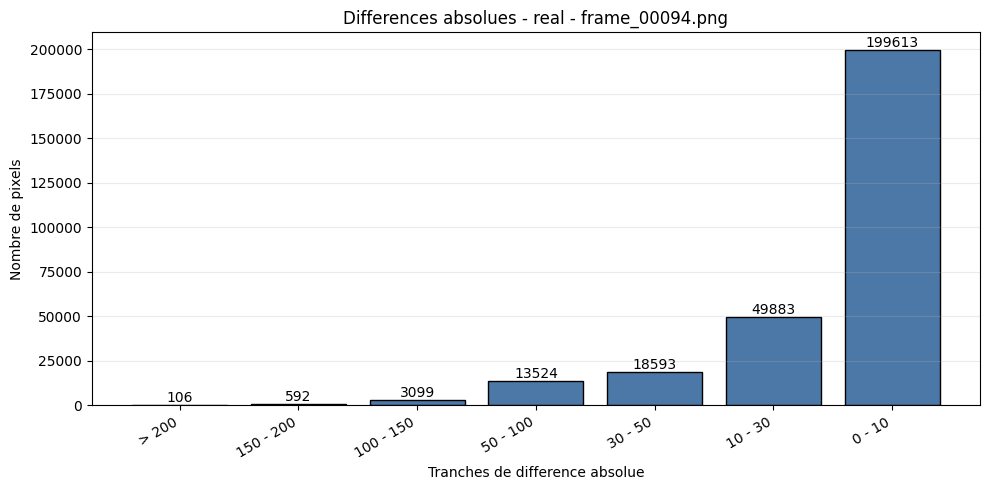

lvl:  4  initial error:  3336.335243553007
 error improvement too small, level converged! it:  3  error:  1197.2132955690893  lambda:  6.4
lvl:  3  initial error:  1026.5511306185588
 error improvement too small, level converged! it:  3  error:  860.8436550597402  lambda:  219902325555.2
lvl:  2  initial error:  854.5176347459394
 error improvement too small, level converged! it:  6  error:  821.3361026582073  lambda:  0.0
[real] frame 95 -> frame_00095.png | sum error = 295856224.00 | mean abs error = 16.1239 | valid pixels = 279884


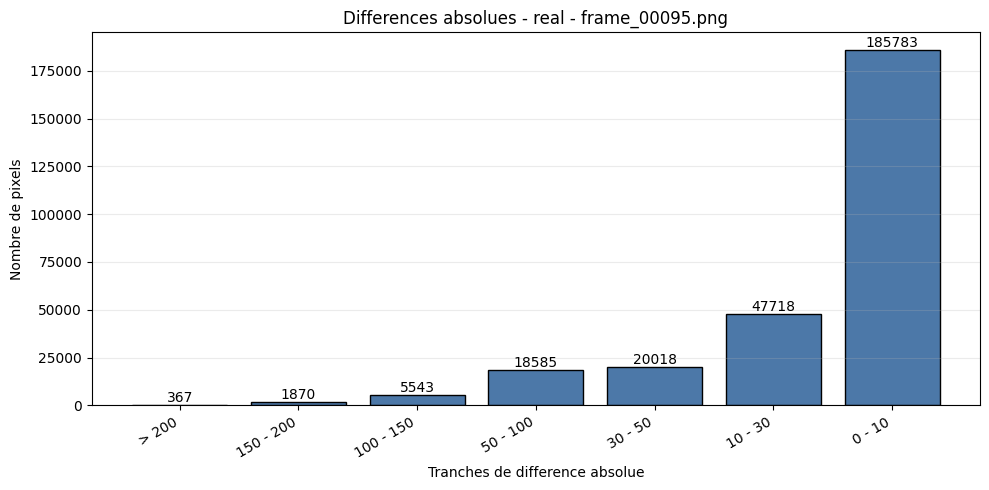

lvl:  4  initial error:  3321.1518624641812
 error improvement too small, level converged! it:  5  error:  1377.8966783492435  lambda:  0.0
lvl:  3  initial error:  1431.3476660254682
 error improvement too small, level converged! it:  10  error:  1222.4148081505048  lambda:  0.0
lvl:  2  initial error:  1344.946434532483
 error improvement too small, level converged! it:  5  error:  1313.8051596133228  lambda:  0.0
[real] frame 96 -> frame_00096.png | sum error = 411330976.00 | mean abs error = 26.0058 | valid pixels = 260956


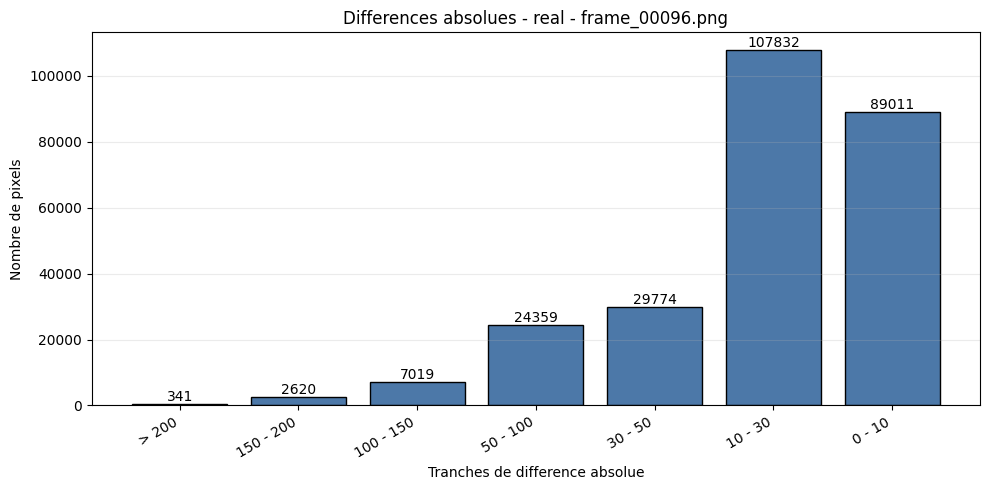

lvl:  4  initial error:  4062.288443170963
 error improvement too small, level converged! it:  5  error:  1463.8525003092286  lambda:  25.6
lvl:  3  initial error:  1460.1893881117214
 error improvement too small, level converged! it:  3  error:  1372.0787383717427  lambda:  879609302220.8
lvl:  2  initial error:  1482.1920047850285
 error improvement too small, level converged! it:  6  error:  1411.3454086237327  lambda:  0.0
[real] frame 97 -> frame_00097.png | sum error = 419297024.00 | mean abs error = 27.2923 | valid pixels = 252462


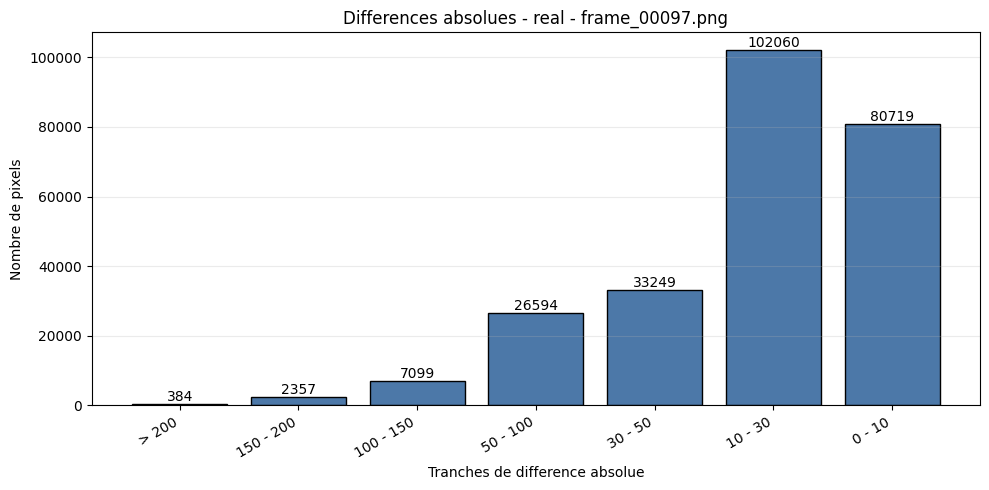

lvl:  4  initial error:  4663.422158548231
 error improvement too small, level converged! it:  7  error:  1298.2541024092416  lambda:  0.0
lvl:  3  initial error:  1531.9342479626685
 error improvement too small, level converged! it:  3  error:  1347.341234354084  lambda:  1759218604441.6
lvl:  2  initial error:  1502.3133201523979
 error improvement too small, level converged! it:  7  error:  1420.845378404652  lambda:  0.0
[real] frame 98 -> frame_00098.png | sum error = 415797088.00 | mean abs error = 27.7985 | valid pixels = 240831


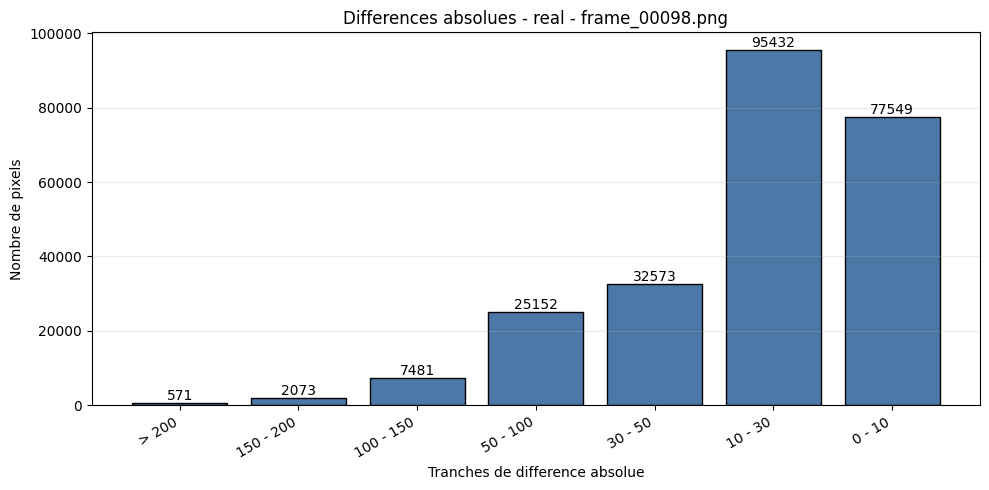

lvl:  4  initial error:  5355.826170009549
 error improvement too small, level converged! it:  5  error:  1462.1548911800542  lambda:  0.4
lvl:  3  initial error:  1665.3170238792977
 error improvement too small, level converged! it:  8  error:  1488.9313777080815  lambda:  0.0
lvl:  2  initial error:  1547.0656023221031
 error improvement too small, level converged! it:  8  error:  1465.9889613946282  lambda:  0.0
[real] frame 99 -> frame_00099.png | sum error = 426445120.00 | mean abs error = 28.6139 | valid pixels = 234396


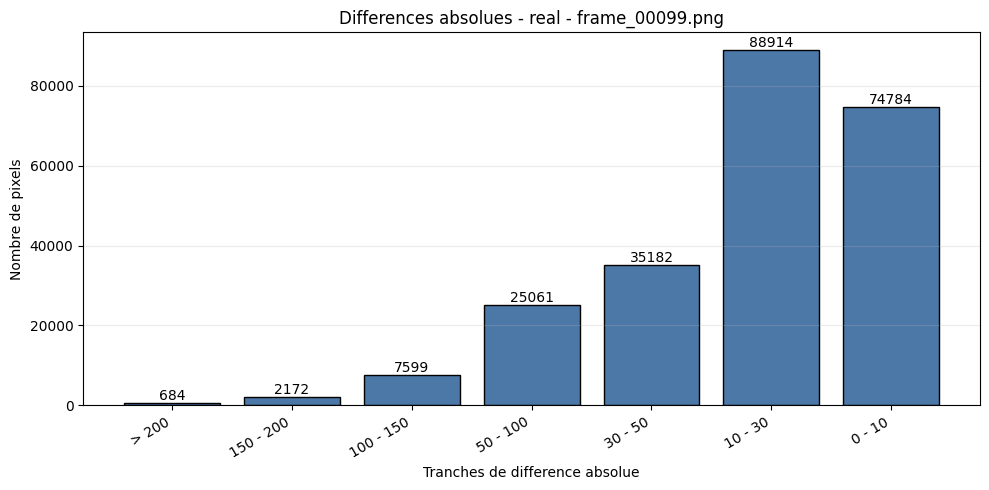

lvl:  4  initial error:  5684.006685768862
 error improvement too small, level converged! it:  3  error:  1654.1990538671755  lambda:  12.8
lvl:  3  initial error:  1668.9267032627963
 error improvement too small, level converged! it:  6  error:  1574.06272717771  lambda:  1759218604441.6
lvl:  2  initial error:  1728.2750144168315
 error improvement too small, level converged! it:  15  error:  1657.357325139824  lambda:  3518437208883.2
[real] frame 100 -> frame_00100.png | sum error = 462713856.00 | mean abs error = 30.3022 | valid pixels = 231703


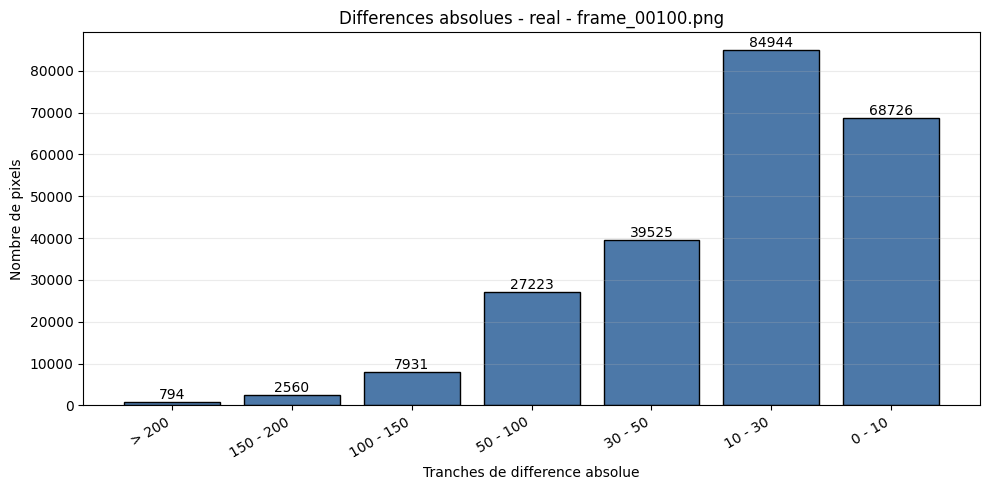

lvl:  4  initial error:  5717.14517669532
 error improvement too small, level converged! it:  4  error:  1683.412380095156  lambda:  0.0
lvl:  3  initial error:  1916.3814635782617
 error improvement too small, level converged! it:  5  error:  1764.9174303888606  lambda:  0.0
lvl:  2  initial error:  1941.2375873569565
 error improvement too small, level converged! it:  3  error:  1922.439840779666  lambda:  0.0
[real] frame 101 -> frame_00101.png | sum error = 530438656.00 | mean abs error = 32.1293 | valid pixels = 229861


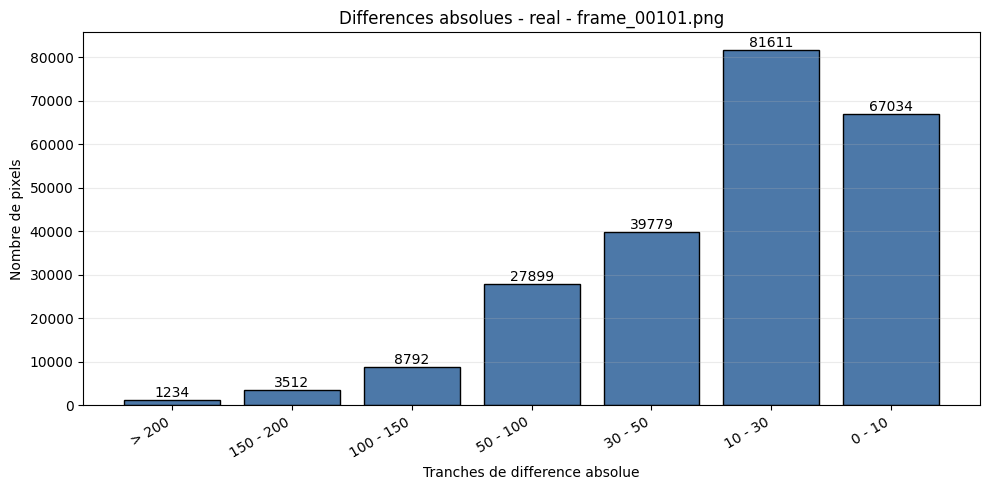

lvl:  4  initial error:  6116.820439350524
update too small, level converged! it:  5  error:  1629.0750054772166  lambda:  1801439850948198.5
lvl:  3  initial error:  2032.8067808603641
 error improvement too small, level converged! it:  4  error:  1940.6451943197474  lambda:  0.0
lvl:  2  initial error:  2128.1023177742777
 error improvement too small, level converged! it:  7  error:  2083.3840941233916  lambda:  0.0
[real] frame 102 -> frame_00102.png | sum error = 561942848.00 | mean abs error = 33.1490 | valid pixels = 229767


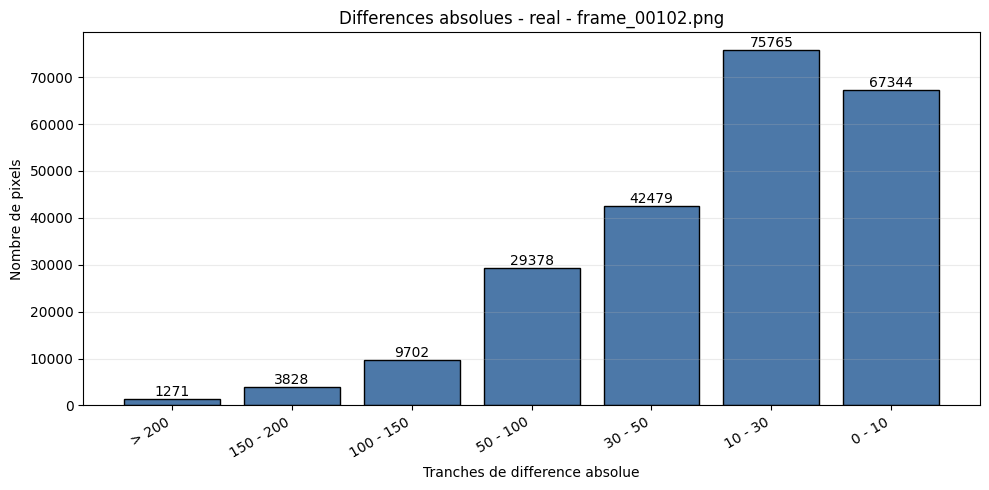

lvl:  4  initial error:  6391.027698185289
 error improvement too small, level converged! it:  3  error:  1844.8435019237477  lambda:  28147497671065.6
lvl:  3  initial error:  2183.6856751338523
 error improvement too small, level converged! it:  4  error:  2054.3788078511407  lambda:  0.0
lvl:  2  initial error:  2255.6858004472
 error improvement too small, level converged! it:  3  error:  2234.711665677757  lambda:  219902325555.2
[real] frame 103 -> frame_00103.png | sum error = 603261120.00 | mean abs error = 34.4596 | valid pixels = 226514


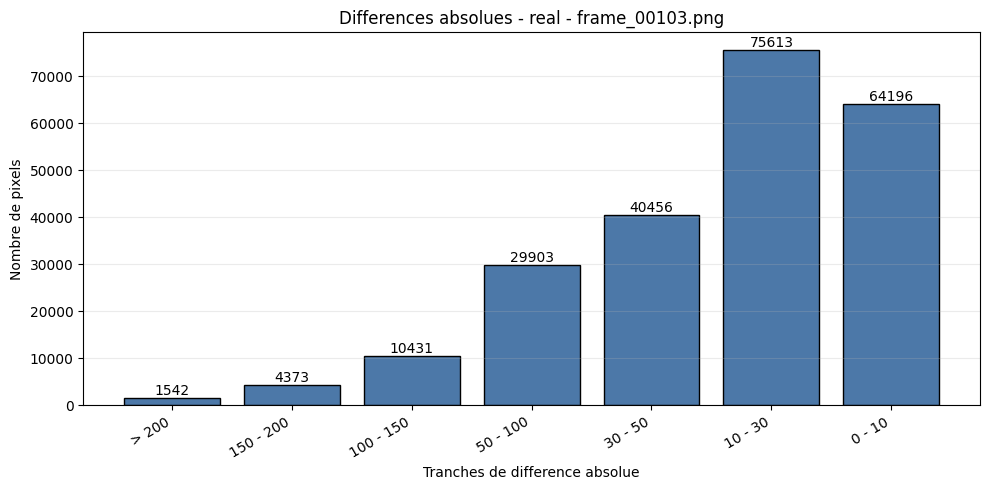

lvl:  4  initial error:  6285.321872015281
 error improvement too small, level converged! it:  4  error:  1857.5230152196998  lambda:  109951162777.6
lvl:  3  initial error:  2150.3958483550214
 error improvement too small, level converged! it:  2  error:  2071.5801915592783  lambda:  25.6
lvl:  2  initial error:  2327.556201779333
 error improvement too small, level converged! it:  2  error:  2320.5695145998275  lambda:  1.6
[real] frame 104 -> frame_00104.png | sum error = 614901568.00 | mean abs error = 34.7470 | valid pixels = 223840


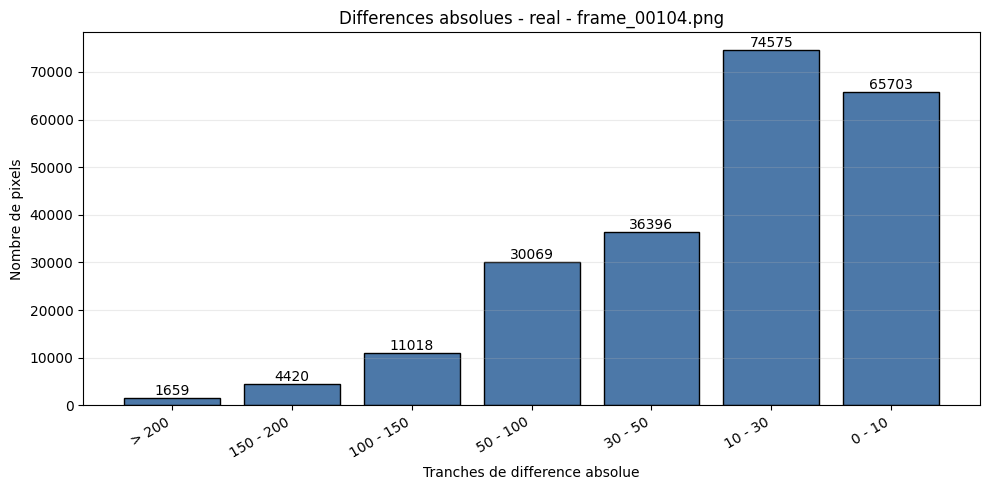

lvl:  4  initial error:  6267.808978032472
 error improvement too small, level converged! it:  7  error:  2010.9482289596829  lambda:  6.4
lvl:  3  initial error:  2316.511659592803
 error improvement too small, level converged! it:  3  error:  2154.6596107822297  lambda:  0.1
lvl:  2  initial error:  2421.0747742468498
 error improvement too small, level converged! it:  1  error:  2420.624796983201  lambda:  0.0
[real] frame 105 -> frame_00105.png | sum error = 625294080.00 | mean abs error = 35.2387 | valid pixels = 223169


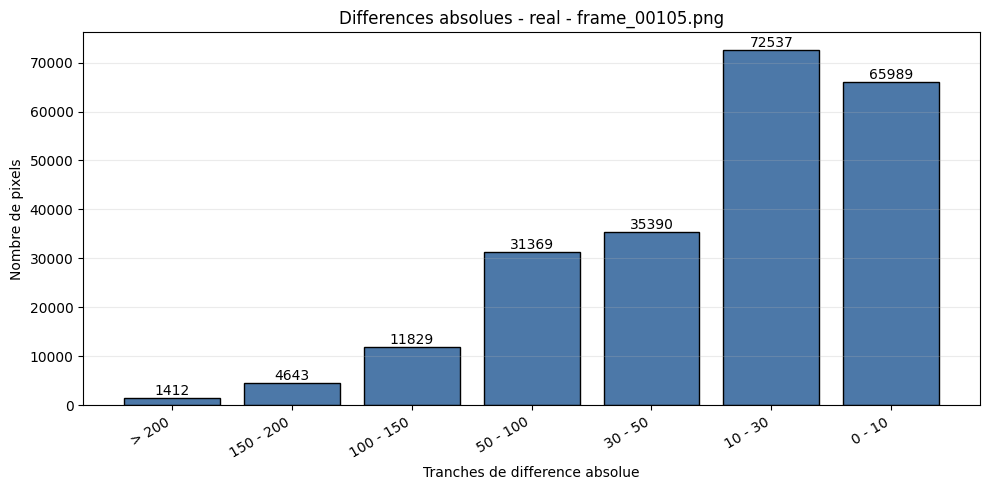

lvl:  4  initial error:  5937.9608404966575
 error improvement too small, level converged! it:  4  error:  2056.5782525097025  lambda:  51.2
lvl:  3  initial error:  2347.4745828716636
 error improvement too small, level converged! it:  4  error:  2302.3084621473727  lambda:  6.4
lvl:  2  initial error:  2575.209569609881
 error improvement too small, level converged! it:  1  error:  2574.0720840842587  lambda:  0.0
[real] frame 106 -> frame_00106.png | sum error = 656929600.00 | mean abs error = 36.4471 | valid pixels = 222671


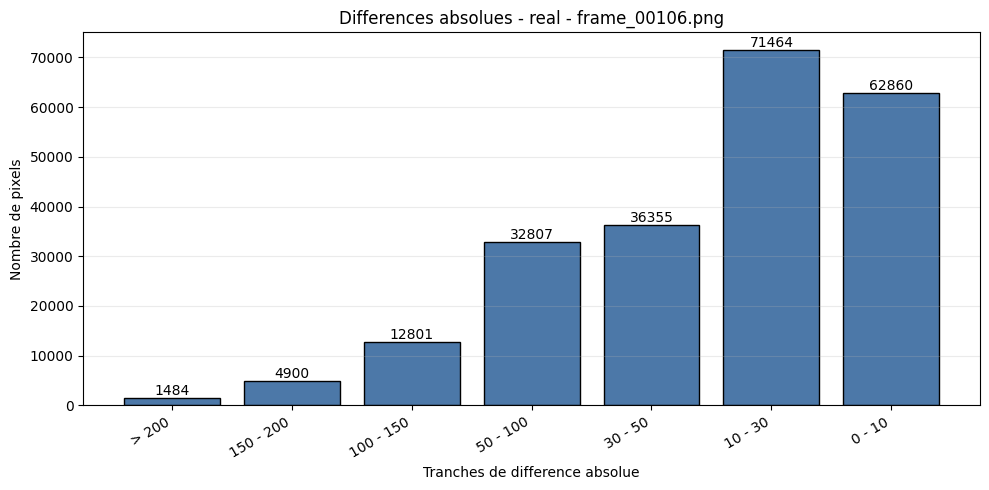

lvl:  4  initial error:  6282.497612225406
 error improvement too small, level converged! it:  10  error:  2147.955494379976  lambda:  0.1
lvl:  3  initial error:  2504.9357091841653
 error improvement too small, level converged! it:  5  error:  2449.2664901872163  lambda:  0.8
lvl:  2  initial error:  2755.3353136583196
 error improvement too small, level converged! it:  1  error:  2753.5062266957034  lambda:  0.0
[real] frame 107 -> frame_00107.png | sum error = 694665664.00 | mean abs error = 37.6277 | valid pixels = 223877


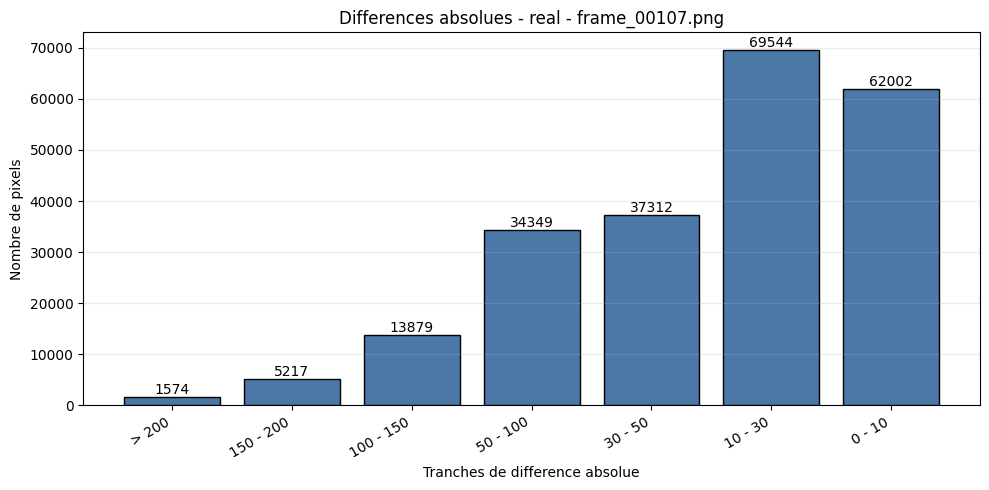

lvl:  4  initial error:  6190.883476599809
update too small, level converged! it:  5  error:  2301.134562188989  lambda:  3602879701896397.0
lvl:  3  initial error:  2667.7398101694475
 error improvement too small, level converged! it:  2  error:  2655.258073113688  lambda:  0.1
lvl:  2  initial error:  2896.457341243016
 error improvement too small, level converged! it:  1  error:  2894.366861407758  lambda:  0.4
[real] frame 108 -> frame_00108.png | sum error = 728545024.00 | mean abs error = 38.7463 | valid pixels = 223410


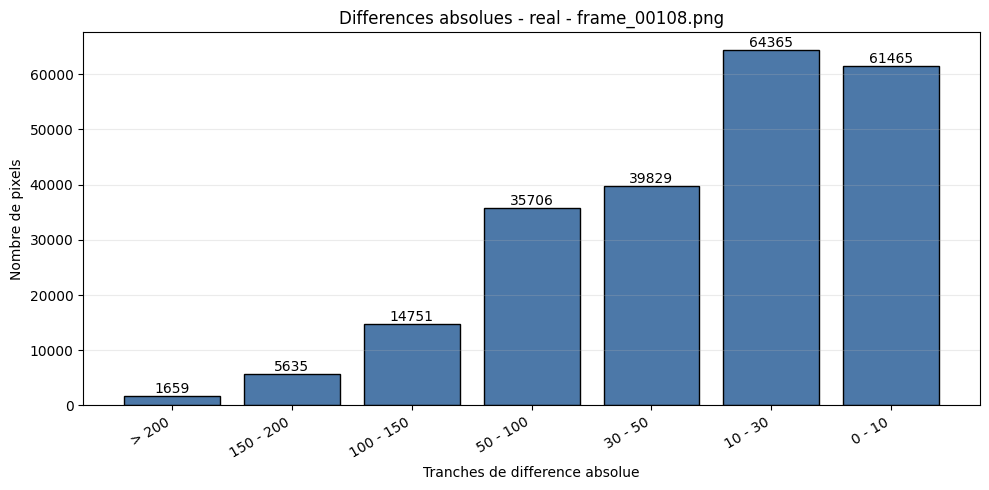

lvl:  4  initial error:  6183.682903533906
 error improvement too small, level converged! it:  5  error:  2458.379893325531  lambda:  3.2
lvl:  3  initial error:  2943.246539078632
 error improvement too small, level converged! it:  12  error:  2781.8608858954794  lambda:  0.1
lvl:  2  initial error:  3070.224492969035
 error improvement too small, level converged! it:  1  error:  3069.791809151045  lambda:  3.2
[real] frame 109 -> frame_00109.png | sum error = 780395328.00 | mean abs error = 40.3419 | valid pixels = 223701


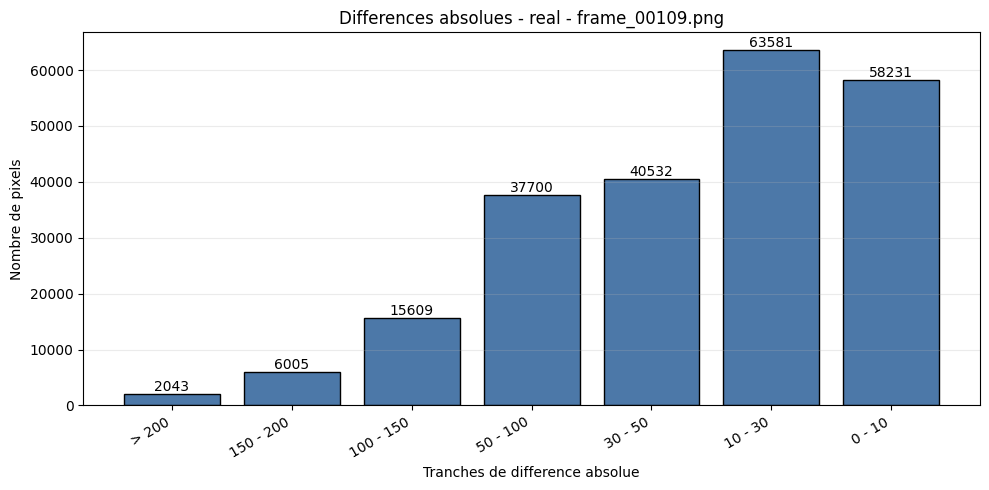

lvl:  4  initial error:  6173.688634192932
update too small, level converged! it:  5  error:  2494.3142139591614  lambda:  900719925474099.2
lvl:  3  initial error:  2998.7980234387633
 error improvement too small, level converged! it:  6  error:  2958.036671377847  lambda:  1.6
lvl:  2  initial error:  3152.064451475825
 error improvement too small, level converged! it:  10  error:  3056.4829798619303  lambda:  0.0
[real] frame 110 -> frame_00110.png | sum error = 779798080.00 | mean abs error = 40.4326 | valid pixels = 225577


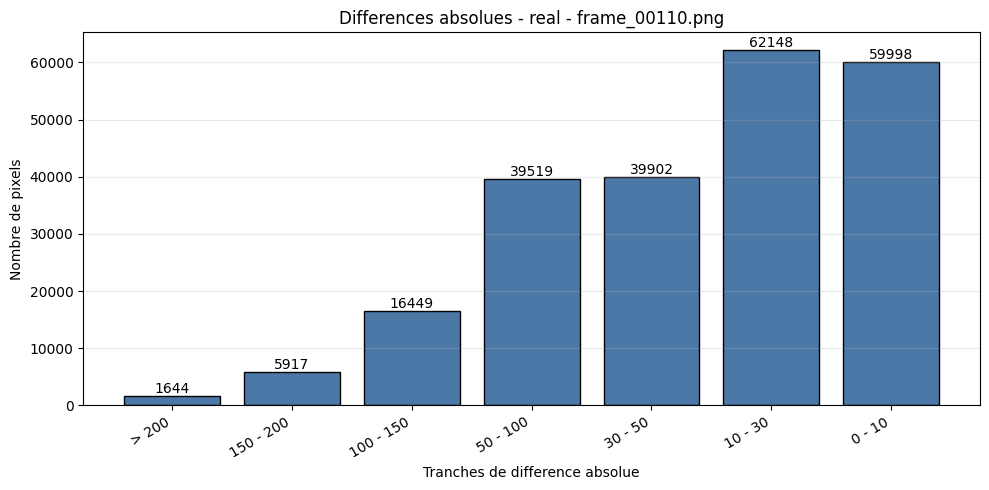

lvl:  4  initial error:  6478.988538681949
 error improvement too small, level converged! it:  7  error:  2551.764008638806  lambda:  0.8
lvl:  3  initial error:  3020.634298608797
 error improvement too small, level converged! it:  8  error:  2916.5026274310744  lambda:  0.0
lvl:  2  initial error:  3190.5879764434503
 error improvement too small, level converged! it:  9  error:  3078.916538590365  lambda:  0.0
[real] frame 111 -> frame_00111.png | sum error = 777592448.00 | mean abs error = 40.3794 | valid pixels = 226382


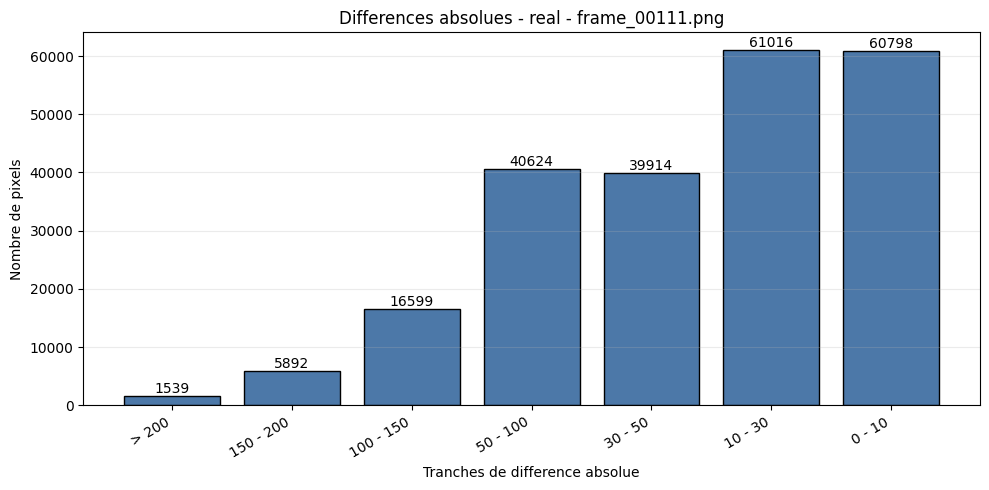

lvl:  4  initial error:  6749.3915950334285
 error improvement too small, level converged! it:  6  error:  2468.6361874669774  lambda:  6.4
lvl:  3  initial error:  3176.9594631915256
 error improvement too small, level converged! it:  10  error:  2940.876595322056  lambda:  3.2
lvl:  2  initial error:  3180.2448449239896
 error improvement too small, level converged! it:  2  error:  3167.588981354194  lambda:  0.0
[real] frame 112 -> frame_00112.png | sum error = 786347968.00 | mean abs error = 40.8363 | valid pixels = 223048


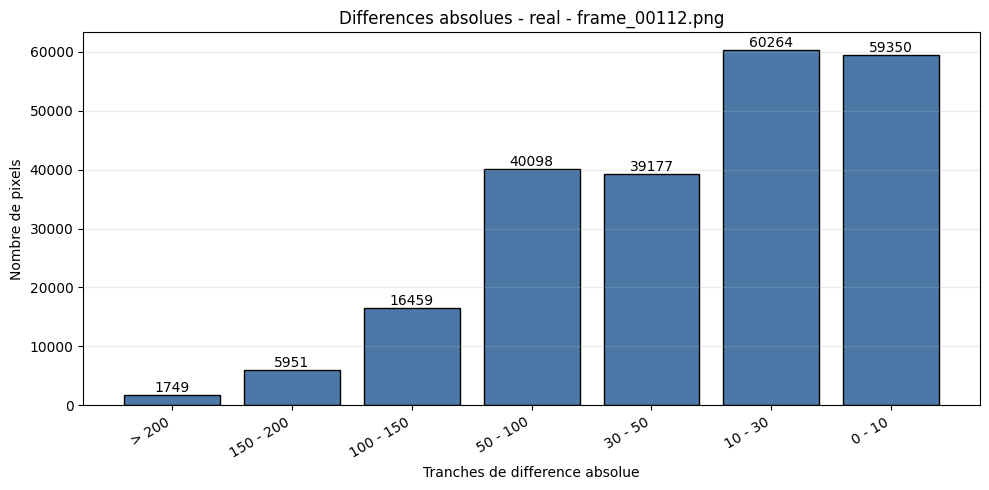

lvl:  4  initial error:  7008.086914995224
 error improvement too small, level converged! it:  5  error:  2500.018097590995  lambda:  0.1
lvl:  3  initial error:  3003.343903724274
 error improvement too small, level converged! it:  1  error:  3001.346710588728  lambda:  0.4
lvl:  2  initial error:  3234.0721270420213
 error improvement too small, level converged! it:  4  error:  3206.588178928844  lambda:  0.1
[real] frame 113 -> frame_00113.png | sum error = 773055488.00 | mean abs error = 40.9821 | valid pixels = 218537


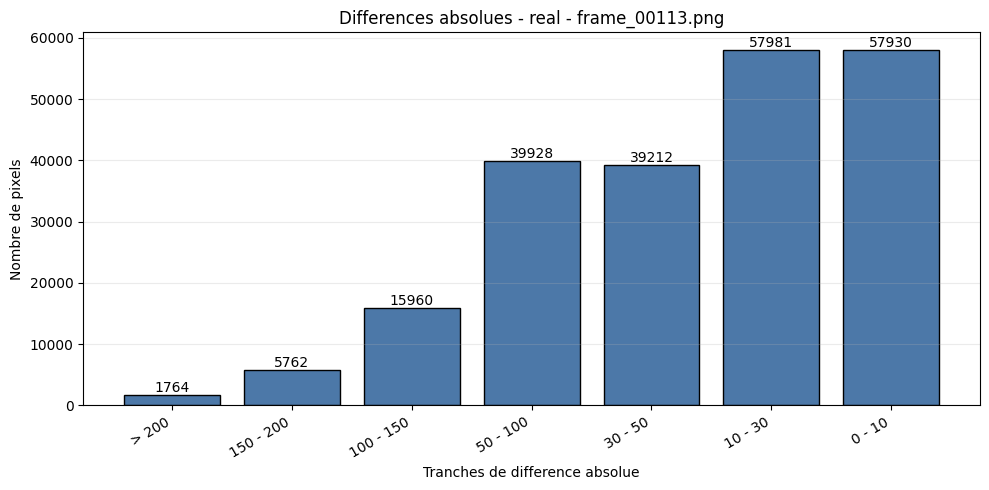

lvl:  4  initial error:  7118.656160458452
 error improvement too small, level converged! it:  4  error:  2628.4572037815133  lambda:  3518437208883.2
lvl:  3  initial error:  3008.125587539309
 error improvement too small, level converged! it:  5  error:  2898.028881834704  lambda:  0.8
lvl:  2  initial error:  3187.7521419906902
 error improvement too small, level converged! it:  3  error:  3174.3462592041947  lambda:  6.4
[real] frame 114 -> frame_00114.png | sum error = 732120576.00 | mean abs error = 40.7692 | valid pixels = 209912


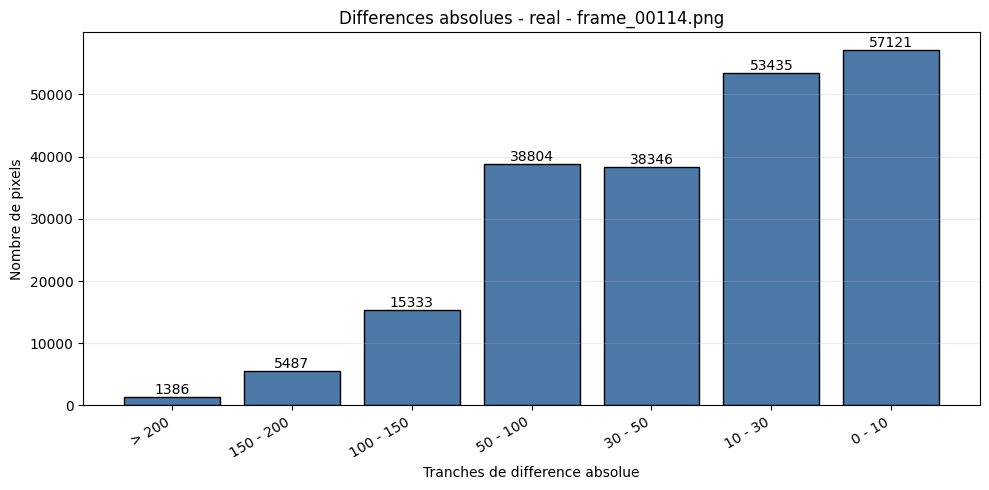

lvl:  4  initial error:  7277.425023877745
 error improvement too small, level converged! it:  3  error:  2597.6985533138923  lambda:  14073748835532.8
lvl:  3  initial error:  3071.8794666708427
 error improvement too small, level converged! it:  3  error:  2908.17376810971  lambda:  0.8
lvl:  2  initial error:  3228.1087729684077
 error improvement too small, level converged! it:  3  error:  3190.645757725359  lambda:  0.0
[real] frame 115 -> frame_00115.png | sum error = 716733760.00 | mean abs error = 40.6560 | valid pixels = 205549


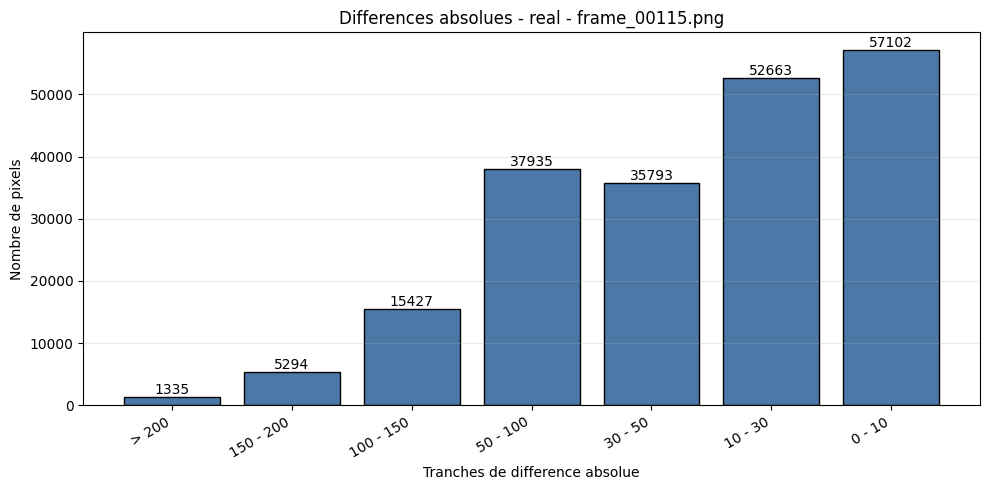

lvl:  4  initial error:  7267.106972301813
 error improvement too small, level converged! it:  3  error:  2676.9125943615336  lambda:  7036874417766.4
lvl:  3  initial error:  3191.098278652706
 error improvement too small, level converged! it:  6  error:  3082.7508630701673  lambda:  0.4
lvl:  2  initial error:  3358.6201190368956
 error improvement too small, level converged! it:  1  error:  3357.1038308666116  lambda:  0.0
[real] frame 116 -> frame_00116.png | sum error = 729231744.00 | mean abs error = 41.9214 | valid pixels = 200448


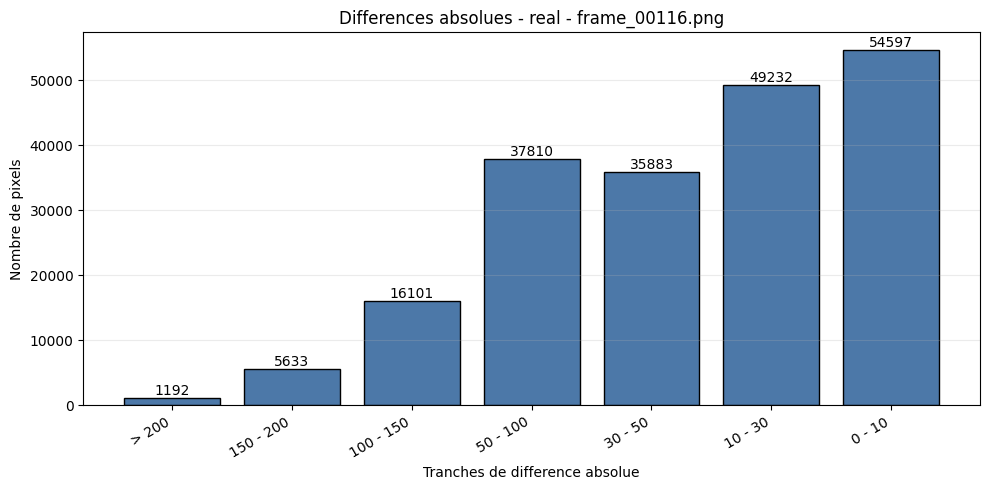

lvl:  4  initial error:  7320.892072588347
 error improvement too small, level converged! it:  5  error:  2773.960962390547  lambda:  0.0
lvl:  3  initial error:  3309.8613684933703
 error improvement too small, level converged! it:  1  error:  3306.566155012894  lambda:  0.1
lvl:  2  initial error:  3518.2235298250207
 error improvement too small, level converged! it:  6  error:  3451.4871548830765  lambda:  0.0
[real] frame 117 -> frame_00117.png | sum error = 722298880.00 | mean abs error = 42.5376 | valid pixels = 193122


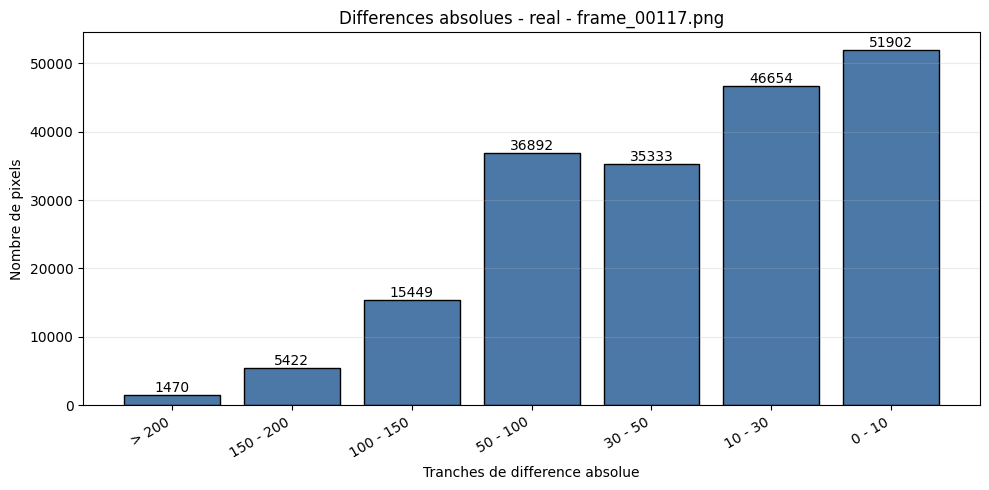

lvl:  4  initial error:  7319.671442215855
 error improvement too small, level converged! it:  7  error:  2712.9935952987803  lambda:  0.4
lvl:  3  initial error:  3247.3096157310506
 error improvement too small, level converged! it:  4  error:  3071.4696705020883  lambda:  0.0
lvl:  2  initial error:  3361.614547615346
 error improvement too small, level converged! it:  1  error:  3358.795684223501  lambda:  0.0
[real] frame 118 -> frame_00118.png | sum error = 647461952.00 | mean abs error = 41.8340 | valid pixels = 178609


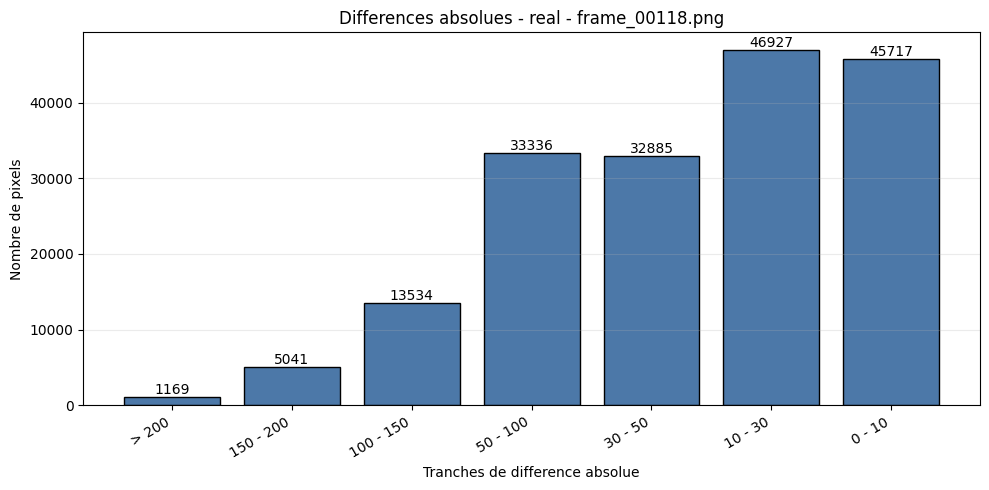

lvl:  4  initial error:  7384.028653295129
 error improvement too small, level converged! it:  17  error:  2141.949591837761  lambda:  102.4
lvl:  3  initial error:  2620.9607668228414
 error improvement too small, level converged! it:  6  error:  2412.0780297717606  lambda:  12.8
lvl:  2  initial error:  2640.2280784470645
 error improvement too small, level converged! it:  7  error:  2588.400608903808  lambda:  0.8
[real] frame 119 -> frame_00119.png | sum error = 469524160.00 | mean abs error = 37.9638 | valid pixels = 162540


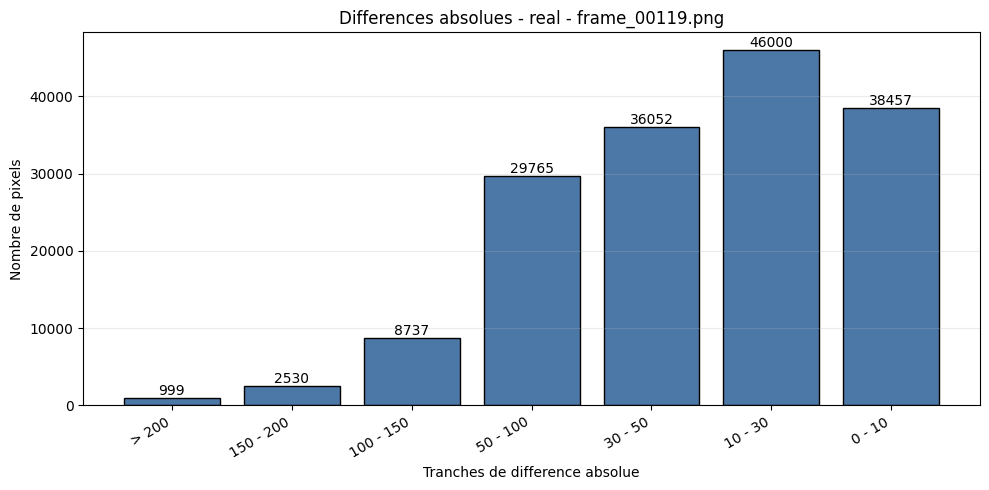

In [66]:
# Boucle simple sur toute la sequence: deth estimation puis pose estimation par frame.
# Cette version reconstruit une camera coherente pour la sequence traitee
# et reinitialise le solveur pour eviter de reutiliser un etat precedent.
frame_paths = real_frame_paths[0:120]  # Remplace par fake_frame_paths[:10] si tu veux traiter la sequence fake.

if len(frame_paths) < 2:
    raise ValueError("Il faut au moins 2 frames pour lancer le pipeline.")

sequence_name = "real"
sequence_keyframe = None
sequence_results = []

first_image_path = normalize_image_path(frame_paths[0])
first_image = load_gray_image(first_image_path)
sequence_height, sequence_width = first_image.shape[:2]

sequence_cam = camera.camera(
    USER_FX,
    USER_FY,
    USER_CX,
    USER_CY,
    sequence_width,
    sequence_height,
)
sequence_pose_solver = pose_estimator_gauss_newton.pose_estimator_gauss_newton(sequence_cam, show_debug=False)

print(f"Sequence {sequence_name}:")
print(f"  source size = {sequence_width} x {sequence_height}")
print(f"  working size level-0 = {sequence_cam.width[0]} x {sequence_cam.height[0]}")
print(f"  fx level-0 = {sequence_cam.fx[0]}")
print(f"  fy level-0 = {sequence_cam.fy[0]}")
print()

for step, image_path in enumerate(frame_paths):
    image_path = normalize_image_path(image_path)
    image = load_gray_image(image_path)

    if image.shape[:2] != (sequence_height, sequence_width):
        raise ValueError(
            f"Toutes les images de la sequence {sequence_name} doivent avoir la meme taille. "
            f"Attendu: {(sequence_height, sequence_width)}, obtenu: {image.shape[:2]} pour {image_path.name}"
        )

    depth_map = load_depth_map(image_path)
    inv_depth, inv_depth_var, depth_valid_mask = depth_to_invdepth(depth_map)

    current_frame = frameData.frameData()
    current_frame.setImage(image)
    current_frame.setInvDepth(inv_depth, inv_depth_var)

    if step == 0:
        sequence_keyframe = current_frame
        print(f"[{sequence_name}] frame {step} -> keyframe de reference: {image_path.name}")
        sequence_results.append({
            "index": step,
            "image_path": str(image_path),
            "depth_valid_ratio": float(depth_valid_mask.mean()),
            "pose_matrix": current_frame.pose.as_matrix(),
            "photometric_error": None,
            "photometric_error_mean": None,
            "valid_pixel_count": None,            
            "histogram_counts": None,
        
        })
        continue

    sequence_pose_solver.optPose(current_frame, sequence_keyframe)
    evaluation = compute_photometric_error(current_frame, sequence_keyframe, sequence_cam, lvl=0)

    abs_error_map = np.sqrt(evaluation["squared_error_map"])
    valid_mask = evaluation["valid_mask"]
    valid_abs_errors = abs_error_map[valid_mask]
    valid_pixel_count = int(valid_abs_errors.size)
    photometric_error = float(evaluation["photometric_error"])
    photometric_error_mean = float(valid_abs_errors.mean()) if valid_pixel_count > 0 else None
    mean_error_display = f"{photometric_error_mean:.4f}" if photometric_error_mean is not None else "None"

    print(
        f"[{sequence_name}] frame {step} -> {image_path.name} | "
        f"sum error = {photometric_error:.2f} | "
        f"mean abs error = {mean_error_display} | "
        f"valid pixels = {valid_pixel_count}"
    )

    num_gt_200 = int(np.sum(valid_abs_errors > 200))
    num_150_200 = int(np.sum((valid_abs_errors >= 150) & (valid_abs_errors <= 200)))
    num_100_150 = int(np.sum((valid_abs_errors >= 100) & (valid_abs_errors < 150)))
    num_50_100 = int(np.sum((valid_abs_errors >= 50) & (valid_abs_errors < 100)))
    num_30_50 = int(np.sum((valid_abs_errors >= 30) & (valid_abs_errors < 50)))
    num_10_30 = int(np.sum((valid_abs_errors >= 10) & (valid_abs_errors < 30)))
    num_0_10 = int(np.sum((valid_abs_errors >= 0) & (valid_abs_errors < 10)))

    range_labels = [
        "> 200",
        "150 - 200",
        "100 - 150",
        "50 - 100",
        "30 - 50",
        "10 - 30",
        "0 - 10",
    ]

    range_counts = [
        num_gt_200,
        num_150_200,
        num_100_150,
        num_50_100,
        num_30_50,
        num_10_30,
        num_0_10,
    ]

    plt.figure(figsize=(10, 5))
    bars = plt.bar(range_labels, range_counts, color="#4C78A8", edgecolor="black")
    plt.title(f"Differences absolues - {sequence_name} - {image_path.name}")
    plt.xlabel("Tranches de difference absolue")
    plt.ylabel("Nombre de pixels")
    plt.grid(axis="y", alpha=0.25)
    plt.xticks(rotation=30, ha="right")

    for bar, count in zip(bars, range_counts):
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height(),
            str(count),
            ha="center",
            va="bottom",
        )

    plt.tight_layout()
    plt.show()

    sequence_results.append({
        "index": step,
        "image_path": str(image_path),
        "depth_valid_ratio": float(depth_valid_mask.mean()),
        "pose_matrix": current_frame.pose.as_matrix(),
        "photometric_error": photometric_error,
        "photometric_error_mean": photometric_error_mean,
        "valid_pixel_count": valid_pixel_count,
        "histogram_counts": range_counts,
    })


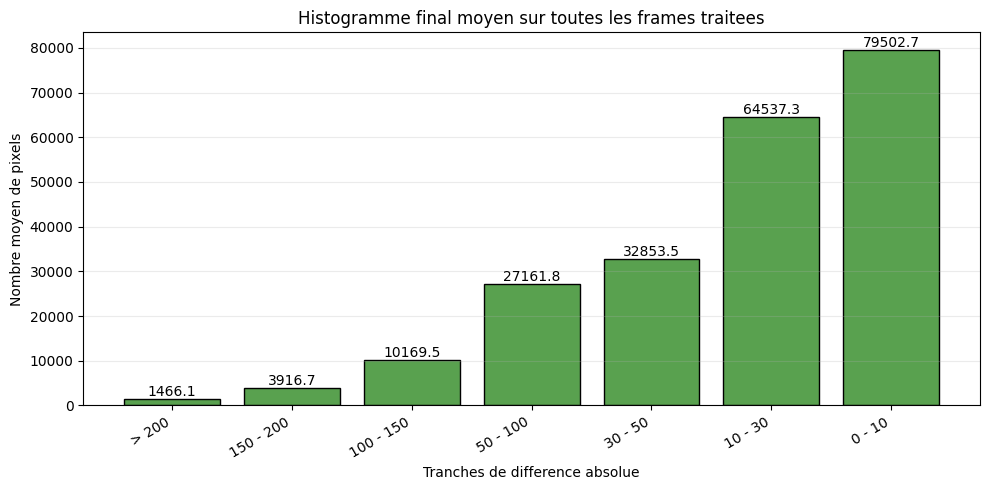

Histogramme final moyen:
     > 200 -> 1466.09
  150 - 200 -> 3916.71
  100 - 150 -> 10169.54
  50 - 100 -> 27161.79
   30 - 50 -> 32853.45
   10 - 30 -> 64537.34
    0 - 10 -> 79502.70


In [67]:
valid_histogram_results = [
    item for item in sequence_results
    if item.get("histogram_counts") is not None
]

if not valid_histogram_results:
    raise ValueError("Aucun histogramme valide disponible pour calculer la moyenne finale.")

histogram_matrix = np.array([item["histogram_counts"] for item in valid_histogram_results], dtype=np.float64)
mean_histogram_counts = histogram_matrix.mean(axis=0)

final_range_labels = [
    "> 200",
    "150 - 200",
    "100 - 150",
    "50 - 100",
    "30 - 50",
    "10 - 30",
    "0 - 10",
]

plt.figure(figsize=(10, 5))
bars = plt.bar(final_range_labels, mean_histogram_counts, color="#59A14F", edgecolor="black")
plt.title("Histogramme final moyen sur toutes les frames traitees")
plt.xlabel("Tranches de difference absolue")
plt.ylabel("Nombre moyen de pixels")
plt.grid(axis="y", alpha=0.25)
plt.xticks(rotation=30, ha="right")

for bar, value in zip(bars, mean_histogram_counts):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{value:.1f}",
        ha="center",
        va="bottom",
    )

plt.tight_layout()
plt.show()

print("Histogramme final moyen:")
for label, value in zip(final_range_labels, mean_histogram_counts):
    print(f"  {label:>8} -> {value:.2f}")


550112947.4957983


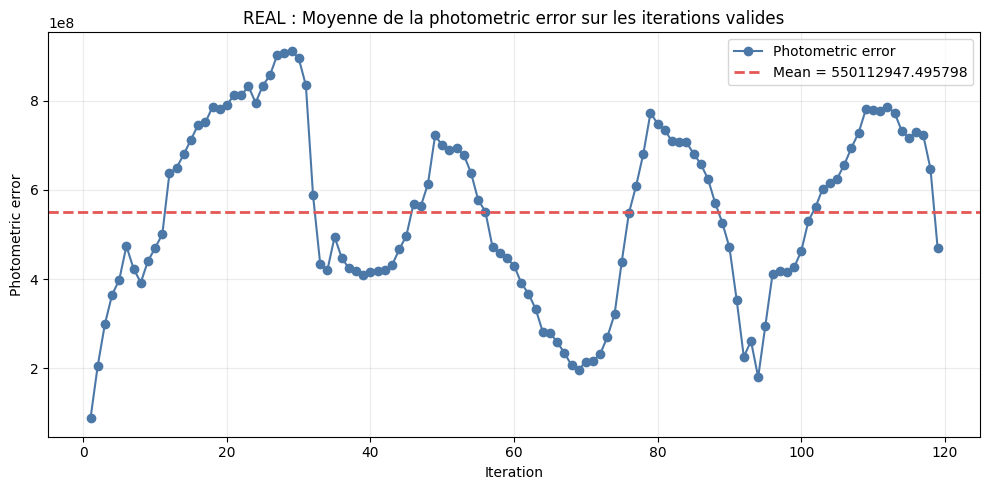

In [68]:
valid_results = [
    item for item in sequence_results
    if item["photometric_error"] is not None
]

if not valid_results:
    raise ValueError("Aucun résultat valide disponible pour calculer la moyenne des erreurs photométriques.")

iteration_indices = [item["index"] for item in valid_results]
photometric_errors = [item["photometric_error"] for item in valid_results]
mean_photometric_error = float(np.mean(photometric_errors))

print(mean_photometric_error)

plt.figure(figsize=(10, 5))
plt.plot(iteration_indices, photometric_errors, marker="o", color="#4C78A8", label="Photometric error")
plt.axhline(
    mean_photometric_error,
    color="#E45756",
    linestyle="--",
    linewidth=2,
    label=f"Mean = {mean_photometric_error:.6f}"
)
plt.title("REAL : Moyenne de la photometric error sur les iterations valides")
plt.xlabel("Iteration")
plt.ylabel("Photometric error")
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()